# Notebook 10 — Immigration Final Evaluation

## Purpose

This notebook is the final evaluation notebook for the **immigration-discourse** experiments.


## What this notebook evaluates

### Core metrics promised in the report

- Standard classification metrics: Accuracy and Macro F1
- Distribution metrics: KL divergence, Jensen--Shannon divergence, cross entropy, distribution MAE
- Ordinal metrics: Expected-label MAE and Wasserstein distance
- Uncertainty metrics: entropy MAE and entropy correlations
- Perspectivist evaluation: ANAD against raw annotator labels
- Subgroup evaluation by ideology group

### Behavioural analyses for Chapter 4

- Counterfactual subgroup variation
- Polarisation / subgroup-separation index
- Extreme Liberal vs Extreme Conservative analysis
- Human-model disagreement alignment
- Context gain/loss and confidence/entropy shifts
- Qualitative example exports

## Important design note

ANAD is computed from raw annotation labels. For subgroup-conditioned models, the primary ANAD uses raw labels from the corresponding annotator subgroup. For text-only baselines that do not contain subgroup information, ANAD falls back to all annotator labels for the comment.


## 0. Setup

In [1]:
from pathlib import Path
import ast
import itertools
import warnings

import numpy as np
import pandas as pd

from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy, pearsonr, spearmanr, wasserstein_distance

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 250)

# ---------------------------------------------------------------------
# Main configuration
# ---------------------------------------------------------------------

DISCOURSE = "immigration"

RESULTS_DIR = Path("final_evaluation_outputs") / DISCOURSE
TABLES_DIR = RESULTS_DIR / "tables"
PLOTS_DIR = RESULTS_DIR / "plots"
EXAMPLES_DIR = RESULTS_DIR / "examples"

for d in [RESULTS_DIR, TABLES_DIR, PLOTS_DIR, EXAMPLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LABEL_NAMES = {
    0: "not_hate_or_neither",
    1: "maybe",
    2: "explicit_hate",
}

NUM_LABELS = 3
MAX_LABEL_DISTANCE = NUM_LABELS - 1

SUBGROUP_ORDER = [
    "extremely_liberal",
    "liberal",
    "slightly_liberal",
    "neutral",
    "slightly_conservative",
    "conservative",
    "extremely_conservative",
    "no_opinion",
]

EXTREME_LEFT = "extremely_liberal"
EXTREME_RIGHT = "extremely_conservative"

EPS = 1e-12

print("Results directory:", RESULTS_DIR.resolve())


Results directory: /home/shayan/Distributional-Hate-Speech-Prediction/notebooks/final_evaluation_outputs/immigration


## 1. Data and Model Registry

In [2]:
# ---------------------------------------------------------------------
# Original annotation CSV
# ---------------------------------------------------------------------
# This file has one row per annotation.
# It is used to compute true annotator-aware ANAD.
# Update this path if you run the notebook somewhere else.

ANNOTATION_PATHS = [
    "/home/shayan/Distributional-Hate-Speech-Prediction/data/processed/mhs_main_experiment_annotations_with_split.csv",
    "mhs_main_experiment_annotations_with_split(2).csv",
    "/home/shayan/Distributional-Hate-Speech-Prediction/data/mhs_main_experiment_annotations_with_split.csv",
    "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/mhs_main_experiment_annotations_with_split.csv",
]


def first_existing(paths):
    """Return the first existing path from a candidate list."""
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


ANNOTATION_PATH = first_existing(ANNOTATION_PATHS)
print("Annotation path:", ANNOTATION_PATH)


# ---------------------------------------------------------------------
# Model prediction registry
# ---------------------------------------------------------------------
# This notebook only needs prediction files.
# It does NOT load old metric files, old counterfactual files, or old EL/EC files.

MODEL_REGISTRY = {
    "Original A": {
        "family": "comment_only",
        "uses_context": False,
        "conditioning": "none",
        "prediction_paths": [
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/original_a_comment_only_outputs/original_a_comment_only_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/original_a_comment_only_outputs/original_a_comment_only_test_predictions.csv",
            "original_a_comment_only_outputs/original_a_comment_only_test_predictions.parquet",
            "original_a_comment_only_outputs/original_a_comment_only_test_predictions.csv",
        ],
    },

    "Simple Token": {
        "family": "token",
        "uses_context": False,
        "conditioning": "ideology_as_text",
        "prediction_paths": [
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/immigration_simple_token_outputs/immigration_simple_token_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/immigration_simple_token_outputs/immigration_simple_token_test_predictions.csv",
            "immigration_simple_token_outputs/immigration_simple_token_test_predictions.parquet",
            "immigration_simple_token_outputs/immigration_simple_token_test_predictions.csv",
            "simple_token_outputs/immigration_simple_token_test_predictions.parquet",
            "simple_token_outputs/immigration_simple_token_test_predictions.csv",
            "token_outputs/token_test_predictions.parquet",
            "token_outputs/token_test_predictions.csv",
            "subgroup_baseline_outputs/subgroup_baseline_test_predictions.parquet",
            "subgroup_baseline_outputs/subgroup_baseline_test_predictions.csv",
        ],
    },

    "Embedding": {
        "family": "embedding",
        "uses_context": False,
        "conditioning": "ideology_embedding",
        "prediction_paths": [
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/subgroup_embedding_outputs/immigration_subgroup_embedding_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/subgroup_embedding_outputs/immigration_subgroup_embedding_test_predictions.csv",
            "subgroup_embedding_outputs/immigration_subgroup_embedding_test_predictions.parquet",
            "subgroup_embedding_outputs/immigration_subgroup_embedding_test_predictions.csv",
        ],
    },

    "Strong FiLM": {
        "family": "film",
        "uses_context": False,
        "conditioning": "film_ideology_modulation",
        "prediction_paths": [
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/boostedfilm_outputs/immigration_film_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/boostedfilm_outputs/immigration_film_test_predictions.csv",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/film_outputs/immigration_film_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/film_outputs/immigration_film_test_predictions.csv",
            "film_outputs/immigration_film_test_predictions.parquet",
            "film_outputs/immigration_film_test_predictions.csv",
            "film_outputs/film_test_predictions.parquet",
            "film_outputs/film_test_predictions.csv",
        ],
    },

    "Context + Token": {
        "family": "context_token",
        "uses_context": True,
        "conditioning": "context_and_ideology_as_text",
        "prediction_paths": [
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_token_outputs/context_token_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_token_outputs/context_token_test_predictions.csv",
            "context_token_outputs/context_token_test_predictions.parquet",
            "context_token_outputs/context_token_test_predictions.csv",
        ],
    },

    "Context + Embedding": {
        "family": "context_embedding",
        "uses_context": True,
        "conditioning": "context_text_plus_ideology_embedding",
        "prediction_paths": [
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_embedding_outputs/context_embedding_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_embedding_outputs/context_embedding_test_predictions.csv",
            "context_embedding_outputs/context_embedding_test_predictions.parquet",
            "context_embedding_outputs/context_embedding_test_predictions.csv",
        ],
    },

    "Context + Strong FiLM": {
        "family": "context_film",
        "uses_context": True,
        "conditioning": "context_text_plus_film_ideology_modulation",
        "prediction_paths": [
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_strong_film_outputs/context_strong_film_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_strong_film_outputs/context_strong_film_test_predictions.csv",
            "context_strong_film_outputs/context_strong_film_test_predictions.parquet",
            "context_strong_film_outputs/context_strong_film_test_predictions.csv",
        ],
    },
}


audit_rows = []
for model_name, cfg in MODEL_REGISTRY.items():
    pred_path = first_existing(cfg["prediction_paths"])
    audit_rows.append({
        "model": model_name,
        "family": cfg["family"],
        "uses_context": cfg["uses_context"],
        "conditioning": cfg["conditioning"],
        "prediction_file": str(pred_path) if pred_path else None,
        "status": "prediction_file_found" if pred_path else "missing_prediction_file",
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

audit_df.to_csv(TABLES_DIR / "model_prediction_file_audit.csv", index=False)
print("Saved:", TABLES_DIR / "model_prediction_file_audit.csv")


Annotation path: /home/shayan/Distributional-Hate-Speech-Prediction/data/processed/mhs_main_experiment_annotations_with_split.csv


,model,family,uses_context,conditioning,prediction_file,status
0,Original A,comment_only,False,none,/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/original_a_comment_only_outputs/original_a_comment_only_test_predictions.parquet,prediction_file_found
1,Simple Token,token,False,ideology_as_text,/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/immigration_simple_token_outputs/immigration_simple_token_test_predictions.parquet,prediction_file_found
2,Embedding,embedding,False,ideology_embedding,/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/subgroup_embedding_outputs/immigration_subgroup_embedding_test_predictions.parquet,prediction_file_found
3,Strong FiLM,film,False,film_ideology_modulation,/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/boostedfilm_outputs/immigration_film_test_predictions.parquet,prediction_file_found
4,Context + Token,context_token,True,context_and_ideology_as_text,/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_token_outputs/context_token_test_predictions.parquet,prediction_file_found
5,Context + Embedding,context_embedding,True,context_text_plus_ideology_embedding,/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_embedding_outputs/context_embedding_test_predictions.parquet,prediction_file_found
6,Context + Strong FiLM,context_film,True,context_text_plus_film_ideology_modulation,/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_strong_film_outputs/context_strong_film_test_predictions.parquet,prediction_file_found


Saved: final_evaluation_outputs/immigration/tables/model_prediction_file_audit.csv


## 2. Load Original Annotations and Build Raw Label Vectors

In [14]:
if ANNOTATION_PATH is None:
    raise FileNotFoundError(
        "Could not find annotation CSV. Update ANNOTATION_PATHS in the registry cell."
    )

annotations = pd.read_csv(ANNOTATION_PATH)

print("Annotation columns:")
print(annotations.columns.tolist())

display(annotations.head())

# ---------------------------------------------------------------------
# Identify required columns.
# ---------------------------------------------------------------------
# Expected columns:
#   comment_id
#   hatespeech
#   split
#   target_type
#   annotator_ideology_group
#
# If your file uses slightly different names, update the aliases below.

COMMENT_ID_COL = "comment_id"
LABEL_COL = "hatespeech"
SPLIT_COL = "split"
TARGET_TYPE_COL = "target_type"
IDEOLOGY_COL = "annotator_ideology_group"

required_cols = [COMMENT_ID_COL, LABEL_COL, SPLIT_COL, TARGET_TYPE_COL]
missing = [c for c in required_cols if c not in annotations.columns]
if missing:
    raise ValueError(f"Missing required annotation columns: {missing}")

# ---------------------------------------------------------------------
# Filter to immigration test annotations.
# ---------------------------------------------------------------------
# We keep target_type values containing immigrant/immigration or both.
# If your target_type names differ, inspect the printed unique values below.

print("\nTarget types:")
print(annotations[TARGET_TYPE_COL].value_counts(dropna=False))

print("\nSplits:")
print(annotations[SPLIT_COL].value_counts(dropna=False))

immigration_mask = (
    annotations[TARGET_TYPE_COL]
    .astype(str)
    .str.lower()
    .str.contains("immig|both", regex=True)
)

test_mask = annotations[SPLIT_COL].astype(str).str.lower().eq("test")

imm_test_annotations = annotations[
    immigration_mask & test_mask
].copy()

imm_test_annotations = imm_test_annotations.dropna(subset=[COMMENT_ID_COL, LABEL_COL])
imm_test_annotations[LABEL_COL] = imm_test_annotations[LABEL_COL].astype(int)

print("\nImmigration test annotation rows:", len(imm_test_annotations))
print("Unique test comments:", imm_test_annotations[COMMENT_ID_COL].nunique())

display(imm_test_annotations.head())

# ---------------------------------------------------------------------
# Build raw annotator label vectors per comment.
# ---------------------------------------------------------------------

raw_label_vectors_by_comment = (
    imm_test_annotations
    .groupby(COMMENT_ID_COL)[LABEL_COL]
    .apply(lambda x: x.astype(int).tolist())
    .to_dict()
)

# Optional subgroup-specific raw label vectors.
if IDEOLOGY_COL in imm_test_annotations.columns:
    raw_label_vectors_by_comment_subgroup = (
        imm_test_annotations
        .dropna(subset=[IDEOLOGY_COL])
        .groupby([COMMENT_ID_COL, IDEOLOGY_COL])[LABEL_COL]
        .apply(lambda x: x.astype(int).tolist())
        .to_dict()
    )
else:
    raw_label_vectors_by_comment_subgroup = {}

print("Raw label vectors available for comments:", len(raw_label_vectors_by_comment))


Annotation columns:
['comment_id', 'annotator_id', 'sentiment', 'respect', 'insult', 'humiliate', 'status', 'dehumanize', 'violence', 'genocide', 'attack_defend', 'hatespeech', 'annotator_gender', 'annotator_trans', 'annotator_gender_men', 'annotator_gender_women', 'annotator_gender_non_binary', 'annotator_gender_prefer_not_to_say', 'annotator_gender_self_describe', 'annotator_transgender', 'annotator_cisgender', 'annotator_transgender_prefer_not_to_say', 'annotator_ideology', 'annotator_ideology_extremeley_conservative', 'annotator_ideology_conservative', 'annotator_ideology_slightly_conservative', 'annotator_ideology_neutral', 'annotator_ideology_slightly_liberal', 'annotator_ideology_liberal', 'annotator_ideology_extremeley_liberal', 'annotator_ideology_no_opinion', 'target_gender', 'target_gender_men', 'target_gender_non_binary', 'target_gender_transgender_men', 'target_gender_transgender_unspecified', 'target_gender_transgender_women', 'target_gender_women', 'target_gender_other',

,comment_id,annotator_id,sentiment,respect,insult,humiliate,status,dehumanize,violence,genocide,attack_defend,hatespeech,annotator_gender,annotator_trans,annotator_gender_men,annotator_gender_women,annotator_gender_non_binary,annotator_gender_prefer_not_to_say,annotator_gender_self_describe,annotator_transgender,annotator_cisgender,annotator_transgender_prefer_not_to_say,annotator_ideology,annotator_ideology_extremeley_conservative,annotator_ideology_conservative,annotator_ideology_slightly_conservative,annotator_ideology_neutral,annotator_ideology_slightly_liberal,annotator_ideology_liberal,annotator_ideology_extremeley_liberal,annotator_ideology_no_opinion,target_gender,target_gender_men,target_gender_non_binary,target_gender_transgender_men,target_gender_transgender_unspecified,target_gender_transgender_women,target_gender_women,target_gender_other,target_origin,target_origin_immigrant,target_origin_migrant_worker,target_origin_specific_country,target_origin_undocumented,target_origin_other,text_original,text_clean,is_women_targeted,is_immigrant_targeted,annotator_gender_group,annotator_ideology_group,target_type,split
0,47101,3379,4.0,4.0,4.0,4.0,4.0,4.0,0.0,0.0,4.0,2.0,male,no,1,0,0,0,0,False,True,False,slightly_conservative,0,0,1,0,0,0,0,0,False,0,0,0,0,0,0,0,True,1,0,0,0,0,"Question: These 4 broads who criticize America, what country did they flee to get here? And now they want to make OUR America like THEIR former HELL HOLE. I don't think so!!!!!!!!!! Let them explain their GRATITUDE for letting them in OUR country.","Question: These 4 broads who criticize America, what country did they flee to get here? And now they want to make OUR America like THEIR former HELL HOLE. I don't think so!!!!!!!!!! Let them explain their GRATITUDE for letting them in OUR country.",0,1,men,slightly_conservative,immigrant_only,validation
1,43625,7365,2.0,3.0,2.0,1.0,2.0,0.0,0.0,0.0,3.0,0.0,male,no,1,0,0,0,0,False,True,False,neutral,0,0,0,1,0,0,0,0,False,0,0,0,0,0,0,0,True,0,0,0,1,0,It is about time for all illegals to go back to their country of origin and keep our freeway open and prevent heavy traffic.,It is about time for all illegals to go back to their country of origin and keep our freeway open and prevent heavy traffic.,0,1,men,neutral,immigrant_only,train
2,12538,488,4.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,3.0,2.0,female,no,0,1,0,0,0,False,True,False,neutral,0,0,0,1,0,0,0,0,True,0,0,0,0,0,1,0,False,0,0,0,0,0,For starters bend over the one in pink and kick that ass and pussy to get a taste until she's begging for a dick inside her.,For starters bend over the one in pink and kick that ass and pussy to get a taste until she's begging for a dick inside her.,1,0,women,neutral,women_only,test
3,40171,10363,4.0,4.0,4.0,3.0,3.0,3.0,0.0,1.0,1.0,0.0,female,no,0,1,0,0,0,False,True,False,slightly_conservative,0,0,1,0,0,0,0,0,True,0,0,0,0,0,1,0,False,0,0,0,0,0,"OMG! The EGO's of these young, young, inexperienced women display are remarkable! So self absorbed - so, so proud of the mistakes their constituents all made in giving them a bit of power. They'll be quite surprised to find that the vast majorit...","OMG! The EGO's of these young, young, inexperienced women display are remarkable! So self absorbed - so, so proud of the mistakes their constituents all made in giving them a bit of power. They'll be quite surprised to find that the vast majority...",1,0,women,slightly_conservative,women_only,train
4,1006,10615,4.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,4.0,2.0,female,no,0,1,0,0,0,False,True,False,extremely_liberal,0,0,0,0,0,0,0,0,True,0,0,0,0,0,1,0,False,0,0,0,0,0,"Worthless whore, these tits with look nice with bite marks and cum","Worthless whore, these tits with look nice with bite marks and cum",1,0,women,extremely_liberal,women_only,train



Target types:
target_type
women_only             26905
immigrant_only         21544
women_and_immigrant      984
Name: count, dtype: int64

Splits:
split
train         34413
test           7713
validation     7307
Name: count, dtype: int64

Immigration test annotation rows: 3065
Unique test comments: 1294


,comment_id,annotator_id,sentiment,respect,insult,humiliate,status,dehumanize,violence,genocide,attack_defend,hatespeech,annotator_gender,annotator_trans,annotator_gender_men,annotator_gender_women,annotator_gender_non_binary,annotator_gender_prefer_not_to_say,annotator_gender_self_describe,annotator_transgender,annotator_cisgender,annotator_transgender_prefer_not_to_say,annotator_ideology,annotator_ideology_extremeley_conservative,annotator_ideology_conservative,annotator_ideology_slightly_conservative,annotator_ideology_neutral,annotator_ideology_slightly_liberal,annotator_ideology_liberal,annotator_ideology_extremeley_liberal,annotator_ideology_no_opinion,target_gender,target_gender_men,target_gender_non_binary,target_gender_transgender_men,target_gender_transgender_unspecified,target_gender_transgender_women,target_gender_women,target_gender_other,target_origin,target_origin_immigrant,target_origin_migrant_worker,target_origin_specific_country,target_origin_undocumented,target_origin_other,text_original,text_clean,is_women_targeted,is_immigrant_targeted,annotator_gender_group,annotator_ideology_group,target_type,split
9,14868,3948,2.0,2.0,1.0,2.0,2.0,1.0,0.0,0.0,1.0,0,male,no,1,0,0,0,0,False,True,False,liberal,0,0,0,0,0,1,0,0,False,0,0,0,0,0,0,0,True,1,0,0,1,0,"Many of the families who are being separated at the border and who are being kept in poor conditions did try to cross legally, through legal ports of entry seeking asylum.","Many of the families who are being separated at the border and who are being kept in poor conditions did try to cross legally, through legal ports of entry seeking asylum.",0,1,men,liberal,immigrant_only,test
10,11817,3559,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,2,male,no,1,0,0,0,0,False,True,False,slightly_liberal,0,0,0,0,1,0,0,0,False,0,0,0,0,0,0,0,True,0,0,1,0,0,Get rid of them and their anchor babies and grand babies. Fucking worthless guinees,Get rid of them and their anchor babies and grand babies. Fucking worthless guinees,0,1,men,slightly_liberal,immigrant_only,test
29,25323,2637,3.0,3.0,3.0,2.0,2.0,1.0,0.0,0.0,3.0,0,female,no,0,1,0,0,0,False,True,False,no_opinion,0,0,0,0,0,0,0,1,False,0,0,0,0,0,0,0,True,0,0,1,0,0,"@thedailybeast All the brits still have Ass hurt from the spanking we gave them a couple hundred years ago. In fact, if their food and weather weren't absolute shit we would have already colonized them. America is the ONLY reason you twats never ...","@thedailybeast All the brits still have Ass hurt from the spanking we gave them a couple hundred years ago. In fact, if their food and weather weren't absolute shit we would have already colonized them. America is the ONLY reason you twats never ...",0,1,women,no_opinion,immigrant_only,test
60,38578,718,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0,male,no,1,0,0,0,0,False,True,False,slightly_liberal,0,0,0,0,1,0,0,0,False,0,0,0,0,0,0,0,True,0,0,1,0,0,deepika padukone's face...is something else. no words to describe this beauty URL,deepika padukone's face...is something else. no words to describe this beauty URL,0,1,men,slightly_liberal,immigrant_only,test
63,39890,130,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,2.0,0,male,no,1,0,0,0,0,False,True,False,conservative,0,1,0,0,0,0,0,0,False,0,0,0,0,0,0,0,True,0,0,1,0,0,RT please! @UN just watch how Pakistan is sending terrorists into Kashmir.👇 Hope they should reach UN or heaven soon.,RT please! @UN just watch how Pakistan is sending terrorists into Kashmir.👇 Hope they should reach UN or heaven soon.,0,1,men,conservative,immigrant_only,test


Raw label vectors available for comments: 1294


## 3. Metric Functions

In [15]:
def parse_distribution(value):
    """Parse a distribution stored as ndarray, list, tuple, or string."""
    if isinstance(value, np.ndarray):
        return value.astype(float)
    if isinstance(value, list):
        return np.array(value, dtype=float)
    if isinstance(value, tuple):
        return np.array(value, dtype=float)
    if isinstance(value, str):
        value = value.strip()
        try:
            return np.array(ast.literal_eval(value), dtype=float)
        except Exception:
            cleaned = value.strip("[]").replace(",", " ")
            return np.array([float(x) for x in cleaned.split()], dtype=float)
    raise TypeError(f"Unsupported distribution type: {type(value)}")


def normalize_distribution(x):
    """Ensure vector is a valid probability distribution."""
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 0, None)
    total = x.sum()
    if total <= 0:
        return np.ones_like(x) / len(x)
    return x / total


def stack_distributions(series):
    """Convert a dataframe column of distributions into a 2D numpy array."""
    return np.vstack(series.apply(parse_distribution).apply(normalize_distribution).to_numpy())


def kl_divergence(y_true, y_pred):
    y_true = np.clip(y_true, EPS, 1.0)
    y_pred = np.clip(y_pred, EPS, 1.0)
    y_true = y_true / y_true.sum(axis=1, keepdims=True)
    y_pred = y_pred / y_pred.sum(axis=1, keepdims=True)
    return np.sum(y_true * np.log(y_true / y_pred), axis=1)


def js_divergence(y_true, y_pred):
    return np.array([
        jensenshannon(normalize_distribution(t), normalize_distribution(p), base=2) ** 2
        for t, p in zip(y_true, y_pred)
    ])


def cross_entropy(y_true, y_pred):
    y_true = np.clip(y_true, EPS, 1.0)
    y_pred = np.clip(y_pred, EPS, 1.0)
    y_true = y_true / y_true.sum(axis=1, keepdims=True)
    y_pred = y_pred / y_pred.sum(axis=1, keepdims=True)
    return -np.sum(y_true * np.log(y_pred), axis=1)


def distribution_mae(y_true, y_pred):
    """Mean absolute error over distribution probabilities."""
    return np.mean(np.abs(y_true - y_pred), axis=1)


def expected_scores(distributions):
    return distributions @ np.arange(distributions.shape[1])


def entropy_values(distributions):
    return np.array([entropy(normalize_distribution(d), base=2) for d in distributions])


def average_MD(targets, predictions):
    """Average Manhattan Distance between target and predicted distributions."""
    return float(np.mean(np.sum(np.abs(predictions - targets), axis=1)))


def average_wasserstein(y_true, y_pred):
    """Ordinal Wasserstein distance over label positions."""
    positions = np.arange(y_true.shape[1])
    distances = []
    for true, pred in zip(y_true, y_pred):
        distances.append(
            wasserstein_distance(
                positions,
                positions,
                u_weights=normalize_distribution(true),
                v_weights=normalize_distribution(pred),
            )
        )
    return float(np.mean(distances)) if distances else np.nan


def anad_from_labels(pred_dist, raw_labels, max_label_distance=MAX_LABEL_DISTANCE, prediction_mode="argmax"):
    """
    Average Normalized Absolute Distance for one prediction row.

    This follows the LeWiDi-style ordinal evaluation idea: compare a model-predicted
    ordinal label against each raw annotator label for the same instance, normalize by
    the label range, then average.

    prediction_mode="argmax" is the primary report setting because ANAD is defined
    over predicted labels. prediction_mode="expected" is retained only for optional
    sensitivity analysis.
    """
    pred_dist = normalize_distribution(pred_dist)

    if raw_labels is None or len(raw_labels) == 0:
        return np.nan

    if prediction_mode == "argmax":
        pred_label = int(np.argmax(pred_dist))
    elif prediction_mode == "expected":
        pred_label = float(np.sum(pred_dist * np.arange(len(pred_dist))))
    else:
        raise ValueError("prediction_mode must be 'argmax' or 'expected'")

    distances = [
        abs(float(label) - pred_label) / max_label_distance
        for label in raw_labels
    ]

    return float(np.mean(distances) * 100)


def safe_js(a, b):
    return float(
        jensenshannon(
            normalize_distribution(a),
            normalize_distribution(b),
            base=2,
        ) ** 2
    )


def compute_anad_for_dataframe(df, label_vector_lookup, use_subgroup=False, prediction_mode="argmax"):
    """
    Compute ANAD for each prediction row.

    If use_subgroup=True, labels are looked up using (comment_id, subgroup).
    Otherwise, all raw labels for the comment are used.
    """
    values = []

    for _, row in df.iterrows():
        pred = parse_distribution(row["pred_distribution"])

        if use_subgroup:
            key = (row["comment_id"], row["subgroup"])
            raw_labels = label_vector_lookup.get(key, None)
        else:
            raw_labels = label_vector_lookup.get(row["comment_id"], None)

        values.append(anad_from_labels(pred, raw_labels, prediction_mode=prediction_mode))

    return np.array(values, dtype=float)


def choose_primary_anad(df):
    """
    Primary ANAD used in report tables.

    For subgroup-conditioned rows where subgroup-specific raw labels exist, use subgroup ANAD.
    Otherwise fall back to comment-level ANAD. This keeps Original A evaluable while making
    identity-conditioned models genuinely subgroup-aware.
    """
    if "anad_subgroup_argmax" in df.columns and df["anad_subgroup_argmax"].notna().any():
        return df["anad_subgroup_argmax"].where(
            df["anad_subgroup_argmax"].notna(),
            df["anad_comment_argmax"],
        )
    return df["anad_comment_argmax"]


def compute_distribution_metrics(y_true, y_pred, anad_values=None):
    """Compute report-ready predictive, distributional, uncertainty and ANAD metrics."""
    true_labels = np.argmax(y_true, axis=1)
    pred_labels = np.argmax(y_pred, axis=1)

    true_ent = entropy_values(y_true)
    pred_ent = entropy_values(y_pred)

    entropy_abs_error = np.abs(true_ent - pred_ent)

    metrics = {
        "n": len(y_true),
        "kl_mean": float(kl_divergence(y_true, y_pred).mean()),
        "js_mean": float(js_divergence(y_true, y_pred).mean()),
        "cross_entropy_mean": float(cross_entropy(y_true, y_pred).mean()),
        "distribution_mae_mean": float(distribution_mae(y_true, y_pred).mean()),
        "accuracy": float(accuracy_score(true_labels, pred_labels)),
        "macro_f1": float(f1_score(true_labels, pred_labels, average="macro", zero_division=0)),
        "expected_label_mae": float(mean_absolute_error(expected_scores(y_true), expected_scores(y_pred))),
        "distribution_average_MD": average_MD(y_true, y_pred),
        "average_wasserstein": average_wasserstein(y_true, y_pred),
        "mean_true_entropy": float(true_ent.mean()),
        "mean_pred_entropy": float(pred_ent.mean()),
        "entropy_mae": float(entropy_abs_error.mean()),
        "entropy_median_abs_error": float(np.median(entropy_abs_error)),
    }

    if anad_values is not None:
        metrics["anad_mean"] = float(np.nanmean(anad_values))
        metrics["anad_median"] = float(np.nanmedian(anad_values))
        metrics["anad_coverage"] = float(np.mean(~np.isnan(anad_values)))
    else:
        metrics["anad_mean"] = np.nan
        metrics["anad_median"] = np.nan
        metrics["anad_coverage"] = np.nan

    if len(np.unique(true_ent)) > 1 and len(np.unique(pred_ent)) > 1:
        metrics["entropy_pearson"] = float(pearsonr(true_ent, pred_ent).statistic)
        metrics["entropy_spearman"] = float(spearmanr(true_ent, pred_ent).statistic)
    else:
        metrics["entropy_pearson"] = np.nan
        metrics["entropy_spearman"] = np.nan

    return metrics


## 4. Load and Standardize Test Predictions

In [16]:
def read_prediction_file(path):
    path = Path(path)
    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    if path.suffix == ".csv":
        return pd.read_csv(path)
    raise ValueError(f"Unsupported prediction file type: {path}")


def standardize_subgroup(value):
    if pd.isna(value):
        return "unknown"
    s = str(value).strip().lower()
    s = s.replace(" ", "_").replace("-", "_")
    aliases = {
        "extreme_liberal": "extremely_liberal",
        "extreme_conservative": "extremely_conservative",
        "none": "unknown",
        "nan": "unknown",
    }
    return aliases.get(s, s)


def standardize_predictions(df, model_name, cfg):
    df = df.copy()

    if "true_distribution" not in df.columns:
        if "target_distribution" in df.columns:
            df["true_distribution"] = df["target_distribution"]
        else:
            raise ValueError(f"{model_name}: missing true_distribution or target_distribution")

    if "pred_distribution" not in df.columns:
        raise ValueError(f"{model_name}: missing pred_distribution")

    if "text" not in df.columns:
        for alt in ["comment", "tweet", "comment_text", "clean_text"]:
            if alt in df.columns:
                df["text"] = df[alt]
                break
    if "text" not in df.columns:
        df["text"] = ""

    if "comment_id" not in df.columns:
        if "id" in df.columns:
            df["comment_id"] = df["id"]
        else:
            raise ValueError(
                f"{model_name}: missing comment_id. Do not create row-number IDs because ANAD and matched context analysis need real comment IDs."
            )

    if "subgroup" not in df.columns:
        for alt in ["annotator_ideology_group", "ideology", "group", "subgroup_name"]:
            if alt in df.columns:
                df["subgroup"] = df[alt]
                break
    if "subgroup" not in df.columns:
        df["subgroup"] = "unknown"

    df["subgroup"] = df["subgroup"].apply(standardize_subgroup)

    y_true = stack_distributions(df["true_distribution"])
    y_pred = stack_distributions(df["pred_distribution"])

    if "target_majority_label" not in df.columns:
        df["target_majority_label"] = np.argmax(y_true, axis=1)

    df["pred_majority_label"] = np.argmax(y_pred, axis=1)

    df["true_expected_label"] = expected_scores(y_true)
    df["pred_expected_label"] = expected_scores(y_pred)

    df["true_entropy"] = entropy_values(y_true)
    df["pred_entropy"] = entropy_values(y_pred)
    df["entropy_abs_error"] = np.abs(df["true_entropy"] - df["pred_entropy"])

    df["kl"] = kl_divergence(y_true, y_pred)
    df["js"] = js_divergence(y_true, y_pred)
    df["cross_entropy"] = cross_entropy(y_true, y_pred)
    df["distribution_mae"] = distribution_mae(y_true, y_pred)
    df["abs_expected_error"] = np.abs(df["true_expected_label"] - df["pred_expected_label"])

    # ANAD against all labels for the comment. Useful for Original A and as a fallback.
    df["anad_comment_argmax"] = compute_anad_for_dataframe(
        df,
        raw_label_vectors_by_comment,
        use_subgroup=False,
        prediction_mode="argmax",
    )
    df["anad_comment_expected"] = compute_anad_for_dataframe(
        df,
        raw_label_vectors_by_comment,
        use_subgroup=False,
        prediction_mode="expected",
    )

    # ANAD against raw labels from the corresponding subgroup. This is the primary ANAD
    # for identity-conditioned models where subgroup-specific rows exist.
    if raw_label_vectors_by_comment_subgroup:
        df["anad_subgroup_argmax"] = compute_anad_for_dataframe(
            df,
            raw_label_vectors_by_comment_subgroup,
            use_subgroup=True,
            prediction_mode="argmax",
        )
        df["anad_subgroup_expected"] = compute_anad_for_dataframe(
            df,
            raw_label_vectors_by_comment_subgroup,
            use_subgroup=True,
            prediction_mode="expected",
        )
    else:
        df["anad_subgroup_argmax"] = np.nan
        df["anad_subgroup_expected"] = np.nan

    df["anad_eval"] = choose_primary_anad(df)

    # Backward-compatible aliases for old cells; report should use anad_eval/anad_mean.
    df["true_anad"] = df["anad_eval"]
    df["true_anad_subgroup"] = df["anad_subgroup_argmax"]

    df["model"] = model_name
    df["model_family"] = cfg["family"]
    df["uses_context"] = cfg["uses_context"]
    df["conditioning"] = cfg["conditioning"]

    return df


predictions_by_model = {}
missing_models = []

for model_name, cfg in MODEL_REGISTRY.items():
    pred_path = first_existing(cfg["prediction_paths"])

    if pred_path is None:
        missing_models.append(model_name)
        continue

    raw = read_prediction_file(pred_path)
    standardized = standardize_predictions(raw, model_name, cfg)

    predictions_by_model[model_name] = standardized

    safe_name = model_name.lower().replace(" ", "_").replace("+", "plus")
    standardized.to_csv(TABLES_DIR / f"{safe_name}_standardized_predictions.csv", index=False)

print("Loaded models:")
for m in predictions_by_model:
    print(" -", m)

print("\nMissing models:")
for m in missing_models:
    print(" -", m)

combined_predictions = pd.concat(predictions_by_model.values(), ignore_index=True)
combined_predictions.to_csv(TABLES_DIR / "combined_standardized_predictions.csv", index=False)

display(combined_predictions.head())
print("Saved:", TABLES_DIR / "combined_standardized_predictions.csv")


Loaded models:
 - Original A
 - Simple Token
 - Embedding
 - Strong FiLM
 - Context + Token
 - Context + Embedding
 - Context + Strong FiLM

Missing models:


,experiment,comment_id,split,subgroup,subgroup_count,text,target_distribution,target_majority_label,target_expected_label,retrieved_article_titles,retrieved_page_urls,retrieved_similarities,retrieved_summaries,context_input_text,tweet_token_length,context_input_token_length,true_distribution,pred_distribution,pred_majority_label,pred_expected_label,pred_entropy,kl,js,cross_entropy,true_expected_label,true_entropy,entropy_abs_error,distribution_mae,abs_expected_error,anad_comment_argmax,anad_comment_expected,anad_subgroup_argmax,anad_subgroup_expected,anad_eval,true_anad,true_anad_subgroup,model,model_family,uses_context,conditioning,input_text,target_entropy,subgroup_id
0,immigration,7,test,extremely_liberal,1,\*points to posters asking for palestinian rights and freedom\* theyre antisemetic and want to kill all the jews and dont acknowledge our right to exist ​ cant wait for this prick to die and go straight to hell. ill dig him the hole to get there ...,"[1.0, 0.0, 0.0]",0,0.0,[Left-wing politics],[https://en.wikipedia.org/wiki/Left-wing_politics],[0.14819347858428955],"[Left-wing politics emphasizes social equality and egalitarianism, often opposing social hierarchies and advocating for the empowerment of marginalized groups. Leftist ideologies vary widely but typically involve a concern for those disadvantaged...",### COMMENT TO CLASSIFY\n\*points to posters asking for palestinian rights and freedom\* theyre antisemetic and want to kill all the jews and dont acknowledge our right to exist ​ cant wait for this prick to die and go straight to hell. ill dig h...,60.0,197.0,"[1.0, 0.0, 0.0]","[0.34295484, 0.10083626, 0.5562089]",2,1.213254,1.333971,1.070157,0.449601,1.070157,0.0,0.0,1.333971,0.438030,1.213254,50.0,50.0000,100.0,60.662703,100.0,100.0,100.0,Original A,comment_only,False,none,NaN,NaN,NaN
1,immigration,7,test,liberal,1,\*points to posters asking for palestinian rights and freedom\* theyre antisemetic and want to kill all the jews and dont acknowledge our right to exist ​ cant wait for this prick to die and go straight to hell. ill dig him the hole to get there ...,"[0.0, 0.0, 1.0]",2,2.0,[Left-wing politics],[https://en.wikipedia.org/wiki/Left-wing_politics],[0.14819347858428955],"[Left-wing politics emphasizes social equality and egalitarianism, often opposing social hierarchies and advocating for the empowerment of marginalized groups. Leftist ideologies vary widely but typically involve a concern for those disadvantaged...",### COMMENT TO CLASSIFY\n\*points to posters asking for palestinian rights and freedom\* theyre antisemetic and want to kill all the jews and dont acknowledge our right to exist ​ cant wait for this prick to die and go straight to hell. ill dig h...,60.0,195.0,"[0.0, 0.0, 1.0]","[0.34295484, 0.10083626, 0.5562089]",2,1.213254,1.333971,0.586611,0.268181,0.586611,2.0,0.0,1.333971,0.295861,0.786746,50.0,50.0000,0.0,39.337297,0.0,0.0,0.0,Original A,comment_only,False,none,NaN,NaN,NaN
2,immigration,66,test,extremely_liberal,1,Get ready to be flogged. India is ready to flog all cow dung eating shameless fucktards,"[0.0, 0.0, 1.0]",2,2.0,[Free migration],[https://en.wikipedia.org/wiki/Free_migration],[0.08663808554410934],"[The concept of free migration has been debated globally, with various perspectives on its moral, economic, and cultural implications. Some argue that it's a human right, citing religious teachings such as Buddhism and Christianity, which emphasi...",### COMMENT TO CLASSIFY\nGet ready to be flogged. India is ready to flog all cow dung eating shameless fucktards\n\n### ANNOTATOR IDEOLOGY\nextremely_liberal\n\n### RETRIEVED BACKGROUND\nFree migration:\nThe concept of free migration has been deb...,24.0,157.0,"[0.0, 0.0, 1.0]","[0.101112075, 0.069408886, 0.82947904]",2,1.728367,0.825139,0.186957,0.091001,0.186957,2.0,0.0,0.825139,0.113681,0.271633,50.0,50.0000,0.0,13.581652,0.0,0.0,0.0,Original A,comment_only,False,none,NaN,NaN,NaN
3,immigration,66,test,slightly_liberal,1,Get ready 

Saved: final_evaluation_outputs/immigration/tables/combined_standardized_predictions.csv


## 5. Overall Report Metrics

In [17]:
master_rows = []

for model_name, df in predictions_by_model.items():
    y_true = stack_distributions(df["true_distribution"])
    y_pred = stack_distributions(df["pred_distribution"])

    master_rows.append({
        "model": model_name,
        "family": MODEL_REGISTRY[model_name]["family"],
        "conditioning": MODEL_REGISTRY[model_name]["conditioning"],
        "uses_context": MODEL_REGISTRY[model_name]["uses_context"],
        **compute_distribution_metrics(y_true, y_pred, anad_values=df["anad_eval"].to_numpy()),
        "anad_subgroup_coverage": float(df["anad_subgroup_argmax"].notna().mean()),
    })

master_metrics_df = pd.DataFrame(master_rows).sort_values("kl_mean")
display(master_metrics_df)

master_metrics_df.to_csv(TABLES_DIR / "master_predictive_metrics.csv", index=False)
print("Saved:", TABLES_DIR / "master_predictive_metrics.csv")


,model,family,conditioning,uses_context,n,kl_mean,js_mean,cross_entropy_mean,distribution_mae_mean,accuracy,macro_f1,expected_label_mae,distribution_average_MD,average_wasserstein,mean_true_entropy,mean_pred_entropy,entropy_mae,entropy_median_abs_error,anad_mean,anad_median,anad_coverage,entropy_pearson,entropy_spearman,anad_subgroup_coverage
2,Embedding,embedding,ideology_embedding,False,1384,0.595919,0.223773,0.620344,0.216077,0.770231,0.448261,0.489095,0.648230,0.512826,0.035238,0.831930,0.809917,0.797539,20.368736,0.0,1.0,0.060468,0.059392,1.0
1,Simple Token,token,ideology_as_text,False,1384,0.607477,0.241747,0.631901,0.243138,0.765173,0.446973,0.557452,0.729413,0.590635,0.035238,1.011069,0.981166,0.969725,20.705923,0.0,1.0,0.058430,0.062302,1.0
0,Original A,comment_only,none,False,1384,0.609041,0.229569,0.633466,0.221940,0.765896,0.462419,0.515151,0.665821,0.541230,0.035238,0.849188,0.825664,0.825724,20.681838,0.0,1.0,0.033586,0.027813,1.0
3,Strong FiLM,film,film_ideology_modulation,False,1384,0.610134,0.219481,0.634559,0.207502,0.777457,0.461767,0.472863,0.622506,0.493314,0.035238,0.762379,0.745445,0.648953,19.670277,0.0,1.0,0.033175,0.033593,1.0
4,Context + Token,context_token,context_and_ideology_as_text,True,1384,0.616327,0.229439,0.640752,0.220981,0.770954,0.456479,0.508283,0.662943,0.534303,0.035238,0.849555,0.828815,0.659727,20.428948,0.0,1.0,0.048189,0.049517,1.0
6,Context + Strong FiLM,context_film,context_text_plus_film_ideology_modulation,True,1384,0.621567,0.222306,0.645992,0.209532,0.772399,0.439655,0.474821,0.628597,0.497017,0.035238,0.757594,0.740718,0.680768,20.224227,0.0,1.0,0.045796,0.042038,1.0
5,Context + Embedding,context_embedding,context_text_plus_ideology_embedding,True,1384,0.637679,0.220875,0.662103,0.205398,0.764451,0.437165,0.487228,0.616194,0.510580,0.035238,0.705930,0.690177,0.516862,20.934728,0.0,1.0,0.060396,0.065772,1.0


Saved: final_evaluation_outputs/immigration/tables/master_predictive_metrics.csv


## 6. Confusion Matrices and Classification Reports

In [18]:
for model_name, df in predictions_by_model.items():
    y_true = stack_distributions(df["true_distribution"])
    y_pred = stack_distributions(df["pred_distribution"])

    true_labels = np.argmax(y_true, axis=1)
    pred_labels = np.argmax(y_pred, axis=1)

    cm = confusion_matrix(true_labels, pred_labels, labels=[0, 1, 2])
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{i}" for i in [0, 1, 2]],
        columns=[f"pred_{i}" for i in [0, 1, 2]],
    )

    report = classification_report(
        true_labels,
        pred_labels,
        labels=[0, 1, 2],
        zero_division=0,
        output_dict=True,
    )
    report_df = pd.DataFrame(report).T

    safe_name = model_name.lower().replace(" ", "_").replace("+", "plus")
    cm_df.to_csv(TABLES_DIR / f"{safe_name}_confusion_matrix.csv")
    report_df.to_csv(TABLES_DIR / f"{safe_name}_classification_report.csv")

    print("=" * 100)
    print(model_name)
    display(cm_df)
    display(report_df)


Original A


,pred_0,pred_1,pred_2
true_0,918,0,111
true_1,69,0,26
true_2,118,0,142


,precision,recall,f1-score,support
0,0.830769,0.892128,0.860356,1029.000000
1,0.000000,0.000000,0.000000,95.000000
2,0.508961,0.546154,0.526902,260.000000
accuracy,0.765896,0.765896,0.765896,0.765896
macro avg,0.446577,0.479427,0.462419,1384.000000
weighted avg,0.713289,0.765896,0.738657,1384.000000


Simple Token


,pred_0,pred_1,pred_2
true_0,943,0,86
true_1,73,0,22
true_2,144,0,116


...

,pred_0,pred_1,pred_2
true_0,955,0,74
true_1,73,0,22
true_2,157,0,103


,precision,recall,f1-score,support
0,0.805907,0.928086,0.862692,1029.000000
1,0.000000,0.000000,0.000000,95.000000
2,0.517588,0.396154,0.448802,260.000000
accuracy,0.764451,0.764451,0.764451,0.764451
macro avg,0.441165,0.441413,0.437165,1384.000000
weighted avg,0.696424,0.764451,0.725721,1384.000000


Context + Strong FiLM


,pred_0,pred_1,pred_2
true_0,971,0,58
true_1,77,0,18
true_2,162,0,98


,precision,recall,f1-score,support
0,0.802479,0.943635,0.867351,1029.000000
1,0.000000,0.000000,0.000000,95.000000
2,0.563218,0.376923,0.451613,260.000000
accuracy,0.772399,0.772399,0.772399,0.772399
macro avg,0.455233,0.440186,0.439655,1384.000000
weighted avg,0.702448,0.772399,0.729714,1384.000000


## 7. Subgroup Evaluation

In [19]:
subgroup_rows = []

for model_name, df in predictions_by_model.items():
    for subgroup, group in df.groupby("subgroup"):
        if subgroup == "unknown" or len(group) < 2:
            continue

        y_true = stack_distributions(group["true_distribution"])
        y_pred = stack_distributions(group["pred_distribution"])

        subgroup_rows.append({
            "model": model_name,
            "subgroup": subgroup,
            **compute_distribution_metrics(
                y_true,
                y_pred,
                anad_values=group["anad_eval"].to_numpy(),
            ),
        })

subgroup_metrics_df = pd.DataFrame(subgroup_rows)

if not subgroup_metrics_df.empty:
    subgroup_metrics_df["subgroup"] = pd.Categorical(
        subgroup_metrics_df["subgroup"],
        categories=SUBGROUP_ORDER,
        ordered=True,
    )
    subgroup_metrics_df = subgroup_metrics_df.sort_values(["model", "subgroup"])

display(subgroup_metrics_df)

subgroup_metrics_df.to_csv(TABLES_DIR / "subgroup_metrics.csv", index=False)
print("Saved:", TABLES_DIR / "subgroup_metrics.csv")


,model,subgroup,n,kl_mean,js_mean,cross_entropy_mean,distribution_mae_mean,accuracy,macro_f1,expected_label_mae,distribution_average_MD,average_wasserstein,mean_true_entropy,mean_pred_entropy,entropy_mae,entropy_median_abs_error,anad_mean,anad_median,anad_coverage,entropy_pearson,entropy_spearman
42,Context + Embedding,extremely_liberal,197,0.757972,0.257471,0.778689,0.232816,0.720812,0.385129,0.563537,0.698448,0.584325,0.029889,0.710772,0.700387,0.526993,24.942559,0.0,1.0,-0.011127,0.016816
43,Context + Embedding,liberal,308,0.628563,0.210665,0.668825,0.195436,0.785714,0.439938,0.454997,0.586309,0.477960,0.058085,0.674481,0.650494,0.490154,19.330504,0.0,1.0,0.098248,0.120504
47,Context + Embedding,slightly_liberal,213,0.698896,0.243204,0.716042,0.223104,0.718310,0.399490,0.535294,0.669313,0.558439,0.024736,0.727100,0.711811,0.527774,24.716618,0.0,1.0,0.108694,0.075005
44,Context + Embedding,neutral,257,0.690673,0.240160,0.724095,0.222423,0.739300,0.424593,0.532163,0.667268,0.558252,0.048218,0.746219,0.719121,0.549746,23.635298,0.0,1.0,0.100493,0.096711
46,Context + Embedding,slightly_conservative,154,0.558197,0.199902,0.569756,0.190344,0.785714,0.458165,0.455164,0.571033,0.478666,0.016676,0.694727,0.692372,0.517350,18.970196,0.0,1.0,-0.043501,-0.065983
40,Context + Embedding,conservative,163,0.501368,0.178081,0.513300,0.170456,0.822086,0.492813,0.387573,0.511369,0.412571,0.017214,0.664661,0.659315,0.468583,15.129273,0.0,1.0,0.007675,0.023560
41,Context + Embedding,extremely_conservative,46,0.401958,0.159982,0.412504,0.166836,0.869565,0.555473,0.402010,0.500507,0.420052,0.015214,0.787241,0.772027,0.604659,11.086957,0.0,1.0,0.141894,0.129130
45,Context + Embedding,no_opinion,46,0.588833,0.204117,0.607752,0.190349,0.782609,0.476265,0.448306,0.571046,0.469875,0.027295,0.675072,0.670428,0.510637,18.908514,0.0,1.0,-0.051986,-0.086384
50,Context + Strong FiLM,extremely_liberal,197,0.701319,0.246837,0.722037,0.226692,0.746193,0.400603,0.515861,0.680076,0.531507,0.029889,0.760837,0.749007,0.621950,22.404488,0.0,1.0,0.032162,0.044326
51,Context + Strong FiLM,liberal,308,0.584710,0.212368,0.624972,0.204435,0.795455,0.458092,0.448847,0.613306,0.474202,0.058085,0.784546,0.750196,0.702900,18.518815,0.0,1.0,0.101524,0.097052


Saved: final_evaluation_outputs/immigration/tables/subgroup_metrics.csv


## 8. Majority Label Evaluation

In [20]:
majority_rows = []

for model_name, df in predictions_by_model.items():
    for label, group in df.groupby("target_majority_label"):
        y_true = stack_distributions(group["true_distribution"])
        y_pred = stack_distributions(group["pred_distribution"])

        majority_rows.append({
            "model": model_name,
            "target_majority_label": int(label),
            "label_name": LABEL_NAMES.get(int(label), str(label)),
            **compute_distribution_metrics(y_true, y_pred, anad_values=group["anad_eval"].to_numpy()),
        })

majority_metrics_df = pd.DataFrame(majority_rows).sort_values(["model", "target_majority_label"])
display(majority_metrics_df)

majority_metrics_df.to_csv(TABLES_DIR / "majority_label_metrics.csv", index=False)
print("Saved:", TABLES_DIR / "majority_label_metrics.csv")


,model,target_majority_label,label_name,n,kl_mean,js_mean,cross_entropy_mean,distribution_mae_mean,accuracy,macro_f1,expected_label_mae,distribution_average_MD,average_wasserstein,mean_true_entropy,mean_pred_entropy,entropy_mae,entropy_median_abs_error,anad_mean,anad_median,anad_coverage,entropy_pearson,entropy_spearman
15,Context + Embedding,0,not_hate_or_neither,1029,0.223301,0.096867,0.248084,0.110846,0.928086,0.481351,0.287593,0.332537,0.289551,0.035754,0.625278,0.612838,0.475274,8.081471,0.0,1.0,0.076558,0.063209
16,Context + Embedding,1,maybe,95,3.135908,0.857692,3.172390,0.629647,0.000000,0.000000,0.640017,1.888940,0.959000,0.052632,0.801821,0.780509,0.658689,50.789474,50.0,1.0,0.007131,0.030943
17,Context + Embedding,2,explicit_hate,260,1.364843,0.478976,1.383444,0.424593,0.396154,0.283747,1.221497,1.273780,1.221497,0.026836,0.990089,0.963253,1.119000,60.895503,100.0,1.0,0.109945,0.053114
18,Context + Strong FiLM,0,not_hate_or_neither,1029,0.266707,0.113407,0.291490,0.125387,0.943635,0.485500,0.304663,0.376160,0.306280,0.035754,0.660359,0.646706,0.508586,6.672336,0.0,1.0,0.074739,0.062312
19,Context + Strong FiLM,1,maybe,95,2.617401,0.782960,2.653882,0.603432,0.000000,0.000000,0.615908,1.810295,0.921741,0.052632,0.903459,0.877532,0.945259,50.789474,50.0,1.0,0.004755,0.020628
20,Context + Strong FiLM,2,explicit_hate,260,1.296750,0.448439,1.315351,0.398630,0.376923,0.273743,1.096705,1.195889,1.096705,0.026836,1.089123,1.062801,1.175788,62.690374,100.0,1.0,-0.051816,-0.105738
12,Context + Token,0,not_hate_or_neither,1029,0.268744,0.119015,0.293527,0.135484,0.916424,0.478195,0.337711,0.406453,0.339694,0.035754,0.765186,0.746395,0.601738,9.442015,0.0,1.0,0.067567,0.064784
13,Context + Token,1,maybe,95,2.590572,0.792561,2.627054,0.608957,0.000000,0.000000,0.572541,1.826872,0.929706,0.052632,0.960007,0.934836,0.907510,50.789474,50.0,1.0,-0.069621,-0.091109
14,Context + Token,2,explicit_hate,260,1.270594,0.460706,1.289195,0.417590,0.476923,0.322917,1.159879,1.252771,1.160029,0.026836,1.143103,1.116267,1.301127,52.818580,100.0,1.0,0.110800,0.007937
6,Embedding,0,not_hate_or_neither,1029,0.273940,0.120254,0.298723,0.135153,0.926142,0.480827,0.328771,0.405460,0.330588,0.035754,0.736307,0.717386,0.643836,8.324425,0.0,1.0,0.079305,0.072175


Saved: final_evaluation_outputs/immigration/tables/majority_label_metrics.csv


## 9. Counterfactual Subgroup Variation

In [21]:
def compute_counterfactual_from_predictions(df):
    rows = []

    for comment_id, group in df.groupby("comment_id"):
        if group["subgroup"].nunique() < 2 or set(group["subgroup"]) == {"unknown"}:
            continue

        preds = [parse_distribution(row["pred_distribution"]) for _, row in group.iterrows()]
        pairwise = [safe_js(p1, p2) for p1, p2 in itertools.combinations(preds, 2)]

        if pairwise:
            rows.append({
                "comment_id": comment_id,
                "text": group["text"].iloc[0],
                "n_subgroups": group["subgroup"].nunique(),
                "mean_pairwise_js": float(np.mean(pairwise)),
                "median_pairwise_js": float(np.median(pairwise)),
                "max_pairwise_js": float(np.max(pairwise)),
            })

    return pd.DataFrame(rows)


counterfactual_frames = {}
counterfactual_summary_rows = []

for model_name, df in predictions_by_model.items():
    cf = compute_counterfactual_from_predictions(df)
    counterfactual_frames[model_name] = cf

    safe_name = model_name.lower().replace(" ", "_").replace("+", "plus")
    cf.to_csv(TABLES_DIR / f"{safe_name}_counterfactual_js_from_predictions.csv", index=False)

    counterfactual_summary_rows.append({
        "model": model_name,
        "n_counterfactual_comments": len(cf),
        "mean_counterfactual_js": float(cf["mean_pairwise_js"].mean()) if len(cf) else 0.0,
        "median_counterfactual_js": float(cf["mean_pairwise_js"].median()) if len(cf) else 0.0,
        "mean_max_pairwise_js": float(cf["max_pairwise_js"].mean()) if len(cf) else 0.0,
        "median_max_pairwise_js": float(cf["max_pairwise_js"].median()) if len(cf) else 0.0,
    })

counterfactual_summary_df = pd.DataFrame(counterfactual_summary_rows).sort_values(
    "mean_counterfactual_js",
    ascending=False,
)

display(counterfactual_summary_df)

counterfactual_summary_df.to_csv(TABLES_DIR / "counterfactual_variation_summary.csv", index=False)
print("Saved:", TABLES_DIR / "counterfactual_variation_summary.csv")


,model,n_counterfactual_comments,mean_counterfactual_js,median_counterfactual_js,mean_max_pairwise_js,median_max_pairwise_js
6,Context + Strong FiLM,590,0.003516,0.001174,0.004257,0.001438
3,Strong FiLM,590,0.001818,0.001155,0.002246,0.001427
5,Context + Embedding,590,0.001718,0.000268,0.002076,0.000316
2,Embedding,590,0.000218,0.000129,0.000262,0.000155
4,Context + Token,590,0.000216,0.000014,0.000294,0.000019
1,Simple Token,590,0.000131,0.000033,0.000160,0.000041
0,Original A,590,0.000000,0.000000,0.000000,0.000000


Saved: final_evaluation_outputs/immigration/tables/counterfactual_variation_summary.csv


## 10. General Subgroup Polarisation Index

This section compares true subgroup separation with model-predicted subgroup separation across all comments that have at least two subgroup-specific rows. It is broader than the EL vs EC analysis because it uses all available subgroup pairs.


In [22]:
def compute_polarisation_index(df):
    """
    Compute true and predicted subgroup separation for each comment.

    For each comment with at least two subgroup rows, we compute the mean pairwise JS
    divergence between subgroup target distributions and between subgroup predicted
    distributions. This is a practical polarisation/separation index: higher values mean
    stronger separation between subgroup perspectives.
    """
    rows = []

    for comment_id, group in df.groupby("comment_id"):
        group = group[group["subgroup"] != "unknown"].copy()
        if group["subgroup"].nunique() < 2:
            continue

        true_dists = []
        pred_dists = []
        subgroups = []

        for _, row in group.iterrows():
            subgroups.append(row["subgroup"])
            true_dists.append(parse_distribution(row["true_distribution"]))
            pred_dists.append(parse_distribution(row["pred_distribution"]))

        true_pairwise = []
        pred_pairwise = []
        for a, b in itertools.combinations(range(len(subgroups)), 2):
            true_pairwise.append(safe_js(true_dists[a], true_dists[b]))
            pred_pairwise.append(safe_js(pred_dists[a], pred_dists[b]))

        if not true_pairwise:
            continue

        rows.append({
            "comment_id": comment_id,
            "text": group["text"].iloc[0],
            "n_subgroups": group["subgroup"].nunique(),
            "subgroups": ",".join(sorted(set(subgroups))),
            "true_polarisation_js": float(np.mean(true_pairwise)),
            "model_polarisation_js": float(np.mean(pred_pairwise)),
            "polarisation_error": float(np.mean(pred_pairwise) - np.mean(true_pairwise)),
            "abs_polarisation_error": float(abs(np.mean(pred_pairwise) - np.mean(true_pairwise))),
        })

    return pd.DataFrame(rows)


polarisation_frames = []
polarisation_summary_rows = []

for model_name, df in predictions_by_model.items():
    pol = compute_polarisation_index(df)
    pol["model"] = model_name
    polarisation_frames.append(pol)

    safe_name = model_name.lower().replace(" ", "_").replace("+", "plus")
    pol.to_csv(TABLES_DIR / f"{safe_name}_polarisation_index.csv", index=False)

    if len(pol):
        if pol["true_polarisation_js"].nunique() > 1 and pol["model_polarisation_js"].nunique() > 1:
            pol_spearman = spearmanr(pol["true_polarisation_js"], pol["model_polarisation_js"]).statistic
            pol_pearson = pearsonr(pol["true_polarisation_js"], pol["model_polarisation_js"]).statistic
        else:
            pol_spearman = np.nan
            pol_pearson = np.nan

        polarisation_summary_rows.append({
            "model": model_name,
            "n_comments": len(pol),
            "mean_true_polarisation_js": float(pol["true_polarisation_js"].mean()),
            "mean_model_polarisation_js": float(pol["model_polarisation_js"].mean()),
            "mean_polarisation_error": float(pol["polarisation_error"].mean()),
            "mean_abs_polarisation_error": float(pol["abs_polarisation_error"].mean()),
            "polarisation_capture_ratio": float(pol["model_polarisation_js"].mean() / pol["true_polarisation_js"].mean())
                if pol["true_polarisation_js"].mean() > 0 else np.nan,
            "spearman_true_vs_model_polarisation": pol_spearman,
            "pearson_true_vs_model_polarisation": pol_pearson,
        })
    else:
        polarisation_summary_rows.append({
            "model": model_name,
            "n_comments": 0,
            "mean_true_polarisation_js": np.nan,
            "mean_model_polarisation_js": np.nan,
            "mean_polarisation_error": np.nan,
            "mean_abs_polarisation_error": np.nan,
            "polarisation_capture_ratio": np.nan,
            "spearman_true_vs_model_polarisation": np.nan,
            "pearson_true_vs_model_polarisation": np.nan,
        })

polarisation_df = pd.concat(polarisation_frames, ignore_index=True) if polarisation_frames else pd.DataFrame()
polarisation_summary_df = pd.DataFrame(polarisation_summary_rows).sort_values("mean_abs_polarisation_error")

display(polarisation_summary_df)
polarisation_df.to_csv(TABLES_DIR / "polarisation_index_all_models_detail.csv", index=False)
polarisation_summary_df.to_csv(TABLES_DIR / "polarisation_index_summary.csv", index=False)
print("Saved polarisation index tables.")


,model,n_comments,mean_true_polarisation_js,mean_model_polarisation_js,mean_polarisation_error,mean_abs_polarisation_error,polarisation_capture_ratio,spearman_true_vs_model_polarisation,pearson_true_vs_model_polarisation
5,Context + Embedding,590,0.307464,0.001718,-0.305745,0.307196,0.005589,0.251862,0.199627
6,Context + Strong FiLM,590,0.307464,0.003516,-0.303948,0.307274,0.011434,0.277310,0.165890
4,Context + Token,590,0.307464,0.000216,-0.307247,0.307430,0.000704,0.203542,0.107238
0,Original A,590,0.307464,0.000000,-0.307464,0.307464,0.000000,NaN,NaN
1,Simple Token,590,0.307464,0.000131,-0.307333,0.307467,0.000426,0.065084,0.124182
2,Embedding,590,0.307464,0.000218,-0.307246,0.307473,0.000708,0.224053,0.185195
3,Strong FiLM,590,0.307464,0.001818,-0.305646,0.307701,0.005912,0.121474,0.111998


Saved polarisation index tables.


## 10. Extreme Liberal vs Extreme Conservative

In [23]:
def compute_el_ec_from_predictions(df, left=EXTREME_LEFT, right=EXTREME_RIGHT):
    rows = []

    for comment_id, group in df.groupby("comment_id"):
        left_rows = group[group["subgroup"] == left]
        right_rows = group[group["subgroup"] == right]

        if len(left_rows) == 0 or len(right_rows) == 0:
            continue

        left_row = left_rows.iloc[0]
        right_row = right_rows.iloc[0]

        pred_left = parse_distribution(left_row["pred_distribution"])
        pred_right = parse_distribution(right_row["pred_distribution"])
        true_left = parse_distribution(left_row["true_distribution"])
        true_right = parse_distribution(right_row["true_distribution"])

        rows.append({
            "comment_id": comment_id,
            "text": left_row["text"],
            "true_js": safe_js(true_left, true_right),
            "model_js": safe_js(pred_left, pred_right),
            "pred_extremely_liberal": pred_left.tolist(),
            "pred_extremely_conservative": pred_right.tolist(),
            "true_extremely_liberal": true_left.tolist(),
            "true_extremely_conservative": true_right.tolist(),
        })

    return pd.DataFrame(rows)


el_ec_detail_frames = []
el_ec_summary_rows = []

for model_name, df in predictions_by_model.items():
    el_ec = compute_el_ec_from_predictions(df)
    el_ec["model"] = model_name

    safe_name = model_name.lower().replace(" ", "_").replace("+", "plus")
    el_ec.to_csv(TABLES_DIR / f"{safe_name}_el_ec_from_predictions.csv", index=False)

    el_ec_detail_frames.append(el_ec)

    mean_true = float(el_ec["true_js"].mean()) if len(el_ec) else np.nan
    mean_model = float(el_ec["model_js"].mean()) if len(el_ec) else 0.0

    el_ec_summary_rows.append({
        "model": model_name,
        "n_el_ec_pairs": len(el_ec),
        "mean_true_el_ec_js": mean_true,
        "mean_model_el_ec_js": mean_model,
        "median_model_el_ec_js": float(el_ec["model_js"].median()) if len(el_ec) else 0.0,
        "approx_capture_ratio": mean_model / mean_true if mean_true and not pd.isna(mean_true) and mean_true > 0 else np.nan,
    })

el_ec_details_df = pd.concat(el_ec_detail_frames, ignore_index=True) if el_ec_detail_frames else pd.DataFrame()
el_ec_summary_df = pd.DataFrame(el_ec_summary_rows).sort_values("mean_model_el_ec_js", ascending=False)

display(el_ec_summary_df)

el_ec_details_df.to_csv(TABLES_DIR / "el_ec_details_all_models.csv", index=False)
el_ec_summary_df.to_csv(TABLES_DIR / "el_ec_summary.csv", index=False)

print("Saved EL/EC details and summary.")


,model,n_el_ec_pairs,mean_true_el_ec_js,mean_model_el_ec_js,median_model_el_ec_js,approx_capture_ratio
6,Context + Strong FiLM,8,0.164481,0.011936,0.010696,0.072570
3,Strong FiLM,8,0.164481,0.005363,0.005273,0.032606
5,Context + Embedding,8,0.164481,0.001101,0.000953,0.006695
2,Embedding,8,0.164481,0.000331,0.000313,0.002013
1,Simple Token,8,0.164481,0.000263,0.000011,0.001600
4,Context + Token,8,0.164481,0.000077,0.000001,0.000468
0,Original A,8,0.164481,0.000000,0.000000,0.000000


Saved EL/EC details and summary.


## 11. Human-Model Disagreement Alignment

In [24]:
alignment_rows = []

for model_name, group in el_ec_details_df.groupby("model"):
    group = group.dropna(subset=["true_js", "model_js"])

    if len(group) >= 3 and group["true_js"].nunique() > 1 and group["model_js"].nunique() > 1:
        pearson_r, pearson_p = pearsonr(group["true_js"], group["model_js"])
        spearman_r, spearman_p = spearmanr(group["true_js"], group["model_js"])
    else:
        pearson_r, pearson_p, spearman_r, spearman_p = np.nan, np.nan, np.nan, np.nan

    alignment_rows.append({
        "model": model_name,
        "n": len(group),
        "pearson_true_vs_model_js": pearson_r,
        "pearson_p": pearson_p,
        "spearman_true_vs_model_js": spearman_r,
        "spearman_p": spearman_p,
        "mean_true_js": group["true_js"].mean(),
        "mean_model_js": group["model_js"].mean(),
    })

alignment_df = pd.DataFrame(alignment_rows).sort_values(
    "spearman_true_vs_model_js",
    ascending=False,
)

display(alignment_df)

alignment_df.to_csv(TABLES_DIR / "el_ec_alignment_correlations.csv", index=False)
print("Saved:", TABLES_DIR / "el_ec_alignment_correlations.csv")


,model,n,pearson_true_vs_model_js,pearson_p,spearman_true_vs_model_js,spearman_p,mean_true_js,mean_model_js
0,Context + Embedding,8,0.750251,0.032014,0.518267,0.188236,0.164481,0.001101
1,Context + Strong FiLM,8,0.271480,0.515432,0.436436,0.279658,0.164481,0.011936
6,Strong FiLM,8,0.626112,0.096766,0.354604,0.388751,0.164481,0.005363
5,Simple Token,8,0.949131,0.000317,0.136386,0.747429,0.164481,0.000263
3,Embedding,8,-0.123234,0.771265,-0.218218,0.603645,0.164481,0.000331
2,Context + Token,8,-0.262375,0.530158,-0.245495,0.557857,0.164481,0.000077
4,Original A,8,NaN,NaN,NaN,NaN,0.164481,0.000000


Saved: final_evaluation_outputs/immigration/tables/el_ec_alignment_correlations.csv


## 12. Context Effects: Matched Pairs

In [25]:
MATCHED_CONTEXT_PAIRS = [
    ("Simple Token", "Context + Token"),
    ("Embedding", "Context + Embedding"),
    ("Strong FiLM", "Context + Strong FiLM"),
]

el_ec_lookup = dict(zip(el_ec_summary_df["model"], el_ec_summary_df["mean_model_el_ec_js"]))

context_pair_rows = []

for no_context_model, context_model in MATCHED_CONTEXT_PAIRS:
    if no_context_model not in predictions_by_model or context_model not in predictions_by_model:
        print(f"Skipping: {no_context_model} → {context_model}")
        continue

    no_df = predictions_by_model[no_context_model]
    ctx_df = predictions_by_model[context_model]

    no_metrics = compute_distribution_metrics(
        stack_distributions(no_df["true_distribution"]),
        stack_distributions(no_df["pred_distribution"]),
        anad_values=no_df["true_anad"].to_numpy(),
    )

    ctx_metrics = compute_distribution_metrics(
        stack_distributions(ctx_df["true_distribution"]),
        stack_distributions(ctx_df["pred_distribution"]),
        anad_values=ctx_df["true_anad"].to_numpy(),
    )

    row = {
        "pair": f"{no_context_model} → {context_model}",
        "no_context_model": no_context_model,
        "context_model": context_model,

        "no_context_kl": no_metrics["kl_mean"],
        "context_kl": ctx_metrics["kl_mean"],
        "delta_kl": ctx_metrics["kl_mean"] - no_metrics["kl_mean"],

        "no_context_macro_f1": no_metrics["macro_f1"],
        "context_macro_f1": ctx_metrics["macro_f1"],
        "delta_macro_f1": ctx_metrics["macro_f1"] - no_metrics["macro_f1"],

        "no_context_cross_entropy": no_metrics["cross_entropy_mean"],
        "context_cross_entropy": ctx_metrics["cross_entropy_mean"],
        "delta_cross_entropy": ctx_metrics["cross_entropy_mean"] - no_metrics["cross_entropy_mean"],

        "no_context_true_anad": no_metrics["anad_mean"],
        "context_true_anad": ctx_metrics["anad_mean"],
        "delta_true_anad": ctx_metrics["anad_mean"] - no_metrics["anad_mean"],

        "no_context_expected_mae": no_metrics["expected_label_mae"],
        "context_expected_mae": ctx_metrics["expected_label_mae"],
        "delta_expected_mae": ctx_metrics["expected_label_mae"] - no_metrics["expected_label_mae"],

        "no_context_pred_entropy": no_metrics["mean_pred_entropy"],
        "context_pred_entropy": ctx_metrics["mean_pred_entropy"],
        "delta_pred_entropy": ctx_metrics["mean_pred_entropy"] - no_metrics["mean_pred_entropy"],

        "no_context_el_ec_js": el_ec_lookup.get(no_context_model, np.nan),
        "context_el_ec_js": el_ec_lookup.get(context_model, np.nan),
    }

    row["delta_el_ec_js"] = row["context_el_ec_js"] - row["no_context_el_ec_js"]

    context_pair_rows.append(row)

context_pair_effects_df = pd.DataFrame(context_pair_rows)
display(context_pair_effects_df)

context_pair_effects_df.to_csv(TABLES_DIR / "context_pair_effects_overall.csv", index=False)
print("Saved:", TABLES_DIR / "context_pair_effects_overall.csv")


,pair,no_context_model,context_model,no_context_kl,context_kl,delta_kl,no_context_macro_f1,context_macro_f1,delta_macro_f1,no_context_cross_entropy,context_cross_entropy,delta_cross_entropy,no_context_true_anad,context_true_anad,delta_true_anad,no_context_expected_mae,context_expected_mae,delta_expected_mae,no_context_pred_entropy,context_pred_entropy,delta_pred_entropy,no_context_el_ec_js,context_el_ec_js,delta_el_ec_js
0,Simple Token → Context + Token,Simple Token,Context + Token,0.607477,0.616327,0.008850,0.446973,0.456479,0.009506,0.631901,0.640752,0.008850,20.705923,20.428948,-0.276975,0.557452,0.508283,-0.049168,1.011069,0.849555,-0.161514,0.000263,0.000077,-0.000186
1,Embedding → Context + Embedding,Embedding,Context + Embedding,0.595919,0.637679,0.041760,0.448261,0.437165,-0.011097,0.620344,0.662103,0.041760,20.368736,20.934728,0.565992,0.489095,0.487228,-0.001867,0.831930,0.705930,-0.126000,0.000331,0.001101,0.000770
2,Strong FiLM → Context + Strong FiLM,Strong FiLM,Context + Strong FiLM,0.610134,0.621567,0.011433,0.461767,0.439655,-0.022112,0.634559,0.645992,0.011433,19.670277,20.224227,0.553950,0.472863,0.474821,0.001959,0.762379,0.757594,-0.004785,0.005363,0.011936,0.006573


Saved: final_evaluation_outputs/immigration/tables/context_pair_effects_overall.csv


## 13. Context Effect by Subgroup

In [26]:
context_subgroup_rows = []

for no_context_model, context_model in MATCHED_CONTEXT_PAIRS:
    if no_context_model not in predictions_by_model or context_model not in predictions_by_model:
        continue

    no_df = predictions_by_model[no_context_model]
    ctx_df = predictions_by_model[context_model]

    shared_subgroups = sorted(set(no_df["subgroup"]) & set(ctx_df["subgroup"]))

    for subgroup in shared_subgroups:
        if subgroup == "unknown":
            continue

        no_g = no_df[no_df["subgroup"] == subgroup]
        ctx_g = ctx_df[ctx_df["subgroup"] == subgroup]

        if len(no_g) < 2 or len(ctx_g) < 2:
            continue

        no_metrics = compute_distribution_metrics(
            stack_distributions(no_g["true_distribution"]),
            stack_distributions(no_g["pred_distribution"]),
            anad_values=no_g["true_anad_subgroup"].to_numpy()
            if no_g["true_anad_subgroup"].notna().any()
            else no_g["true_anad"].to_numpy(),
        )

        ctx_metrics = compute_distribution_metrics(
            stack_distributions(ctx_g["true_distribution"]),
            stack_distributions(ctx_g["pred_distribution"]),
            anad_values=ctx_g["true_anad_subgroup"].to_numpy()
            if ctx_g["true_anad_subgroup"].notna().any()
            else ctx_g["true_anad"].to_numpy(),
        )

        context_subgroup_rows.append({
            "pair": f"{no_context_model} → {context_model}",
            "subgroup": subgroup,
            "no_context_kl": no_metrics["kl_mean"],
            "context_kl": ctx_metrics["kl_mean"],
            "delta_kl": ctx_metrics["kl_mean"] - no_metrics["kl_mean"],
            "no_context_true_anad": no_metrics["anad_mean"],
            "context_true_anad": ctx_metrics["anad_mean"],
            "delta_true_anad": ctx_metrics["anad_mean"] - no_metrics["anad_mean"],
            "no_context_expected_mae": no_metrics["expected_label_mae"],
            "context_expected_mae": ctx_metrics["expected_label_mae"],
            "delta_expected_mae": ctx_metrics["expected_label_mae"] - no_metrics["expected_label_mae"],
        })

context_subgroup_effects_df = pd.DataFrame(context_subgroup_rows)

if not context_subgroup_effects_df.empty:
    context_subgroup_effects_df["subgroup"] = pd.Categorical(
        context_subgroup_effects_df["subgroup"],
        categories=SUBGROUP_ORDER,
        ordered=True,
    )
    context_subgroup_effects_df = context_subgroup_effects_df.sort_values(["pair", "delta_kl"])

display(context_subgroup_effects_df)

context_subgroup_effects_df.to_csv(TABLES_DIR / "context_pair_effects_by_subgroup.csv", index=False)
print("Saved:", TABLES_DIR / "context_pair_effects_by_subgroup.csv")


,pair,subgroup,no_context_kl,context_kl,delta_kl,no_context_true_anad,context_true_anad,delta_true_anad,no_context_expected_mae,context_expected_mae,delta_expected_mae
9,Embedding → Context + Embedding,extremely_conservative,0.464958,0.401958,-0.063000,13.260870,11.086957,-2.173913e+00,0.446751,0.402010,-0.044741
14,Embedding → Context + Embedding,slightly_conservative,0.592981,0.558197,-0.034784,23.515651,18.970196,-4.545455e+00,0.505752,0.455164,-0.050588
8,Embedding → Context + Embedding,conservative,0.486455,0.501368,0.014913,14.515776,15.129273,6.134969e-01,0.403926,0.387573,-0.016353
12,Embedding → Context + Embedding,neutral,0.659621,0.690673,0.031052,22.338282,23.635298,1.297017e+00,0.528488,0.532163,0.003675
15,Embedding → Context + Embedding,slightly_liberal,0.656711,0.698896,0.042185,23.542909,24.716618,1.173709e+00,0.531774,0.535294,0.003520
11,Embedding → Context + Embedding,liberal,0.566207,0.628563,0.062355,19.005828,19.330504,3.246753e-01,0.461034,0.454997,-0.006037
13,Embedding → Context + Embedding,no_opinion,0.521677,0.588833,0.067155,14.560688,18.908514,4.347826e+00,0.413009,0.448306,0.035296
10,Embedding → Context + Embedding,extremely_liberal,0.634325,0.757972,0.123647,21.896874,24.942559,3.045685e+00,0.520534,0.563537,0.043004
6,Simple Token → Context + Token,slightly_conservative,0.577238,0.533549,-0.043689,21.567599,18.970196,-2.597403e+00,0.549976,0.470491,-0.079485
1,Simple Token → Context + Token,extremely_conservative,0.472854,0.442295,-0.030558,11.086957,15.434783,4.347826e+00,0.508777,0.436768,-0.072008


Saved: final_evaluation_outputs/immigration/tables/context_pair_effects_by_subgroup.csv


## 14. Per-Example Context Gain/Loss and Confidence Shifts

In [27]:
context_gain_frames = []

for no_context_model, context_model in MATCHED_CONTEXT_PAIRS:
    if no_context_model not in predictions_by_model or context_model not in predictions_by_model:
        continue

    no_df = predictions_by_model[no_context_model].copy()
    ctx_df = predictions_by_model[context_model].copy()

    merge_cols = ["comment_id", "subgroup"]

    keep_no = merge_cols + [
        "text",
        "target_majority_label",
        "kl",
        "js",
        "cross_entropy",
        "pred_entropy",
        "pred_distribution",
        "true_distribution",
        "anad_eval",
    ]

    keep_ctx = merge_cols + [
        "kl",
        "js",
        "cross_entropy",
        "pred_entropy",
        "pred_distribution",
        "anad_eval",
    ]

    merged = no_df[keep_no].merge(
        ctx_df[keep_ctx],
        on=merge_cols,
        how="inner",
        suffixes=("_no_context", "_context"),
    )

    merged["pair"] = f"{no_context_model} → {context_model}"

    merged["delta_kl"] = merged["kl_context"] - merged["kl_no_context"]
    merged["delta_js"] = merged["js_context"] - merged["js_no_context"]
    merged["delta_cross_entropy"] = merged["cross_entropy_context"] - merged["cross_entropy_no_context"]
    merged["delta_pred_entropy"] = merged["pred_entropy_context"] - merged["pred_entropy_no_context"]
    merged["delta_anad"] = merged["anad_eval_context"] - merged["anad_eval_no_context"]

    merged["confidence_no_context"] = merged["pred_distribution_no_context"].apply(
        lambda x: float(np.max(parse_distribution(x)))
    )
    merged["confidence_context"] = merged["pred_distribution_context"].apply(
        lambda x: float(np.max(parse_distribution(x)))
    )
    merged["delta_confidence"] = merged["confidence_context"] - merged["confidence_no_context"]

    merged["kl_improved"] = merged["delta_kl"] < 0
    merged["entropy_increased"] = merged["delta_pred_entropy"] > 0
    merged["confidence_increased"] = merged["delta_confidence"] > 0

    context_gain_frames.append(merged)

if context_gain_frames:
    context_gain_df = pd.concat(context_gain_frames, ignore_index=True)
    context_gain_df.to_csv(TABLES_DIR / "per_example_context_gain_loss.csv", index=False)

    context_gain_df.sort_values("delta_kl").head(30).to_csv(EXAMPLES_DIR / "largest_context_gains.csv", index=False)
    context_gain_df.sort_values("delta_kl", ascending=False).head(30).to_csv(EXAMPLES_DIR / "largest_context_harms.csv", index=False)

    display(context_gain_df[[
        "pair",
        "comment_id",
        "subgroup",
        "target_majority_label",
        "delta_kl",
        "delta_pred_entropy",
        "delta_confidence",
        "text",
    ]].sort_values("delta_kl").head(20))

    print("Saved per-example context gain/loss.")
else:
    raise ValueError("No matched context pairs available.")


,pair,comment_id,subgroup,target_majority_label,delta_kl,delta_pred_entropy,delta_confidence,text
3704,Strong FiLM → Context + Strong FiLM,41937,extremely_liberal,2,-1.704496,0.749851,-0.310973,Saudi royals are nothing but cavemen with too much money.
3281,Strong FiLM → Context + Strong FiLM,26347,neutral,2,-1.616981,0.665955,-0.203689,Dear Is your baby w-h-o-r-e sleeping with uncircumcised Indians these days? URL
3681,Strong FiLM → Context + Strong FiLM,41543,extremely_liberal,2,-1.403798,0.628430,-0.291715,"+Kaddywompous ""immigrants"" arent the same thing as ""undocumented illegal immigrants"".....lol you probably got manipulated by MSNBC with that statistic that ""immigrants"" commit less crime lol bc that statistic doesnt include illegals"
2967,Strong FiLM → Context + Strong FiLM,10644,neutral,0,-1.393956,0.612036,-0.383486,About fuck all imigrants to death time.
2446,Embedding → Context + Embedding,43964,slightly_conservative,2,-1.367141,0.291404,-0.308620,They think that all of us LATINX are trash so why not die and fight for Russia and prove we are not trash...Revenge is good for the soul and we can free ourselves from the Evil Empire(USA) and make Latin America Great Again...I really hate Americ...
3374,Strong FiLM → Context + Strong FiLM,31016,neutral,0,-1.337064,0.572233,-0.368746,fuck usa fuck israel
2444,Embedding → Context + Embedding,43964,liberal,2,-1.325365,0.337639,-0.304451,They think that all of us LATINX are trash so why not die and fight for Russia and prove we are not trash...Revenge is good for the soul and we can free ourselves from the Evil Empire(USA) and make Latin America Great Again...I really hate Americ...
3282,Strong FiLM → Context + Strong FiLM,26347,slightly_liberal,2,-1.298171,0.454474,-0.116101,Dear Is your baby w-h-o-r-e sleeping with uncircumcised Indians these days? URL
1516,Embedding → Context + Embedding,8223,conservative,0,-1.209365,-0.010546,-0.035064,"It's funny because the UK has allowed foreign powers to flood their once great country with inbred, low-IQ savages."
1507,Embedding → Context + Embedding,7741,slightly_liberal,0,-1.186244,0.265893,-0.266073,Now put this worthless immigrant trash to death.


Saved per-example context gain/loss.


## 15. Context Confidence Transition Tables

In [28]:
transition_rows = []

for pair, group in context_gain_df.groupby("pair"):
    table = pd.crosstab(
        group["kl_improved"].map({True: "KL improved", False: "KL worsened"}),
        group["entropy_increased"].map({True: "Entropy increased", False: "Entropy decreased"}),
        normalize=False,
    )

    print("=" * 100)
    print(pair)
    display(table)

    table.to_csv(TABLES_DIR / f"{pair.replace(' ', '_').replace('→', 'to').replace('+', 'plus')}_entropy_transition_table.csv")

    transition_rows.append({
        "pair": pair,
        "n": len(group),
        "pct_kl_improved": float(group["kl_improved"].mean()),
        "pct_entropy_increased": float(group["entropy_increased"].mean()),
        "mean_delta_kl": float(group["delta_kl"].mean()),
        "mean_delta_entropy": float(group["delta_pred_entropy"].mean()),
        "mean_delta_confidence": float(group["delta_confidence"].mean()),
    })

transition_summary_df = pd.DataFrame(transition_rows)
display(transition_summary_df)

transition_summary_df.to_csv(TABLES_DIR / "context_confidence_transition_summary.csv", index=False)
print("Saved:", TABLES_DIR / "context_confidence_transition_summary.csv")


Embedding → Context + Embedding


entropy_increased,Entropy decreased,Entropy increased
kl_improved,,
KL improved,595,45
KL worsened,288,456


Simple Token → Context + Token


entropy_increased,Entropy decreased,Entropy increased
kl_improved,,
KL improved,828,143
KL worsened,197,216


Strong FiLM → Context + Strong FiLM


entropy_increased,Entropy decreased,Entropy increased
kl_improved,,
KL improved,643,179
KL worsened,150,412


,pair,n,pct_kl_improved,pct_entropy_increased,mean_delta_kl,mean_delta_entropy,mean_delta_confidence
0,Embedding → Context + Embedding,1384,0.462428,0.361994,0.041760,-0.126000,0.037949
1,Simple Token → Context + Token,1384,0.701590,0.259393,0.008850,-0.161514,0.060111
2,Strong FiLM → Context + Strong FiLM,1384,0.593931,0.427023,0.011433,-0.004785,-0.004783


Saved: final_evaluation_outputs/immigration/tables/context_confidence_transition_summary.csv


## 16. Context Effect by True Majority Label

In [29]:
context_by_label_rows = []

for pair, group in context_gain_df.groupby("pair"):
    for label, label_group in group.groupby("target_majority_label"):
        context_by_label_rows.append({
            "pair": pair,
            "target_majority_label": int(label),
            "label_name": LABEL_NAMES.get(int(label), str(label)),
            "n": len(label_group),
            "mean_delta_kl": float(label_group["delta_kl"].mean()),
            "median_delta_kl": float(label_group["delta_kl"].median()),
            "pct_kl_improved": float(label_group["kl_improved"].mean()),
            "mean_delta_entropy": float(label_group["delta_pred_entropy"].mean()),
            "mean_delta_confidence": float(label_group["delta_confidence"].mean()),
            "mean_delta_anad": float(label_group["delta_anad"].mean()),
        })

context_by_label_df = pd.DataFrame(context_by_label_rows).sort_values(["pair", "target_majority_label"])
display(context_by_label_df)

context_by_label_df.to_csv(TABLES_DIR / "context_effect_by_true_majority_label.csv", index=False)
print("Saved:", TABLES_DIR / "context_effect_by_true_majority_label.csv")


,pair,target_majority_label,label_name,n,mean_delta_kl,median_delta_kl,pct_kl_improved,mean_delta_entropy,mean_delta_confidence,mean_delta_anad
0,Embedding → Context + Embedding,0,not_hate_or_neither,1029,-0.050639,-0.007687,0.530612,-0.111029,0.035605,-0.242954
1,Embedding → Context + Embedding,1,maybe,95,0.701164,0.700956,0.052632,-0.181418,0.050695,0.000000
2,Embedding → Context + Embedding,2,explicit_hate,260,0.166507,0.116973,0.342308,-0.165002,0.042566,3.974359
3,Simple Token → Context + Token,0,not_hate_or_neither,1029,-0.058697,-0.067017,0.820214,-0.185790,0.062588,0.340136
4,Simple Token → Context + Token,1,maybe,95,0.155192,0.229717,0.378947,-0.157063,0.063268,0.000000
5,Simple Token → Context + Token,2,explicit_hate,260,0.222712,0.084297,0.350000,-0.067064,0.049155,-2.820513
6,Strong FiLM → Context + Strong FiLM,0,not_hate_or_neither,1029,0.005378,-0.015460,0.625850,-0.013239,-0.001959,-1.943635
7,Strong FiLM → Context + Strong FiLM,1,maybe,95,0.013554,-0.065871,0.536842,0.022821,-0.022840,0.000000
8,Strong FiLM → Context + Strong FiLM,2,explicit_hate,260,0.034625,0.007617,0.488462,0.018585,-0.009365,10.641026


Saved: final_evaluation_outputs/immigration/tables/context_effect_by_true_majority_label.csv


## 16B. Context Behaviour Summary: How Often Does Context Help?

This section answers:

> Does context help many examples a little, or a few examples a lot?

For each matched pair, we compute:

- number of examples
- percentage improved by KL
- percentage worsened by KL
- mean / median ΔKL
- mean / median ΔEntropy
- mean / median ΔConfidence

Negative ΔKL means context helped.  
Positive ΔKL means context hurt.


In [30]:
context_behaviour_summary_rows = []

for pair, group in context_gain_df.groupby("pair"):
    n = len(group)
    improved = group["delta_kl"] < 0
    worsened = group["delta_kl"] > 0
    unchanged = group["delta_kl"] == 0

    context_behaviour_summary_rows.append({
        "pair": pair,
        "n": n,
        "n_improved": int(improved.sum()),
        "n_worsened": int(worsened.sum()),
        "n_unchanged": int(unchanged.sum()),
        "pct_improved": float(improved.mean() * 100),
        "pct_worsened": float(worsened.mean() * 100),
        "pct_unchanged": float(unchanged.mean() * 100),
        "mean_delta_kl": float(group["delta_kl"].mean()),
        "median_delta_kl": float(group["delta_kl"].median()),
        "mean_abs_delta_kl": float(group["delta_kl"].abs().mean()),
        "median_abs_delta_kl": float(group["delta_kl"].abs().median()),
        "mean_delta_entropy": float(group["delta_pred_entropy"].mean()),
        "median_delta_entropy": float(group["delta_pred_entropy"].median()),
        "mean_abs_delta_entropy": float(group["delta_pred_entropy"].abs().mean()),
        "mean_delta_confidence": float(group["delta_confidence"].mean()),
        "median_delta_confidence": float(group["delta_confidence"].median()),
        "mean_abs_delta_confidence": float(group["delta_confidence"].abs().mean()),
    })

context_behaviour_summary_df = pd.DataFrame(context_behaviour_summary_rows)
display(context_behaviour_summary_df)

context_behaviour_summary_df.to_csv(TABLES_DIR / "context_behaviour_summary.csv", index=False)
print("Saved:", TABLES_DIR / "context_behaviour_summary.csv")


,pair,n,n_improved,n_worsened,n_unchanged,pct_improved,pct_worsened,pct_unchanged,mean_delta_kl,median_delta_kl,mean_abs_delta_kl,median_abs_delta_kl,mean_delta_entropy,median_delta_entropy,mean_abs_delta_entropy,mean_delta_confidence,median_delta_confidence,mean_abs_delta_confidence
0,Embedding → Context + Embedding,1384,640,744,0,46.242775,53.757225,0.0,0.041760,0.007593,0.216724,0.084345,-0.126000,-0.102849,0.213135,0.037949,0.015225,0.077508
1,Simple Token → Context + Token,1384,971,413,0,70.158960,29.841040,0.0,0.008850,-0.054827,0.181381,0.100028,-0.161514,-0.167996,0.200952,0.060111,0.056782,0.081134
2,Strong FiLM → Context + Strong FiLM,1384,822,562,0,59.393064,40.606936,0.0,0.011433,-0.014841,0.170235,0.059898,-0.004785,-0.044586,0.168422,-0.004783,0.014056,0.065924


Saved: final_evaluation_outputs/immigration/tables/context_behaviour_summary.csv


## 16C. Entropy–KL Relationship

This directly tests the behavioural hypothesis:

> When context makes the model less confident, does prediction quality improve?

We correlate:

\[
\Delta Entropy
\quad \text{with} \quad
\Delta KL
\]

Interpretation:

- Negative correlation: entropy increases tend to reduce KL, i.e. context becomes less confident and improves.
- Positive correlation: entropy increases tend to increase KL, i.e. context becomes less confident but worsens.


In [31]:
entropy_kl_rows = []

for pair, group in context_gain_df.groupby("pair"):
    g = group.dropna(subset=["delta_pred_entropy", "delta_kl", "delta_confidence"])

    if len(g) >= 3 and g["delta_pred_entropy"].nunique() > 1 and g["delta_kl"].nunique() > 1:
        pearson_entropy_kl, pearson_entropy_kl_p = pearsonr(g["delta_pred_entropy"], g["delta_kl"])
        spearman_entropy_kl, spearman_entropy_kl_p = spearmanr(g["delta_pred_entropy"], g["delta_kl"])
    else:
        pearson_entropy_kl, pearson_entropy_kl_p = np.nan, np.nan
        spearman_entropy_kl, spearman_entropy_kl_p = np.nan, np.nan

    if len(g) >= 3 and g["delta_confidence"].nunique() > 1 and g["delta_kl"].nunique() > 1:
        pearson_conf_kl, pearson_conf_kl_p = pearsonr(g["delta_confidence"], g["delta_kl"])
        spearman_conf_kl, spearman_conf_kl_p = spearmanr(g["delta_confidence"], g["delta_kl"])
    else:
        pearson_conf_kl, pearson_conf_kl_p = np.nan, np.nan
        spearman_conf_kl, spearman_conf_kl_p = np.nan, np.nan

    entropy_kl_rows.append({
        "pair": pair,
        "n": len(g),

        "pearson_delta_entropy_vs_delta_kl": pearson_entropy_kl,
        "pearson_delta_entropy_vs_delta_kl_p": pearson_entropy_kl_p,
        "spearman_delta_entropy_vs_delta_kl": spearman_entropy_kl,
        "spearman_delta_entropy_vs_delta_kl_p": spearman_entropy_kl_p,

        "pearson_delta_confidence_vs_delta_kl": pearson_conf_kl,
        "pearson_delta_confidence_vs_delta_kl_p": pearson_conf_kl_p,
        "spearman_delta_confidence_vs_delta_kl": spearman_conf_kl,
        "spearman_delta_confidence_vs_delta_kl_p": spearman_conf_kl_p,
    })

entropy_kl_correlation_df = pd.DataFrame(entropy_kl_rows)
display(entropy_kl_correlation_df)

entropy_kl_correlation_df.to_csv(TABLES_DIR / "context_entropy_confidence_kl_correlations.csv", index=False)
print("Saved:", TABLES_DIR / "context_entropy_confidence_kl_correlations.csv")


,pair,n,pearson_delta_entropy_vs_delta_kl,pearson_delta_entropy_vs_delta_kl_p,spearman_delta_entropy_vs_delta_kl,spearman_delta_entropy_vs_delta_kl_p,pearson_delta_confidence_vs_delta_kl,pearson_delta_confidence_vs_delta_kl_p,spearman_delta_confidence_vs_delta_kl,spearman_delta_confidence_vs_delta_kl_p
0,Embedding → Context + Embedding,1384,-0.133171,6.629495e-07,0.297505,1.106174e-29,0.133546,6.162866e-07,-0.276235,1.165975e-25
1,Simple Token → Context + Token,1384,-0.020436,4.474631e-01,0.340154,7.876134e-39,0.014064,6.011302e-01,-0.365928,4.212276e-45
2,Strong FiLM → Context + Strong FiLM,1384,-0.152989,1.064622e-08,0.245601,1.844511e-20,0.163158,1.026197e-09,-0.222214,6.055068e-17


Saved: final_evaluation_outputs/immigration/tables/context_entropy_confidence_kl_correlations.csv


## 16D. Magnitude of Context Shift

This asks:

> Are large context-induced confidence shifts associated with large prediction changes?

We correlate:

\[
|\Delta Entropy|
\quad \text{with} \quad
|\Delta KL|
\]

and:

\[
|\Delta Confidence|
\quad \text{with} \quad
|\Delta KL|
\]

This tells us whether context is making small nudges or large behavioural shifts.


In [32]:
magnitude_rows = []

for pair, group in context_gain_df.groupby("pair"):
    g = group.copy()
    g["abs_delta_kl"] = g["delta_kl"].abs()
    g["abs_delta_entropy"] = g["delta_pred_entropy"].abs()
    g["abs_delta_confidence"] = g["delta_confidence"].abs()

    if len(g) >= 3 and g["abs_delta_entropy"].nunique() > 1 and g["abs_delta_kl"].nunique() > 1:
        pearson_abs_entropy, pearson_abs_entropy_p = pearsonr(g["abs_delta_entropy"], g["abs_delta_kl"])
        spearman_abs_entropy, spearman_abs_entropy_p = spearmanr(g["abs_delta_entropy"], g["abs_delta_kl"])
    else:
        pearson_abs_entropy, pearson_abs_entropy_p = np.nan, np.nan
        spearman_abs_entropy, spearman_abs_entropy_p = np.nan, np.nan

    if len(g) >= 3 and g["abs_delta_confidence"].nunique() > 1 and g["abs_delta_kl"].nunique() > 1:
        pearson_abs_conf, pearson_abs_conf_p = pearsonr(g["abs_delta_confidence"], g["abs_delta_kl"])
        spearman_abs_conf, spearman_abs_conf_p = spearmanr(g["abs_delta_confidence"], g["abs_delta_kl"])
    else:
        pearson_abs_conf, pearson_abs_conf_p = np.nan, np.nan
        spearman_abs_conf, spearman_abs_conf_p = np.nan, np.nan

    magnitude_rows.append({
        "pair": pair,
        "n": len(g),
        "pearson_abs_delta_entropy_vs_abs_delta_kl": pearson_abs_entropy,
        "pearson_abs_delta_entropy_vs_abs_delta_kl_p": pearson_abs_entropy_p,
        "spearman_abs_delta_entropy_vs_abs_delta_kl": spearman_abs_entropy,
        "spearman_abs_delta_entropy_vs_abs_delta_kl_p": spearman_abs_entropy_p,
        "pearson_abs_delta_confidence_vs_abs_delta_kl": pearson_abs_conf,
        "pearson_abs_delta_confidence_vs_abs_delta_kl_p": pearson_abs_conf_p,
        "spearman_abs_delta_confidence_vs_abs_delta_kl": spearman_abs_conf,
        "spearman_abs_delta_confidence_vs_abs_delta_kl_p": spearman_abs_conf_p,
    })

context_shift_magnitude_df = pd.DataFrame(magnitude_rows)
display(context_shift_magnitude_df)

context_shift_magnitude_df.to_csv(TABLES_DIR / "context_shift_magnitude_correlations.csv", index=False)
print("Saved:", TABLES_DIR / "context_shift_magnitude_correlations.csv")


,pair,n,pearson_abs_delta_entropy_vs_abs_delta_kl,pearson_abs_delta_entropy_vs_abs_delta_kl_p,spearman_abs_delta_entropy_vs_abs_delta_kl,spearman_abs_delta_entropy_vs_abs_delta_kl_p,pearson_abs_delta_confidence_vs_abs_delta_kl,pearson_abs_delta_confidence_vs_abs_delta_kl_p,spearman_abs_delta_confidence_vs_abs_delta_kl,spearman_abs_delta_confidence_vs_abs_delta_kl_p
0,Embedding → Context + Embedding,1384,0.498353,9.074679e-88,0.563461,8.912271e-117,0.614325,2.205002e-144,0.758715,1.620789e-259
1,Simple Token → Context + Token,1384,0.425257,6.886960e-62,0.416348,3.816166e-59,0.616556,1.036734e-145,0.732383,6.044560e-233
2,Strong FiLM → Context + Strong FiLM,1384,0.486671,3.368284e-83,0.545503,3.936435e-108,0.646981,6.035503e-165,0.807594,0.000000e+00


Saved: final_evaluation_outputs/immigration/tables/context_shift_magnitude_correlations.csv


## 16E. Context Transition Quadrants

This gives a simple behavioural interpretation of each example.

| Quadrant | Meaning |
|---|---|
| KL improved + entropy increased | context made model less confident and better |
| KL improved + entropy decreased | context made model more confident and better |
| KL worsened + entropy increased | context made model less confident but worse |
| KL worsened + entropy decreased | context made model more confident and worse |

The most worrying quadrant is:

> KL worsened + entropy decreased

because this means context made the model **more confident and more wrong**.


In [33]:
quadrant_rows = []

def entropy_quadrant(row):
    if row["delta_kl"] < 0 and row["delta_pred_entropy"] > 0:
        return "KL improved + entropy increased"
    if row["delta_kl"] < 0 and row["delta_pred_entropy"] <= 0:
        return "KL improved + entropy decreased"
    if row["delta_kl"] >= 0 and row["delta_pred_entropy"] > 0:
        return "KL worsened + entropy increased"
    return "KL worsened + entropy decreased"

context_gain_df["entropy_quadrant"] = context_gain_df.apply(entropy_quadrant, axis=1)

for pair, group in context_gain_df.groupby("pair"):
    counts = group["entropy_quadrant"].value_counts()
    props = group["entropy_quadrant"].value_counts(normalize=True) * 100

    for quadrant in [
        "KL improved + entropy increased",
        "KL improved + entropy decreased",
        "KL worsened + entropy increased",
        "KL worsened + entropy decreased",
    ]:
        quadrant_rows.append({
            "pair": pair,
            "quadrant": quadrant,
            "n": int(counts.get(quadrant, 0)),
            "pct": float(props.get(quadrant, 0.0)),
            "mean_delta_kl": float(group[group["entropy_quadrant"] == quadrant]["delta_kl"].mean())
                if counts.get(quadrant, 0) > 0 else np.nan,
            "mean_delta_entropy": float(group[group["entropy_quadrant"] == quadrant]["delta_pred_entropy"].mean())
                if counts.get(quadrant, 0) > 0 else np.nan,
            "mean_delta_confidence": float(group[group["entropy_quadrant"] == quadrant]["delta_confidence"].mean())
                if counts.get(quadrant, 0) > 0 else np.nan,
        })

context_entropy_quadrants_df = pd.DataFrame(quadrant_rows)
display(context_entropy_quadrants_df)

context_entropy_quadrants_df.to_csv(TABLES_DIR / "context_entropy_quadrants.csv", index=False)
print("Saved:", TABLES_DIR / "context_entropy_quadrants.csv")


,pair,quadrant,n,pct,mean_delta_kl,mean_delta_entropy,mean_delta_confidence
0,Embedding → Context + Embedding,KL improved + entropy increased,45,3.251445,-0.555355,0.124780,-0.087239
1,Embedding → Context + Embedding,KL improved + entropy decreased,595,42.991329,-0.161487,-0.265175,0.082972
2,Embedding → Context + Embedding,KL worsened + entropy increased,456,32.947977,0.070324,0.119917,-0.040636
3,Embedding → Context + Embedding,KL worsened + entropy decreased,288,20.809249,0.509733,-0.267022,0.088920
4,Simple Token → Context + Token,KL improved + entropy increased,143,10.332370,-0.172389,0.060247,-0.014979
5,Simple Token → Context + Token,KL improved + entropy decreased,828,59.826590,-0.114420,-0.241056,0.085456
6,Simple Token → Context + Token,KL worsened + entropy increased,216,15.606936,0.148055,0.086463,-0.040407
7,Simple Token → Context + Token,KL worsened + entropy decreased,197,14.234104,0.505889,-0.260063,0.118303
8,Strong FiLM → Context + Strong FiLM,KL improved + entropy increased,179,12.933526,-0.394298,0.198176,-0.095413
9,Strong FiLM → Context + Strong FiLM,KL improved + entropy decreased,643,46.459538,-0.061138,-0.146229,0.044455


Saved: final_evaluation_outputs/immigration/tables/context_entropy_quadrants.csv


## 16F. Most Context-Sensitive Examples

This is different from largest gains and largest harms.

Here we ask:

> Which examples changed the most, regardless of whether they became better or worse?

This helps identify what kind of comments the context mechanism is most reactive to.


In [34]:
most_changed_frames = []

for pair, group in context_gain_df.groupby("pair"):
    g = group.copy()
    g["abs_delta_kl"] = g["delta_kl"].abs()
    g["abs_delta_entropy"] = g["delta_pred_entropy"].abs()
    g["abs_delta_confidence"] = g["delta_confidence"].abs()

    top_changed = g.sort_values("abs_delta_kl", ascending=False).head(30).copy()
    top_changed["change_type"] = "largest_abs_delta_kl"

    top_entropy = g.sort_values("abs_delta_entropy", ascending=False).head(30).copy()
    top_entropy["change_type"] = "largest_abs_delta_entropy"

    top_conf = g.sort_values("abs_delta_confidence", ascending=False).head(30).copy()
    top_conf["change_type"] = "largest_abs_delta_confidence"

    most_changed_frames.extend([top_changed, top_entropy, top_conf])

most_context_sensitive_examples_df = pd.concat(most_changed_frames, ignore_index=True)

most_context_sensitive_examples_df.to_csv(
    EXAMPLES_DIR / "most_context_sensitive_examples.csv",
    index=False,
)

display_cols = [
    "pair",
    "change_type",
    "comment_id",
    "subgroup",
    "target_majority_label",
    "delta_kl",
    "delta_pred_entropy",
    "delta_confidence",
    "text",
]

display(most_context_sensitive_examples_df[display_cols].head(40))

print("Saved:", EXAMPLES_DIR / "most_context_sensitive_examples.csv")


,pair,change_type,comment_id,subgroup,target_majority_label,delta_kl,delta_pred_entropy,delta_confidence,text
0,Embedding → Context + Embedding,largest_abs_delta_kl,43330,extremely_liberal,2,2.308552,-0.848596,0.354728,zion He's about to you Palistinian Muslim POS.
1,Embedding → Context + Embedding,largest_abs_delta_kl,44531,liberal,2,2.197069,-0.980594,0.419411,SEND THAT STUPID WOMAN BACK TO WHERE SHE CAME FROM..AFRICA.
2,Embedding → Context + Embedding,largest_abs_delta_kl,49631,neutral,2,1.812669,-0.873494,0.359614,So what we had help. We won! Bless trump bless Putin. Dims need to go back to Mexico
3,Embedding → Context + Embedding,largest_abs_delta_kl,47857,extremely_liberal,2,1.778765,-0.846979,0.449307,"Rid this country of all illegals. Our veterans need the handout people, not them."
4,Embedding → Context + Embedding,largest_abs_delta_kl,44632,liberal,2,1.700011,-0.841710,0.439013,Go back to Arabia you invaders
5,Embedding → Context + Embedding,largest_abs_delta_kl,42760,extremely_liberal,1,1.548415,-0.723272,0.262927,Arab attack the quitter
6,Embedding → Context + Embedding,largest_abs_delta_kl,42709,slightly_liberal,1,1.498477,-0.780260,0.271624,THIS IS WHAT THE LIBERAL DEMOCRATS FUTURE WILL LOOK LIKE ... BLACK OUTS. HOMELESS. LAWLESS SOCIETIES. WORRY ABOUT AMERICANS FIRST. NOT ILLEGAL IMMIGRANTS
7,Embedding → Context + Embedding,largest_abs_delta_kl,42760,liberal,1,1.493181,-0.699234,0.238450,Arab attack the quitter
8,Embedding → Context + Embedding,largest_abs_delta_kl,8223,liberal,2,1.449749,-0.315888,0.118087,"It's funny because the UK has allowed foreign powers to flood their once great country with inbred, low-IQ savages."
9,Embedding → Context + Embedding,largest_abs_delta_kl,42218,slightly_liberal,1,1.435075,-0.784014,0.311319,Trump might us him to block illegals from crossing in


Saved: final_evaluation_outputs/immigration/examples/most_context_sensitive_examples.csv


## 16G. Context Gain/Loss Histograms

These histograms help us understand whether context:

- makes small changes around zero,
- produces a long tail of harms,
- produces a long tail of gains,
- or produces a bimodal effect.


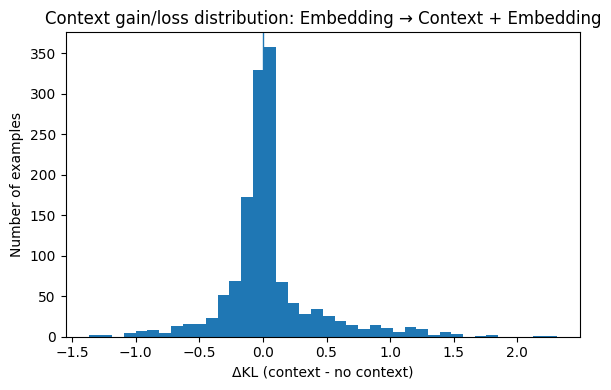

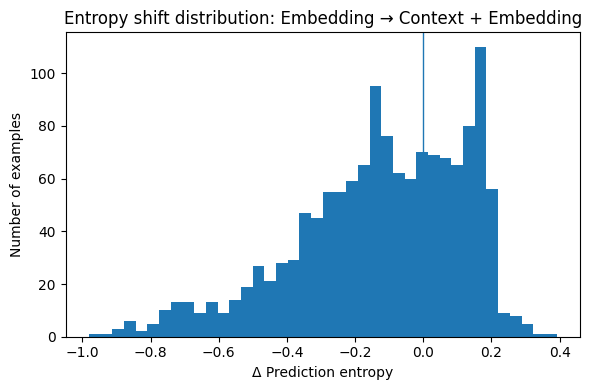

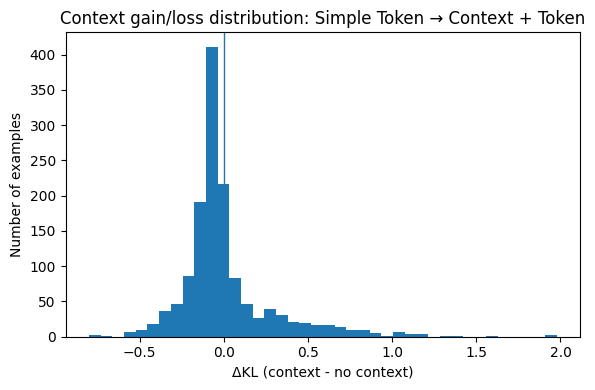

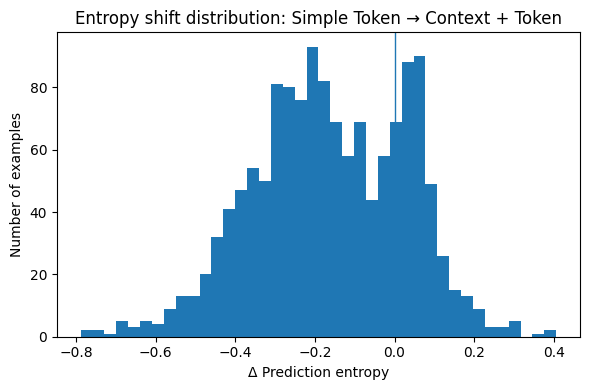

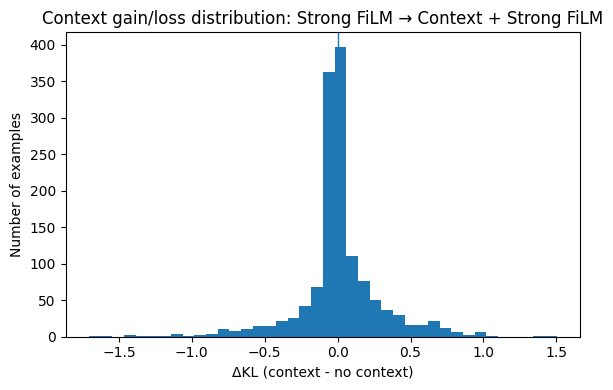

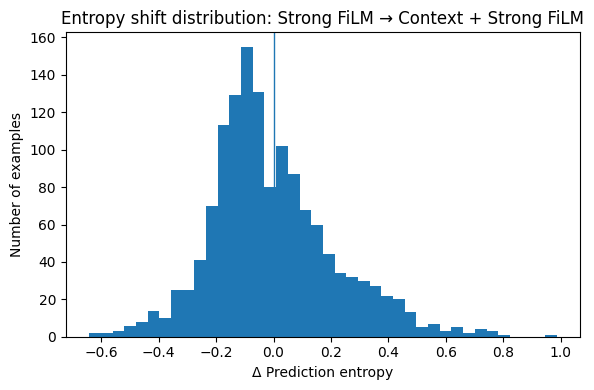

Saved context gain/loss histograms.


In [35]:
for pair, group in context_gain_df.groupby("pair"):
    safe_pair = pair.replace(" ", "_").replace("→", "to").replace("+", "plus")

    plt.figure(figsize=(6, 4))
    plt.hist(group["delta_kl"], bins=40)
    plt.axvline(0, linewidth=1)
    plt.xlabel("ΔKL (context - no context)")
    plt.ylabel("Number of examples")
    plt.title(f"Context gain/loss distribution: {pair}")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{safe_pair}_delta_kl_histogram.png", dpi=200)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.hist(group["delta_pred_entropy"], bins=40)
    plt.axvline(0, linewidth=1)
    plt.xlabel("Δ Prediction entropy")
    plt.ylabel("Number of examples")
    plt.title(f"Entropy shift distribution: {pair}")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{safe_pair}_delta_entropy_histogram.png", dpi=200)
    plt.show()

print("Saved context gain/loss histograms.")


## 16H. Manual Coding Template for Context Gains and Harms

The quantitative analysis tells us **where** context helped or hurt.

This manual coding template is for qualitative interpretation.

Open:

```text
examples/largest_context_gains.csv
examples/largest_context_harms.csv
examples/most_context_sensitive_examples.csv
```

Then manually add one or more categories:

- explicit_slur
- direct_dehumanization
- immigration_policy
- national_identity
- religion
- race_or_ethnicity
- sarcasm_or_irony
- threat_or_violence
- personal_insult
- profanity_only
- ambiguous_context_needed
- context_misleading
- other

The goal is to produce a small table like:

| Category | Gains | Harms |
|---|---:|---:|
| explicit_slur |  |  |
| immigration_policy |  |  |
| sarcasm_or_irony |  |  |

This table is not automatic, but it will be very valuable in the Discussion chapter.


In [36]:
manual_coding_template = pd.DataFrame({
    "category": [
        "explicit_slur",
        "direct_dehumanization",
        "immigration_policy",
        "national_identity",
        "religion",
        "race_or_ethnicity",
        "sarcasm_or_irony",
        "threat_or_violence",
        "personal_insult",
        "profanity_only",
        "ambiguous_context_needed",
        "context_misleading",
        "other",
    ],
    "largest_gains_count": [np.nan] * 13,
    "largest_harms_count": [np.nan] * 13,
    "notes": [""] * 13,
})

manual_coding_template.to_csv(TABLES_DIR / "manual_context_example_coding_template.csv", index=False)
display(manual_coding_template)

print("Saved:", TABLES_DIR / "manual_context_example_coding_template.csv")


,category,largest_gains_count,largest_harms_count,notes
0,explicit_slur,NaN,NaN,
1,direct_dehumanization,NaN,NaN,
2,immigration_policy,NaN,NaN,
3,national_identity,NaN,NaN,
4,religion,NaN,NaN,
5,race_or_ethnicity,NaN,NaN,
6,sarcasm_or_irony,NaN,NaN,
7,threat_or_violence,NaN,NaN,
8,personal_insult,NaN,NaN,
9,profanity_only,NaN,NaN,


Saved: final_evaluation_outputs/immigration/tables/manual_context_example_coding_template.csv


## 17. Qualitative Examples

In [37]:
qualitative_frames = []

for model_name, df in predictions_by_model.items():
    best = df.sort_values("kl", ascending=True).head(5).copy()
    best["example_type"] = "best_lowest_kl"

    worst = df.sort_values("kl", ascending=False).head(5).copy()
    worst["example_type"] = "worst_highest_kl"

    qualitative_frames.extend([best, worst])

qualitative_examples_df = pd.concat(qualitative_frames, ignore_index=True)

keep_cols = [
    "model",
    "example_type",
    "comment_id",
    "subgroup",
    "text",
    "true_distribution",
    "pred_distribution",
    "target_majority_label",
    "pred_majority_label",
    "kl",
    "js",
    "cross_entropy",
    "true_anad",
]

qualitative_examples_df[keep_cols].to_csv(EXAMPLES_DIR / "qualitative_best_worst_examples.csv", index=False)

if not el_ec_details_df.empty:
    tmp = el_ec_details_df.copy()
    tmp["alignment_score"] = tmp["true_js"] * tmp["model_js"]
    tmp["spurious_score"] = tmp["model_js"] - tmp["true_js"]

    tmp.sort_values("alignment_score", ascending=False).head(30).to_csv(
        EXAMPLES_DIR / "el_ec_human_aligned_examples.csv",
        index=False,
    )

    tmp.sort_values("spurious_score", ascending=False).head(30).to_csv(
        EXAMPLES_DIR / "el_ec_spurious_disagreement_examples.csv",
        index=False,
    )

display(qualitative_examples_df[keep_cols].head(30))
print("Saved qualitative examples.")


,model,example_type,comment_id,subgroup,text,true_distribution,pred_distribution,target_majority_label,pred_majority_label,kl,js,cross_entropy,true_anad
0,Original A,best_lowest_kl,20016,neutral,Keep the fucking Mexican scum rapists and murderers out of the country and the fucking Arab Islamic terrorists out of the U.S. too!! No Syrian refugees either!! Build a wall and keep all of these fucking parasites out of the United States. We'll ...,"[0.10084034, 0.05042017, 0.8487395]","[0.10655316, 0.06429894, 0.8291478]",2,2,0.002005,0.000746,0.523173,12.605042
1,Original A,best_lowest_kl,20016,extremely_conservative,Keep the fucking Mexican scum rapists and murderers out of the country and the fucking Arab Islamic terrorists out of the U.S. too!! No Syrian refugees either!! Build a wall and keep all of these fucking parasites out of the United States. We'll ...,"[0.06666667, 0.06666667, 0.8666667]","[0.10655316, 0.06429894, 0.8291478]",2,2,0.009503,0.003657,0.494597,10.000000
2,Original A,best_lowest_kl,20016,conservative,Keep the fucking Mexican scum rapists and murderers out of the country and the fucking Arab Islamic terrorists out of the U.S. too!! No Syrian refugees either!! Build a wall and keep all of these fucking parasites out of the United States. We'll ...,"[0.14285715, 0.035714287, 0.8214286]","[0.10655316, 0.06429894, 0.8291478]",2,2,0.013203,0.004914,0.571781,16.071429
3,Original A,best_lowest_kl,20016,extremely_liberal,Keep the fucking Mexican scum rapists and murderers out of the country and the fucking Arab Islamic terrorists out of the U.S. too!! No Syrian refugees either!! Build a wall and keep all of these fucking parasites out of the United States. We'll ...,"[0.08421053, 0.10526316, 0.8105263]","[0.10655316, 0.06429894, 0.8291478]",2,2,0.013659,0.004627,0.629279,13.684211
4,Original A,best_lowest_kl,20016,liberal,Keep the fucking Mexican scum rapists and murderers out of the country and the fucking Arab Islamic terrorists out of the U.S. too!! No Syrian refugees either!! Build a wall and keep all of these fucking parasites out of the United States. We'll ...,"[0.05732484, 0.044585988, 0.8980892]","[0.10655316, 0.06429894, 0.8291478]",2,2,0.019871,0.007704,0.418973,7.961783
5,Original A,worst_highest_kl,17934,slightly_conservative,Want benefits of being a citizen take citizenship?,"[0.0, 1.0, 0.0]","[0.9582589, 0.02436312, 0.01737801]",1,0,3.714685,0.916930,3.714685,50.000000
6,Original A,worst_highest_kl,43863,slightly_liberal,america is gay,"[0.0, 0.0, 1.0]","[0.94816035, 0.027215399, 0.024624227]",2,0,3.704024,0.916227,3.704024,100.000000
7,Original A,worst_highest_kl,47255,slightly_liberal,i am really starting to see why people in other countries (i.e. Europe) hate Americans...,"[0.0, 0.0, 1.0]","[0.94794446, 0.02699352, 0.025061976]",2,0,3.686403,0.915053,3.686403,100.000000
8,Original A,worst_highest_kl,41510,conservative,It's getting worse everywhere refugees get priority over citizens,"[0.0, 1.0, 0.0]","[0.9527602, 0.025350375, 0.02188945]",1,0,3.674962,0.914282,3.674962,50.000000
9,Original A,worst_highest_kl,44261,liberal,Caucasian and Thai,"[0.0, 1.0, 0.0]","[0.9490576, 0.027381606, 0.023560766]",1,0,3.597884,0.908916,3.597884,50.000000


Saved qualitative examples.


## 18. Report-Ready Plots

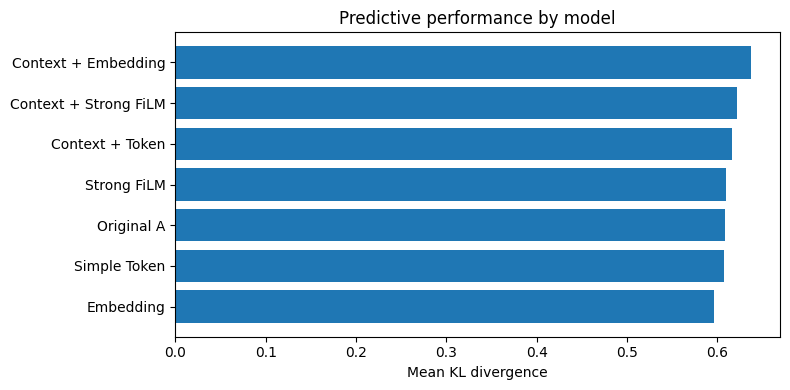

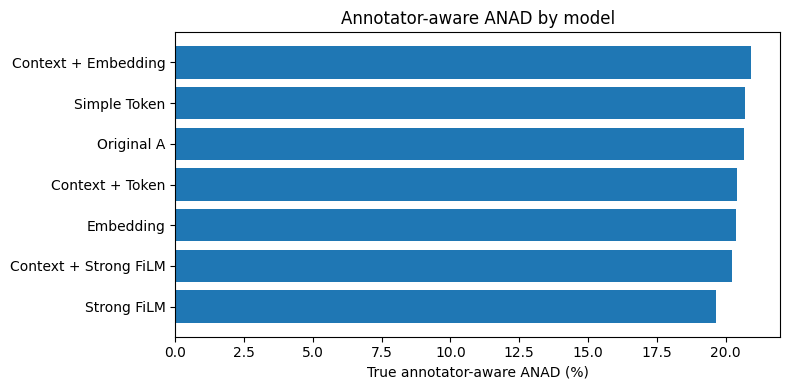

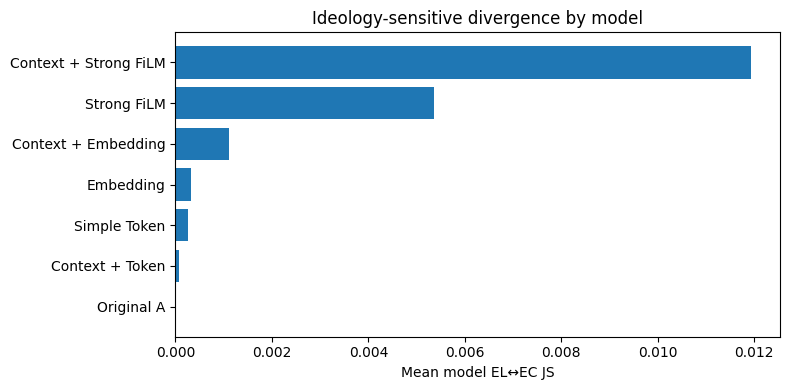

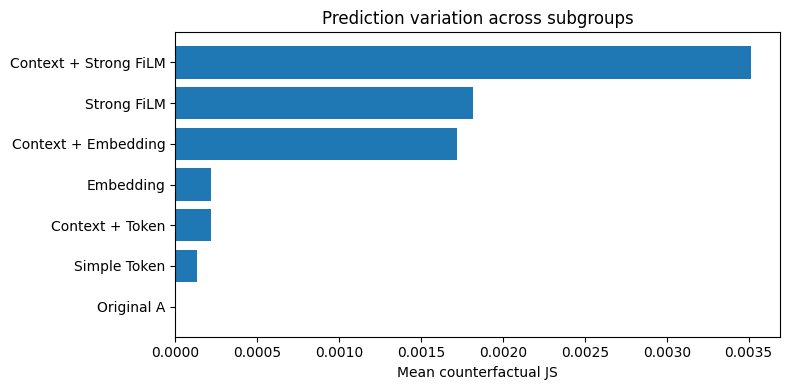

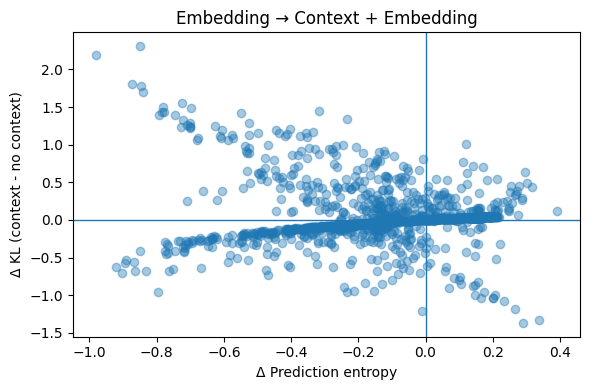

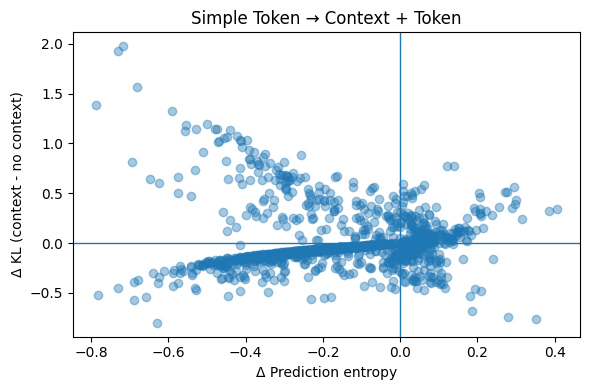

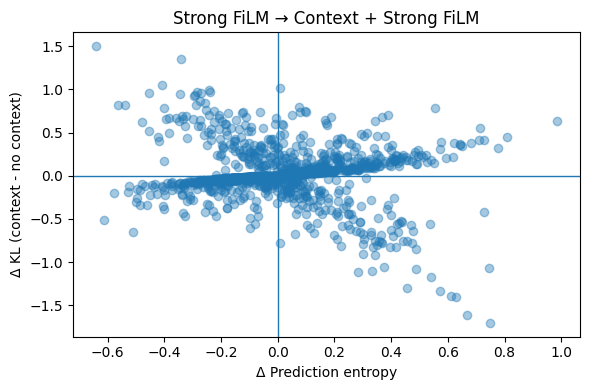

Saved plots to: final_evaluation_outputs/immigration/plots


In [38]:
plot_df = master_metrics_df.sort_values("kl_mean", ascending=True)
plt.figure(figsize=(8, 4))
plt.barh(plot_df["model"], plot_df["kl_mean"])
plt.xlabel("Mean KL divergence")
plt.title("Predictive performance by model")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "kl_by_model.png", dpi=200)
plt.show()

plot_df = master_metrics_df.sort_values("anad_mean", ascending=True)
plt.figure(figsize=(8, 4))
plt.barh(plot_df["model"], plot_df["anad_mean"])
plt.xlabel("True annotator-aware ANAD (%)")
plt.title("Annotator-aware ANAD by model")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "true_anad_by_model.png", dpi=200)
plt.show()

plot_df = el_ec_summary_df.sort_values("mean_model_el_ec_js", ascending=True)
plt.figure(figsize=(8, 4))
plt.barh(plot_df["model"], plot_df["mean_model_el_ec_js"])
plt.xlabel("Mean model EL↔EC JS")
plt.title("Ideology-sensitive divergence by model")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "el_ec_js_by_model.png", dpi=200)
plt.show()

plot_df = counterfactual_summary_df.sort_values("mean_counterfactual_js", ascending=True)
plt.figure(figsize=(8, 4))
plt.barh(plot_df["model"], plot_df["mean_counterfactual_js"])
plt.xlabel("Mean counterfactual JS")
plt.title("Prediction variation across subgroups")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "counterfactual_js_by_model.png", dpi=200)
plt.show()

# Context entropy vs KL scatter
for pair, group in context_gain_df.groupby("pair"):
    plt.figure(figsize=(6, 4))
    plt.scatter(group["delta_pred_entropy"], group["delta_kl"], alpha=0.4)
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.xlabel("Δ Prediction entropy")
    plt.ylabel("Δ KL (context - no context)")
    plt.title(pair)
    plt.tight_layout()
    safe_pair = pair.replace(" ", "_").replace("→", "to").replace("+", "plus")
    plt.savefig(PLOTS_DIR / f"{safe_pair}_delta_entropy_vs_delta_kl.png", dpi=200)
    plt.show()

print("Saved plots to:", PLOTS_DIR)


## 19. Final Report Table

In [39]:
report_table = master_metrics_df.copy()

report_table = report_table.merge(
    counterfactual_summary_df[
        [
            "model",
            "mean_counterfactual_js",
            "median_counterfactual_js",
            "mean_max_pairwise_js",
            "median_max_pairwise_js",
        ]
    ],
    on="model",
    how="left",
)

report_table = report_table.merge(
    polarisation_summary_df[
        [
            "model",
            "mean_true_polarisation_js",
            "mean_model_polarisation_js",
            "mean_polarisation_error",
            "mean_abs_polarisation_error",
            "polarisation_capture_ratio",
            "spearman_true_vs_model_polarisation",
        ]
    ],
    on="model",
    how="left",
)

report_table = report_table.merge(
    el_ec_summary_df[
        [
            "model",
            "n_el_ec_pairs",
            "mean_true_el_ec_js",
            "mean_model_el_ec_js",
            "median_model_el_ec_js",
            "approx_capture_ratio",
        ]
    ],
    on="model",
    how="left",
)

for col in [
    "mean_counterfactual_js",
    "median_counterfactual_js",
    "mean_max_pairwise_js",
    "median_max_pairwise_js",
    "mean_model_el_ec_js",
    "median_model_el_ec_js",
    "approx_capture_ratio",
]:
    if col in report_table.columns:
        report_table.loc[report_table["model"] == "Original A", col] = (
            report_table.loc[report_table["model"] == "Original A", col].fillna(0.0)
        )

report_table = report_table.sort_values("kl_mean")
display(report_table)

report_table.to_csv(TABLES_DIR / "final_report_model_comparison.csv", index=False)
print("Saved:", TABLES_DIR / "final_report_model_comparison.csv")


,model,family,conditioning,uses_context,n,kl_mean,js_mean,cross_entropy_mean,distribution_mae_mean,accuracy,macro_f1,expected_label_mae,distribution_average_MD,average_wasserstein,mean_true_entropy,mean_pred_entropy,entropy_mae,entropy_median_abs_error,anad_mean,anad_median,anad_coverage,entropy_pearson,entropy_spearman,anad_subgroup_coverage,mean_counterfactual_js,median_counterfactual_js,mean_max_pairwise_js,median_max_pairwise_js,mean_true_polarisation_js,mean_model_polarisation_js,mean_polarisation_error,mean_abs_polarisation_error,polarisation_capture_ratio,spearman_true_vs_model_polarisation,n_el_ec_pairs,mean_true_el_ec_js,mean_model_el_ec_js,median_model_el_ec_js,approx_capture_ratio
0,Embedding,embedding,ideology_embedding,False,1384,0.595919,0.223773,0.620344,0.216077,0.770231,0.448261,0.489095,0.648230,0.512826,0.035238,0.831930,0.809917,0.797539,20.368736,0.0,1.0,0.060468,0.059392,1.0,0.000218,0.000129,0.000262,0.000155,0.307464,0.000218,-0.307246,0.307473,0.000708,0.224053,8,0.164481,0.000331,0.000313,0.002013
1,Simple Token,token,ideology_as_text,False,1384,0.607477,0.241747,0.631901,0.243138,0.765173,0.446973,0.557452,0.729413,0.590635,0.035238,1.011069,0.981166,0.969725,20.705923,0.0,1.0,0.058430,0.062302,1.0,0.000131,0.000033,0.000160,0.000041,0.307464,0.000131,-0.307333,0.307467,0.000426,0.065084,8,0.164481,0.000263,0.000011,0.001600
2,Original A,comment_only,none,False,1384,0.609041,0.229569,0.633466,0.221940,0.765896,0.462419,0.515151,0.665821,0.541230,0.035238,0.849188,0.825664,0.825724,20.681838,0.0,1.0,0.033586,0.027813,1.0,0.000000,0.000000,0.000000,0.000000,0.307464,0.000000,-0.307464,0.307464,0.000000,NaN,8,0.164481,0.000000,0.000000,0.000000
3,Strong FiLM,film,film_ideology_modulation,False,1384,0.610134,0.219481,0.634559,0.207502,0.777457,0.461767,0.472863,0.622506,0.493314,0.035238,0.762379,0.745445,0.648953,19.670277,0.0,1.0,0.033175,0.033593,1.0,0.001818,0.001155,0.002246,0.001427,0.307464,0.001818,-0.305646,0.307701,0.005912,0.121474,8,0.164481,0.005363,0.005273,0.032606
4,Context + Token,context_token,context_and_ideology_as_text,True,1384,0.616327,0.229439,0.640752,0.220981,0.770954,0.456479,0.508283,0.662943,0.534303,0.035238,0.849555,0.828815,0.659727,20.428948,0.0,1.0,0.048189,0.049517,1.0,0.000216,0.000014,0.000294,0.000019,0.307464,0.000216,-0.307247,0.307430,0.000704,0.203542,8,0.164481,0.000077,0.000001,0.000468
5,Context + Strong FiLM,context_film,context_text_plus_film_ideology_modulation,True,1384,0.621567,0.222306,0.645992,0.209532,0.772399,0.439655,0.474821,0.628597,0.497017,0.035238,0.757594,0.740718,0.680768,20.224227,0.0,1.0,0.045796,0.042038,1.0,0.003516,0.001174,0.004257,0.001438,0.307464,0.003516,-0.303948,0.307274,0.011434,0.277310,8,0.164481,0.011936,0.010696,0.072570
6,Context + Embedding,context_embedding,context_text_plus_ideology_embedding,True,1384,0.637679,0.220875,0.662103,0.205398,0.764451,0.437165,0.487228,0.616194,0.510580,0.035238,0.705930,0.690177,0.516862,20.934728,0.0,1.0,0.060396,0.065772,1.0,0.001718,0.000268,0.002076,0.000316,0.307464,0.001718,-0.305745,0.307196,0.005589,0.251862,8,0.164481,0.001101,0.000953,0.006695


Saved: final_evaluation_outputs/immigration/tables/final_report_model_comparison.csv


## 20. Auto-Generated Findings Skeleton

In [40]:
print("=" * 100)
print("AUTO-GENERATED FINDINGS SKELETON")
print("=" * 100)

best_kl = master_metrics_df.sort_values("kl_mean").iloc[0]
best_js = master_metrics_df.sort_values("js_mean").iloc[0]
best_f1 = master_metrics_df.sort_values("macro_f1", ascending=False).iloc[0]
best_anad = master_metrics_df.sort_values("anad_mean").iloc[0]

print(f"1. Best KL model: {best_kl['model']} (KL={best_kl['kl_mean']:.4f}).")
print(f"2. Best JS model: {best_js['model']} (JS={best_js['js_mean']:.4f}).")
print(f"3. Best Macro F1 model: {best_f1['model']} (Macro F1={best_f1['macro_f1']:.4f}).")
print(f"4. Best ANAD model: {best_anad['model']} (ANAD={best_anad['anad_mean']:.2f}%).")

if not counterfactual_summary_df.empty:
    best_cf = counterfactual_summary_df.sort_values("mean_counterfactual_js", ascending=False).iloc[0]
    print(f"5. Highest counterfactual subgroup variation: {best_cf['model']} (mean JS={best_cf['mean_counterfactual_js']:.6f}).")

if not polarisation_summary_df.empty:
    best_pol = polarisation_summary_df.sort_values("mean_abs_polarisation_error").iloc[0]
    print(f"6. Closest polarisation index: {best_pol['model']} (abs error={best_pol['mean_abs_polarisation_error']:.6f}).")

if not el_ec_summary_df.empty:
    best_el_ec = el_ec_summary_df.sort_values("mean_model_el_ec_js", ascending=False).iloc[0]
    print(f"7. Highest EL↔EC predicted divergence: {best_el_ec['model']} (JS={best_el_ec['mean_model_el_ec_js']:.6f}).")

print("\nContext matched-pair effects:")
for _, row in context_pair_effects_df.iterrows():
    direction = "improved" if row["delta_kl"] < 0 else "worsened"
    print(f" - {row['pair']}: KL {direction} by {row['delta_kl']:.4f}.")

print("\nSafe discussion claim template:")
print("Aggregate metrics alone may not fully describe the effect of context.")
print("Use subgroup metrics, polarisation, counterfactual variation, and example-level shifts to explain behavioural changes.")
print("Do not claim context is beneficial unless supported by the corresponding table.")


AUTO-GENERATED FINDINGS SKELETON
1. Best KL model: Embedding (KL=0.5959).
2. Best JS model: Strong FiLM (JS=0.2195).
3. Best Macro F1 model: Original A (Macro F1=0.4624).
4. Best ANAD model: Strong FiLM (ANAD=19.67%).
5. Highest counterfactual subgroup variation: Context + Strong FiLM (mean JS=0.003516).
6. Closest polarisation index: Context + Embedding (abs error=0.307196).
7. Highest EL↔EC predicted divergence: Context + Strong FiLM (JS=0.011936).

Context matched-pair effects:
 - Simple Token → Context + Token: KL worsened by 0.0089.
 - Embedding → Context + Embedding: KL worsened by 0.0418.
 - Strong FiLM → Context + Strong FiLM: KL worsened by 0.0114.

Safe discussion claim template:
Aggregate metrics alone may not fully describe the effect of context.
Use subgroup metrics, polarisation, counterfactual variation, and example-level shifts to explain behavioural changes.
Do not claim context is beneficial unless supported by the corresponding table.


In [7]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================
# 1. File paths
# =========================

IMMIGRATION_PI_PATH = Path("/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/final_evaluation_outputs/immigration/tables/polarisation_index_all_models_detail.csv")
WOMEN_PI_PATH = Path("/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/final_evaluation_outputs/women/tables/polarisation_index_all_models_detail.csv")

# If needed, replace with full paths, e.g.
# IMMIGRATION_PI_PATH = Path("/content/polarisation_index_all_models_detail_immi.csv")
# WOMEN_PI_PATH = Path("/content/polarisation_index_all_models_detail_women.csv")


# =========================
# 2. Model pairs
# =========================
# Each pair compares a no-context identity-conditioned model with its context-augmented version.

MODEL_PAIRS = {
    "Token → Context + Token": ("Simple Token", "Context + Token"),
    "Embedding → Context + Embedding": ("Embedding", "Context + Embedding"),
    "FiLM → Context + FiLM": ("Strong FiLM", "Context + Strong FiLM"),
}


# =========================
# 3. Helper functions
# =========================

def load_pi_file(path: Path, dataset_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    required_cols = {
        "comment_id",
        "text",
        "true_polarisation_js",
        "model_polarisation_js",
        "model",
    }

    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{dataset_name}: missing columns: {missing}")

    df = df.copy()
    df["dataset"] = dataset_name

    return df


def compare_context_effect_by_human_pi(
    df: pd.DataFrame,
    dataset_name: str,
    n_buckets: int = 3
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    For each architecture pair:
    - merges no-context and context predictions by comment_id
    - computes change in predicted PI after adding context
    - buckets comments by empirical human PI
    - summarises whether context increased model polarisation in each bucket
    """

    detailed_outputs = []
    summary_outputs = []

    for comparison_name, (base_model, context_model) in MODEL_PAIRS.items():

        base = (
            df[df["model"] == base_model]
            [[
                "comment_id",
                "text",
                "true_polarisation_js",
                "model_polarisation_js",
            ]]
            .rename(columns={"model_polarisation_js": "pi_no_context"})
        )

        context = (
            df[df["model"] == context_model]
            [[
                "comment_id",
                "model_polarisation_js",
            ]]
            .rename(columns={"model_polarisation_js": "pi_context"})
        )

        merged = base.merge(context, on="comment_id", how="inner")

        if merged.empty:
            raise ValueError(
                f"{dataset_name}: no rows after merging {base_model} with {context_model}. "
                f"Check model names."
            )

        merged["dataset"] = dataset_name
        merged["comparison"] = comparison_name
        merged["base_model"] = base_model
        merged["context_model"] = context_model

        # Positive delta means context increased predicted subgroup disagreement.
        merged["delta_pi"] = merged["pi_context"] - merged["pi_no_context"]
        merged["context_increased_pi"] = merged["delta_pi"] > 0
        merged["context_decreased_pi"] = merged["delta_pi"] < 0
        merged["context_unchanged_pi"] = merged["delta_pi"] == 0

        # Bucket comments by empirical/human polarisation.
        # qcut creates roughly equal-sized low/medium/high groups.
        merged["human_pi_bucket"] = pd.qcut(
            merged["true_polarisation_js"],
            q=n_buckets,
            labels=["Low human PI", "High human PI"],
            duplicates="drop",
        )

        summary = (
            merged
            .groupby(["dataset", "comparison", "human_pi_bucket"], observed=True)
            .agg(
                n_comments=("comment_id", "count"),
                mean_human_pi=("true_polarisation_js", "mean"),
                mean_pi_no_context=("pi_no_context", "mean"),
                mean_pi_context=("pi_context", "mean"),
                mean_delta_pi=("delta_pi", "mean"),
                median_delta_pi=("delta_pi", "median"),
                pct_context_increased_pi=("context_increased_pi", "mean"),
                pct_context_decreased_pi=("context_decreased_pi", "mean"),
                pct_context_unchanged_pi=("context_unchanged_pi", "mean"),
            )
            .reset_index()
        )

        for col in [
            "pct_context_increased_pi",
            "pct_context_decreased_pi",
            "pct_context_unchanged_pi",
        ]:
            summary[col] = summary[col] * 100

        detailed_outputs.append(merged)
        summary_outputs.append(summary)

    detailed_df = pd.concat(detailed_outputs, ignore_index=True)
    summary_df = pd.concat(summary_outputs, ignore_index=True)

    return detailed_df, summary_df


# =========================
# 4. Load files
# =========================

immi_pi = load_pi_file(IMMIGRATION_PI_PATH, "Immigration")
women_pi = load_pi_file(WOMEN_PI_PATH, "Women")

print("Immigration models:", immi_pi["model"].unique())
print("Women models:", women_pi["model"].unique())


# =========================
# 5. Run analysis
# =========================

immi_detail, immi_summary = compare_context_effect_by_human_pi(immi_pi, "Immigration")
women_detail, women_summary = compare_context_effect_by_human_pi(women_pi, "Women")

all_detail = pd.concat([immi_detail, women_detail], ignore_index=True)
all_summary = pd.concat([immi_summary, women_summary], ignore_index=True)


# =========================
# 6. Clean display table
# =========================

display_summary = all_summary.copy()

round_cols = [
    "mean_human_pi",
    "mean_pi_no_context",
    "mean_pi_context",
    "mean_delta_pi",
    "median_delta_pi",
    "pct_context_increased_pi",
    "pct_context_decreased_pi",
    "pct_context_unchanged_pi",
]

display_summary[round_cols] = display_summary[round_cols].round(4)

display_summary = display_summary[
    [
        "dataset",
        "comparison",
        "human_pi_bucket",
        "n_comments",
        "mean_human_pi",
        "mean_pi_no_context",
        "mean_pi_context",
        "mean_delta_pi",
        "pct_context_increased_pi",
        "pct_context_decreased_pi",
    ]
]

display_summary

Immigration models: ['Original A' 'Simple Token' 'Embedding' 'Strong FiLM' 'Context + Token'
 'Context + Embedding' 'Context + Strong FiLM']
Women models: ['Original A' 'Simple Token' 'Embedding' 'Strong FiLM' 'Context + Token'
 'Context + Embedding' 'Context + Strong FiLM']


,dataset,comparison,human_pi_bucket,n_comments,mean_human_pi,mean_pi_no_context,mean_pi_context,mean_delta_pi,pct_context_increased_pi,pct_context_decreased_pi
0,Immigration,Token → Context + Token,Low human PI,393,0.0189,0.0001,0.0001,0.0000,38.9313,61.0687
1,Immigration,Token → Context + Token,High human PI,197,0.8831,0.0002,0.0003,0.0002,43.1472,56.8528
2,Immigration,Embedding → Context + Embedding,Low human PI,393,0.0189,0.0002,0.0012,0.0010,72.5191,27.4809
3,Immigration,Embedding → Context + Embedding,High human PI,197,0.8831,0.0003,0.0028,0.0025,75.6345,24.3655
4,Immigration,FiLM → Context + FiLM,Low human PI,393,0.0189,0.0017,0.0027,0.0011,44.0204,55.9796
5,Immigration,FiLM → Context + FiLM,High human PI,197,0.8831,0.0021,0.0051,0.0030,64.9746,35.0254
6,Women,Token → Context + Token,Low human PI,400,0.0633,0.0003,0.0043,0.0040,84.5000,15.5000
7,Women,Token → Context + Token,High human PI,182,0.9642,0.0006,0.0031,0.0025,85.7143,14.2857
8,Women,Embedding → Context + Embedding,Low human PI,400,0.0633,0.0018,0.0022,0.0004,32.2500,67.7500
9,Women,Embedding → Context + Embedding,High human PI,182,0.9642,0.0025,0.0032,0.0007,26.3736,73.6264


In [4]:
mapped = pd.read_parquet("/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_artifacts/context_mapped_examples.parquet")

print(mapped.columns.tolist())
mapped.head(3)

['experiment', 'comment_id', 'split', 'subgroup', 'subgroup_count', 'text', 'target_distribution', 'target_majority_label', 'target_expected_label', 'retrieved_article_titles', 'retrieved_page_urls', 'retrieved_similarities', 'retrieved_summaries', 'context_input_text', 'tweet_token_length', 'context_input_token_length']


,experiment,comment_id,split,subgroup,subgroup_count,text,target_distribution,target_majority_label,target_expected_label,retrieved_article_titles,retrieved_page_urls,retrieved_similarities,retrieved_summaries,context_input_text,tweet_token_length,context_input_token_length
0,immigration,7,test,extremely_liberal,1,\*points to posters asking for palestinian rights and freedom\* theyre antisemetic and want to kill all the jews and dont acknowledge our right to exist ​ cant wait for this prick to die and go straight to hell. ill dig him the hole to get there ...,"[1.0, 0.0, 0.0]",0,0.0,[Left-wing politics],[https://en.wikipedia.org/wiki/Left-wing_politics],[0.14819347858428955],"[Left-wing politics emphasizes social equality and egalitarianism, often opposing social hierarchies and advocating for the empowerment of marginalized groups. Leftist ideologies vary widely but typically involve a concern for those disadvantaged...",### COMMENT TO CLASSIFY\n\*points to posters asking for palestinian rights and freedom\* theyre antisemetic and want to kill all the jews and dont acknowledge our right to exist ​ cant wait for this prick to die and go straight to hell. ill dig h...,60,197
1,immigration,7,test,liberal,1,\*points to posters asking for palestinian rights and freedom\* theyre antisemetic and want to kill all the jews and dont acknowledge our right to exist ​ cant wait for this prick to die and go straight to hell. ill dig him the hole to get there ...,"[0.0, 0.0, 1.0]",2,2.0,[Left-wing politics],[https://en.wikipedia.org/wiki/Left-wing_politics],[0.14819347858428955],"[Left-wing politics emphasizes social equality and egalitarianism, often opposing social hierarchies and advocating for the empowerment of marginalized groups. Leftist ideologies vary widely but typically involve a concern for those disadvantaged...",### COMMENT TO CLASSIFY\n\*points to posters asking for palestinian rights and freedom\* theyre antisemetic and want to kill all the jews and dont acknowledge our right to exist ​ cant wait for this prick to die and go straight to hell. ill dig h...,60,195
2,immigration,10,train,liberal,1,"They'll come back in your plan, also. Plus we pay to jail them for 2 years. With my plan, we jail them after they come back. And deport them again. It really doesn't matter either way until we're build the wall, and shoot the invaders as enemies ...","[0.0, 0.0, 1.0]",2,2.0,[Multiculturalism],[https://en.wikipedia.org/wiki/Multiculturalism],[0.1062689945101738],"[In Western nation-states, multiculturalism has been an official policy since the 1970s, aiming to promote social importance of immigration. However, some governments have reversed this policy, citing concerns about integration and ""home-grown"" t...","### COMMENT TO CLASSIFY\nThey'll come back in your plan, also. Plus we pay to jail them for 2 years. With my plan, we jail them after they come back. And deport them again. It really doesn't matter either way until we're build the wall, and shoot...",65,198


In [13]:
import ast
import json
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial.distance import jensenshannon

# ============================================================
# 1. CONFIG: set these paths
# ============================================================

MAPPED_CONTEXT_PATH_IMMI = Path("/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_artifacts/context_mapped_examples.parquet")
MAPPED_CONTEXT_PATH_WOMEN = Path("/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_context_artifacts/women_context_mapped_examples.parquet")

CONFIG = {
    "Immigration": {
        "mapped_context_path": MAPPED_CONTEXT_PATH_IMMI,
        "base_predictions_path": Path("/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/boostedfilm_outputs/immigration_film_test_predictions.parquet"),
        "context_predictions_path": Path("/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_strong_film_outputs/context_strong_film_test_predictions.parquet"),
        "base_model_name": "Identity FiLM",
        "context_model_name": "Context + FiLM",
    },
    "Women": {
        "mapped_context_path": MAPPED_CONTEXT_PATH_WOMEN,
        "base_predictions_path": Path("/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_film_outputs/women_film_test_predictions.parquet"),
        "context_predictions_path": Path("/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/context_strong_film_outputs/context_strong_film_test_predictions.parquet"),
        "base_model_name": "Identity FiLM",
        "context_model_name": "Context + FiLM",
    },
}




# ============================================================
# 2. HELPERS
# ============================================================

def read_table(path: Path) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    if path.suffix == ".csv":
        return pd.read_csv(path)

    raise ValueError(f"Unsupported file type: {path}")


def parse_list_cell(x):
    """
    Handles cells that may be:
    - real Python lists
    - numpy arrays
    - JSON strings
    - stringified Python lists
    - plain strings
    """
    if isinstance(x, list):
        return x
    if isinstance(x, np.ndarray):
        return x.tolist()
    if pd.isna(x):
        return []

    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []

        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return parsed
            return [parsed]
        except Exception:
            pass

        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                return parsed
            return [parsed]
        except Exception:
            pass

        return [s]

    return [x]


def infer_distribution_columns(df: pd.DataFrame, prefix_candidates):
    """
    Finds probability columns such as:
    pred_0, pred_1, pred_2
    prob_0, prob_1, prob_2
    y_pred_0, y_pred_1, y_pred_2
    """
    cols = list(df.columns)

    for prefix in prefix_candidates:
        matched = [c for c in cols if c.startswith(prefix)]
        if matched:
            matched_sorted = sorted(
                matched,
                key=lambda c: int("".join([ch for ch in c if ch.isdigit()]) or 0)
            )
            return matched_sorted

    raise ValueError(
        "Could not infer distribution columns. "
        f"Available columns are:\n{cols}"
    )


def safe_js(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p = np.clip(p, 1e-12, None)
    q = np.clip(q, 1e-12, None)

    p = p / p.sum()
    q = q / q.sum()

    return float(jensenshannon(p, q, base=2) ** 2)


def to_vector(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return np.asarray(x, dtype=float)

    if isinstance(x, str):
        s = x.strip()
        try:
            return np.asarray(ast.literal_eval(s), dtype=float)
        except Exception:
            try:
                return np.asarray(json.loads(s), dtype=float)
            except Exception:
                pass

    raise ValueError(f"Cannot parse distribution: {x}")


def find_vector_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def prepare_prediction_df(path: Path, model_label: str) -> pd.DataFrame:
    df = read_table(path)

    if "comment_id" not in df.columns:
        raise ValueError(f"{path} does not contain comment_id")

    true_col = "true_distribution"
    pred_col = "pred_distribution"

    if true_col not in df.columns or pred_col not in df.columns:
        raise ValueError(
            f"Expected columns {true_col} and {pred_col} in {path}.\n"
            f"Found columns:\n{df.columns.tolist()}"
        )

    out = df[["comment_id"]].copy()

    # Your files already contain JS, so use it directly if present.
    # This avoids distribution parsing issues.
    if "js" in df.columns:
        out[f"{model_label}_js"] = df["js"].astype(float)
    else:
        out[f"{model_label}_js"] = [
            safe_js(to_vector(t), to_vector(p))
            for t, p in zip(df[true_col], df[pred_col])
        ]

    return out


def build_context_article_analysis(
    dataset_name: str,
    mapped_context_path: Path,
    base_predictions_path: Path,
    context_predictions_path: Path,
    base_model_name: str,
    context_model_name: str,
    split: str = "test",
    min_comments_per_article: int = 5,
):
    # -----------------------------
    # Load context mapping
    # -----------------------------
    mapped = read_table(mapped_context_path)

    required_context_cols = {
        "comment_id",
        "split",
        "subgroup",
        "text",
        "retrieved_article_titles",
        "retrieved_page_urls",
        "retrieved_similarities",
        "retrieved_summaries",
        "context_input_text",
    }

    missing = required_context_cols - set(mapped.columns)
    if missing:
        raise ValueError(f"{dataset_name}: mapped context file missing columns: {missing}")

    mapped = mapped[mapped["split"] == split].copy()

    # Keep one row per comment-subgroup-context.
    # Context is subgroup-conditioned, so subgroup matters.
    mapped["retrieved_article_titles_list"] = mapped["retrieved_article_titles"].apply(parse_list_cell)
    mapped["retrieved_page_urls_list"] = mapped["retrieved_page_urls"].apply(parse_list_cell)
    mapped["retrieved_similarities_list"] = mapped["retrieved_similarities"].apply(parse_list_cell)
    mapped["retrieved_summaries_list"] = mapped["retrieved_summaries"].apply(parse_list_cell)

    # Create a unique context row id before exploding.
    mapped["context_row_id"] = np.arange(len(mapped))

    # -----------------------------
    # Load predictions and compute JS
    # -----------------------------
    base_js = prepare_prediction_df(base_predictions_path, "base")
    context_js = prepare_prediction_df(context_predictions_path, "context")

    perf = base_js.merge(context_js, on="comment_id", how="inner")

    perf["delta_js"] = perf["base_js"] - perf["context_js"]
    perf["context_improved"] = perf["delta_js"] > 0
    perf["context_worsened"] = perf["delta_js"] < 0
    perf["context_unchanged"] = perf["delta_js"] == 0

    # -----------------------------
    # Merge context with performance
    # -----------------------------
    merged = mapped.merge(perf, on="comment_id", how="inner")

    if merged.empty:
        raise ValueError(
            f"{dataset_name}: merge between mapped context and predictions is empty. "
            "Check comment_id alignment."
        )

    merged["dataset"] = dataset_name
    merged["base_model"] = base_model_name
    merged["context_model"] = context_model_name
    merged["comparison"] = f"{base_model_name} → {context_model_name}"

    # -----------------------------
    # Explode retrieved articles
    # -----------------------------
    article_rows = []

    for _, row in merged.iterrows():
        titles = row["retrieved_article_titles_list"]
        urls = row["retrieved_page_urls_list"]
        sims = row["retrieved_similarities_list"]
        summaries = row["retrieved_summaries_list"]

        max_len = max(len(titles), len(urls), len(sims), len(summaries), 1)

        for i in range(max_len):
            article_rows.append({
                "dataset": row["dataset"],
                "comparison": row["comparison"],
                "comment_id": row["comment_id"],
                "subgroup": row["subgroup"],
                "text": row["text"],
                "article_rank": i + 1,
                "article_title": titles[i] if i < len(titles) else None,
                "article_url": urls[i] if i < len(urls) else None,
                "retrieval_similarity": sims[i] if i < len(sims) else np.nan,
                "retrieved_summary": summaries[i] if i < len(summaries) else None,
                "base_js": row["base_js"],
                "context_js": row["context_js"],
                "delta_js": row["delta_js"],
                "context_improved": row["context_improved"],
                "context_worsened": row["context_worsened"],
                "context_unchanged": row["context_unchanged"],
            })

    exploded = pd.DataFrame(article_rows)

    exploded["retrieval_similarity"] = pd.to_numeric(
        exploded["retrieval_similarity"],
        errors="coerce"
    )

    # -----------------------------
    # Article-level summary
    # -----------------------------
    article_summary = (
        exploded
        .groupby(["dataset", "comparison", "article_title"], dropna=False)
        .agg(
            n_context_rows=("comment_id", "size"),
            n_unique_comments=("comment_id", "nunique"),
            n_subgroups=("subgroup", "nunique"),
            mean_retrieval_similarity=("retrieval_similarity", "mean"),
            mean_base_js=("base_js", "mean"),
            mean_context_js=("context_js", "mean"),
            mean_delta_js=("delta_js", "mean"),
            median_delta_js=("delta_js", "median"),
            pct_improved=("context_improved", "mean"),
            pct_worsened=("context_worsened", "mean"),
            pct_unchanged=("context_unchanged", "mean"),
        )
        .reset_index()
    )

    article_summary["pct_improved"] *= 100
    article_summary["pct_worsened"] *= 100
    article_summary["pct_unchanged"] *= 100

    article_summary = article_summary.sort_values(
        ["n_unique_comments", "mean_delta_js"],
        ascending=[False, False]
    )

    reliable_article_summary = article_summary[
        article_summary["n_unique_comments"] >= min_comments_per_article
    ].copy()

    best_articles = reliable_article_summary.sort_values(
        "mean_delta_js",
        ascending=False
    )

    worst_articles = reliable_article_summary.sort_values(
        "mean_delta_js",
        ascending=True
    )

    return merged, exploded, article_summary, reliable_article_summary, best_articles, worst_articles


# ============================================================
# 3. RUN ANALYSIS FOR BOTH DATASETS
# ============================================================

all_merged = []
all_exploded = []
all_article_summary = []
all_reliable_summary = []
all_best = []
all_worst = []

for dataset_name, cfg in CONFIG.items():
    print(f"\nRunning context article analysis for {dataset_name}")

    outputs = build_context_article_analysis(
        dataset_name=dataset_name,
        mapped_context_path=cfg["mapped_context_path"],
        base_predictions_path=cfg["base_predictions_path"],
        context_predictions_path=cfg["context_predictions_path"],
        base_model_name=cfg["base_model_name"],
        context_model_name=cfg["context_model_name"],
        min_comments_per_article=5,
    )

    merged, exploded, article_summary, reliable_summary, best_articles, worst_articles = outputs

    all_merged.append(merged)
    all_exploded.append(exploded)
    all_article_summary.append(article_summary)
    all_reliable_summary.append(reliable_summary)
    all_best.append(best_articles)
    all_worst.append(worst_articles)

context_article_merged = pd.concat(all_merged, ignore_index=True)
context_article_exploded = pd.concat(all_exploded, ignore_index=True)
context_article_summary = pd.concat(all_article_summary, ignore_index=True)
context_article_reliable_summary = pd.concat(all_reliable_summary, ignore_index=True)
context_article_best = pd.concat(all_best, ignore_index=True)
context_article_worst = pd.concat(all_worst, ignore_index=True)


# ============================================================
# 4. DISPLAY MAIN RESULTS
# ============================================================

display_cols = [
    "dataset",
    "article_title",
    "n_unique_comments",
    "mean_retrieval_similarity",
    "mean_base_js",
    "mean_context_js",
    "mean_delta_js",
    "median_delta_js",
    "pct_improved",
    "pct_worsened",
]

print("\nTop helpful retrieved articles:")
display(
    context_article_best[display_cols]
    .round(4)
    .groupby("dataset", group_keys=False)
    .head(10)
)

print("\nMost harmful retrieved articles:")
display(
    context_article_worst[display_cols]
    .round(4)
    .groupby("dataset", group_keys=False)
    .head(10)
)


# ============================================================
# 5. SAVE OUTPUTS
# ============================================================

context_article_merged.to_csv("context_article_analysis_comment_level.csv", index=False)
context_article_exploded.to_csv("context_article_analysis_exploded_articles.csv", index=False)
context_article_summary.to_csv("context_article_analysis_article_summary_all.csv", index=False)
context_article_reliable_summary.to_csv("context_article_analysis_article_summary_min5.csv", index=False)

print("\nSaved:")
print("context_article_analysis_comment_level.csv")
print("context_article_analysis_exploded_articles.csv")
print("context_article_analysis_article_summary_all.csv")
print("context_article_analysis_article_summary_min5.csv")


Running context article analysis for Immigration

Running context article analysis for Women

Top helpful retrieved articles:


,dataset,article_title,n_unique_comments,mean_retrieval_similarity,mean_base_js,mean_context_js,mean_delta_js,median_delta_js,pct_improved,pct_worsened
0,Immigration,Centrism,46,0.1191,0.2354,0.2225,0.0129,0.0137,58.9844,41.0156
1,Immigration,Liberalism,20,0.1007,0.2244,0.2157,0.0087,0.0074,61.5385,38.4615
2,Immigration,Left-wing politics,252,0.1296,0.2247,0.2222,0.0025,0.0090,59.2559,40.7441
3,Immigration,Multiculturalism,238,0.1903,0.1724,0.1704,0.0020,0.0100,66.0083,33.9917
4,Immigration,Immigration,214,0.2350,0.1790,0.1775,0.0015,0.0077,61.3463,38.6537
5,Immigration,Free migration,97,0.2435,0.2299,0.2294,0.0005,0.0062,55.9420,44.0580
6,Immigration,Opposition to immigration,152,0.2591,0.1468,0.1486,-0.0018,0.0076,62.3719,37.6281
7,Immigration,Civic nationalism,98,0.1814,0.1601,0.1642,-0.0042,0.0066,60.8426,39.1574
8,Immigration,Political spectrum,26,0.1653,0.1849,0.1891,-0.0043,0.0114,69.5122,30.4878
9,Immigration,Conservatism,62,0.1274,0.2319,0.2364,-0.0045,0.0074,56.2232,43.7768



Most harmful retrieved articles:


,dataset,article_title,n_unique_comments,mean_retrieval_similarity,mean_base_js,mean_context_js,mean_delta_js,median_delta_js,pct_improved,pct_worsened
0,Immigration,Nativism (politics),8,0.1793,0.1381,0.1869,-0.0488,-0.0193,35.1852,64.8148
1,Immigration,Right-wing politics,29,0.1353,0.2372,0.2429,-0.0058,0.0039,53.1469,46.8531
2,Immigration,Social liberalism,34,0.1211,0.2027,0.2078,-0.0051,0.0050,55.3398,44.6602
3,Immigration,Conservatism,62,0.1274,0.2319,0.2364,-0.0045,0.0074,56.2232,43.7768
4,Immigration,Political spectrum,26,0.1653,0.1849,0.1891,-0.0043,0.0114,69.5122,30.4878
5,Immigration,Civic nationalism,98,0.1814,0.1601,0.1642,-0.0042,0.0066,60.8426,39.1574
6,Immigration,Opposition to immigration,152,0.2591,0.1468,0.1486,-0.0018,0.0076,62.3719,37.6281
7,Immigration,Free migration,97,0.2435,0.2299,0.2294,0.0005,0.0062,55.9420,44.0580
8,Immigration,Immigration,214,0.2350,0.1790,0.1775,0.0015,0.0077,61.3463,38.6537
9,Immigration,Multiculturalism,238,0.1903,0.1724,0.1704,0.0020,0.0100,66.0083,33.9917



Saved:
context_article_analysis_comment_level.csv
context_article_analysis_exploded_articles.csv
context_article_analysis_article_summary_all.csv
context_article_analysis_article_summary_min5.csv


In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================
# Load exploded article-level rows
# =========================

EXPLODED_PATH = Path("context_article_analysis_exploded_articles.csv")

df = pd.read_csv(EXPLODED_PATH)

required = {
    "dataset",
    "comparison",
    "comment_id",
    "subgroup",
    "article_title",
    "article_url",
    "retrieval_similarity",
    "base_js",
    "context_js",
    "delta_js",
    "context_improved",
    "context_worsened",
}

missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

df["retrieval_similarity"] = pd.to_numeric(df["retrieval_similarity"], errors="coerce")
df["delta_js"] = pd.to_numeric(df["delta_js"], errors="coerce")

# Positive delta_js means context reduced JS divergence.
df["context_improved"] = df["context_improved"].astype(bool)
df["context_worsened"] = df["context_worsened"].astype(bool)

# =========================
# 1. Article × subgroup summary
# =========================

article_subgroup_summary = (
    df
    .groupby(["dataset", "comparison", "article_title", "subgroup"], dropna=False)
    .agg(
        n_rows=("comment_id", "size"),
        n_unique_comments=("comment_id", "nunique"),
        mean_retrieval_similarity=("retrieval_similarity", "mean"),
        median_retrieval_similarity=("retrieval_similarity", "median"),
        mean_base_js=("base_js", "mean"),
        mean_context_js=("context_js", "mean"),
        mean_delta_js=("delta_js", "mean"),
        median_delta_js=("delta_js", "median"),
        pct_improved=("context_improved", "mean"),
        pct_worsened=("context_worsened", "mean"),
    )
    .reset_index()
)

article_subgroup_summary["pct_improved"] *= 100
article_subgroup_summary["pct_worsened"] *= 100

# Keep only reasonably supported article-subgroup pairs
MIN_ROWS = 5
reliable_article_subgroup = article_subgroup_summary[
    article_subgroup_summary["n_rows"] >= MIN_ROWS
].copy()

best_article_subgroup = reliable_article_subgroup.sort_values(
    ["dataset", "mean_delta_js"],
    ascending=[True, False]
)

worst_article_subgroup = reliable_article_subgroup.sort_values(
    ["dataset", "mean_delta_js"],
    ascending=[True, True]
)

# =========================
# 2. Retrieval similarity analysis
# =========================

similarity_summary = (
    df
    .dropna(subset=["retrieval_similarity"])
    .groupby(["dataset", "comparison"])
    .agg(
        n_rows=("comment_id", "size"),
        mean_retrieval_similarity=("retrieval_similarity", "mean"),
        mean_delta_js=("delta_js", "mean"),
        corr_similarity_delta_js=("retrieval_similarity", lambda x: x.corr(df.loc[x.index, "delta_js"])),
        corr_similarity_improved=("retrieval_similarity", lambda x: x.corr(df.loc[x.index, "context_improved"].astype(float))),
    )
    .reset_index()
)

# Similarity buckets
df_sim = df.dropna(subset=["retrieval_similarity"]).copy()

df_sim["similarity_bucket"] = (
    df_sim
    .groupby(["dataset", "comparison"])["retrieval_similarity"]
    .transform(lambda s: pd.qcut(
        s,
        q=3,
        labels=["Low similarity", "Medium similarity", "High similarity"],
        duplicates="drop"
    ))
)

similarity_bucket_summary = (
    df_sim
    .groupby(["dataset", "comparison", "similarity_bucket"], observed=True)
    .agg(
        n_rows=("comment_id", "size"),
        mean_similarity=("retrieval_similarity", "mean"),
        mean_delta_js=("delta_js", "mean"),
        median_delta_js=("delta_js", "median"),
        pct_improved=("context_improved", "mean"),
        pct_worsened=("context_worsened", "mean"),
    )
    .reset_index()
)

similarity_bucket_summary["pct_improved"] *= 100
similarity_bucket_summary["pct_worsened"] *= 100

# =========================
# 3. Article-only summary as backup
# =========================

article_summary = (
    df
    .groupby(["dataset", "comparison", "article_title"], dropna=False)
    .agg(
        n_rows=("comment_id", "size"),
        n_unique_comments=("comment_id", "nunique"),
        n_subgroups=("subgroup", "nunique"),
        mean_retrieval_similarity=("retrieval_similarity", "mean"),
        mean_delta_js=("delta_js", "mean"),
        median_delta_js=("delta_js", "median"),
        pct_improved=("context_improved", "mean"),
        pct_worsened=("context_worsened", "mean"),
    )
    .reset_index()
)

article_summary["pct_improved"] *= 100
article_summary["pct_worsened"] *= 100

reliable_article_summary = article_summary[
    article_summary["n_rows"] >= MIN_ROWS
].copy()

# =========================
# 4. Display
# =========================

display_cols = [
    "dataset",
    "article_title",
    "subgroup",
    "n_rows",
    "mean_retrieval_similarity",
    "mean_delta_js",
    "median_delta_js",
    "pct_improved",
    "pct_worsened",
]

print("Most helpful article × subgroup pairs")
display(best_article_subgroup[display_cols].round(4).groupby("dataset", group_keys=False).head(10))

print("Most harmful article × subgroup pairs")
display(worst_article_subgroup[display_cols].round(4).groupby("dataset", group_keys=False).head(10))

print("Retrieval similarity correlations")
display(similarity_summary.round(4))

print("Retrieval similarity buckets")
display(similarity_bucket_summary.round(4))

# =========================
# 5. Save
# =========================

article_subgroup_summary.to_csv("context_article_subgroup_summary_all.csv", index=False)
reliable_article_subgroup.to_csv("context_article_subgroup_summary_min5.csv", index=False)
best_article_subgroup.to_csv("context_article_subgroup_best_min5.csv", index=False)
worst_article_subgroup.to_csv("context_article_subgroup_worst_min5.csv", index=False)
similarity_summary.to_csv("context_retrieval_similarity_summary.csv", index=False)
similarity_bucket_summary.to_csv("context_retrieval_similarity_bucket_summary.csv", index=False)
reliable_article_summary.to_csv("context_article_summary_min5_fixed.csv", index=False)

print("Saved analysis files.")

Most helpful article × subgroup pairs


,dataset,article_title,subgroup,n_rows,mean_retrieval_similarity,mean_delta_js,median_delta_js,pct_improved,pct_worsened
15,Immigration,National conservatism,extremely_conservative,71,0.1053,0.0225,0.0273,81.6901,18.3099
1,Immigration,Centrism,no_opinion,16,0.1181,0.0140,-0.0056,50.0000,50.0000
0,Immigration,Centrism,neutral,240,0.1191,0.0128,0.0149,59.5833,40.4167
11,Immigration,Liberalism,liberal,46,0.1251,0.0121,0.0085,56.5217,43.4783
13,Immigration,Multiculturalism,extremely_liberal,455,0.2072,0.0079,0.0135,75.1648,24.8352
12,Immigration,Liberalism,slightly_liberal,71,0.0849,0.0065,0.0070,64.7887,35.2113
9,Immigration,Left-wing politics,liberal,586,0.1423,0.0055,0.0090,56.3140,43.6860
20,Immigration,Political spectrum,no_opinion,20,0.1981,0.0039,0.0108,75.0000,25.0000
22,Immigration,Right-wing politics,slightly_conservative,115,0.1180,0.0032,0.0041,54.7826,45.2174
3,Immigration,Conservatism,conservative,214,0.1384,0.0028,0.0113,64.9533,35.0467


Most harmful article × subgroup pairs


,dataset,article_title,subgroup,n_rows,mean_retrieval_similarity,mean_delta_js,median_delta_js,pct_improved,pct_worsened
16,Immigration,Nativism (politics),extremely_conservative,54,0.1793,-0.0488,-0.0193,35.1852,64.8148
21,Immigration,Right-wing politics,conservative,28,0.2063,-0.0428,-0.0032,46.4286,53.5714
4,Immigration,Conservatism,slightly_conservative,252,0.1181,-0.0108,-0.0036,48.8095,51.1905
19,Immigration,Political spectrum,neutral,144,0.1608,-0.0054,0.0115,68.7500,31.2500
23,Immigration,Social liberalism,slightly_liberal,206,0.1211,-0.0051,0.0050,55.3398,44.6602
2,Immigration,Civic nationalism,slightly_conservative,807,0.1814,-0.0042,0.0066,60.8426,39.1574
18,Immigration,Opposition to immigration,extremely_conservative,346,0.2750,-0.0028,0.0082,63.8728,36.1272
17,Immigration,Opposition to immigration,conservative,1020,0.2536,-0.0014,0.0070,61.8627,38.1373
8,Immigration,Left-wing politics,extremely_liberal,322,0.1349,-0.0007,0.0121,59.6273,40.3727
7,Immigration,Immigration,no_opinion,511,0.2347,-0.0002,0.0079,62.2309,37.7691


Retrieval similarity correlations


,dataset,comparison,n_rows,mean_retrieval_similarity,mean_delta_js,corr_similarity_delta_js,corr_similarity_improved
0,Immigration,Identity FiLM → Context + FiLM,10402,0.1891,0.0005,-0.0138,-0.0018
1,Women,Identity FiLM → Context + FiLM,4827,0.2118,-0.0012,0.0207,0.0617


Retrieval similarity buckets


,dataset,comparison,similarity_bucket,n_rows,mean_similarity,mean_delta_js,median_delta_js,pct_improved,pct_worsened
0,Immigration,Identity FiLM → Context + FiLM,Low similarity,3482,0.0838,0.0047,0.0093,62.5503,37.4497
1,Immigration,Identity FiLM → Context + FiLM,Medium similarity,3453,0.1759,0.0007,0.0084,60.1216,39.8784
2,Immigration,Identity FiLM → Context + FiLM,High similarity,3467,0.3082,-0.0038,0.0068,60.6865,39.3135
3,Women,Identity FiLM → Context + FiLM,Low similarity,1612,0.1033,-0.0081,0.0053,53.6600,46.3400
4,Women,Identity FiLM → Context + FiLM,Medium similarity,1609,0.1927,0.0010,0.0049,56.6812,43.3188
5,Women,Identity FiLM → Context + FiLM,High similarity,1606,0.3400,0.0035,0.0034,60.4608,39.5392


Saved analysis files.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================
# Load exploded article-level rows
# =========================

EXPLODED_PATH = Path("context_article_analysis_exploded_articles.csv")

df = pd.read_csv(EXPLODED_PATH)
df = df.drop_duplicates(
    subset=["dataset", "comment_id", "subgroup"]
).copy()
required = {
    "dataset",
    "comparison",
    "comment_id",
    "subgroup",
    "article_title",
    "article_url",
    "retrieval_similarity",
    "base_js",
    "context_js",
    "delta_js",
    "context_improved",
    "context_worsened",
}

missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

df["retrieval_similarity"] = pd.to_numeric(df["retrieval_similarity"], errors="coerce")
df["delta_js"] = pd.to_numeric(df["delta_js"], errors="coerce")

# Positive delta_js means context reduced JS divergence.
df["context_improved"] = df["context_improved"].astype(bool)
df["context_worsened"] = df["context_worsened"].astype(bool)

# =========================
# 1. Article × subgroup summary
# =========================

article_subgroup_summary = (
    df
    .groupby(["dataset", "comparison", "article_title", "subgroup"], dropna=False)
    .agg(
        n_rows=("comment_id", "size"),
        n_unique_comments=("comment_id", "nunique"),
        mean_retrieval_similarity=("retrieval_similarity", "mean"),
        median_retrieval_similarity=("retrieval_similarity", "median"),
        mean_base_js=("base_js", "mean"),
        mean_context_js=("context_js", "mean"),
        mean_delta_js=("delta_js", "mean"),
        median_delta_js=("delta_js", "median"),
        pct_improved=("context_improved", "mean"),
        pct_worsened=("context_worsened", "mean"),
    )
    .reset_index()
)

article_subgroup_summary["pct_improved"] *= 100
article_subgroup_summary["pct_worsened"] *= 100

# Keep only reasonably supported article-subgroup pairs
MIN_ROWS = 5
reliable_article_subgroup = article_subgroup_summary[
    article_subgroup_summary["n_rows"] >= MIN_ROWS
].copy()

best_article_subgroup = reliable_article_subgroup.sort_values(
    ["dataset", "mean_delta_js"],
    ascending=[True, False]
)

worst_article_subgroup = reliable_article_subgroup.sort_values(
    ["dataset", "mean_delta_js"],
    ascending=[True, True]
)

# =========================
# 2. Retrieval similarity analysis
# =========================

similarity_summary = (
    df
    .dropna(subset=["retrieval_similarity"])
    .groupby(["dataset", "comparison"])
    .agg(
        n_rows=("comment_id", "size"),
        mean_retrieval_similarity=("retrieval_similarity", "mean"),
        mean_delta_js=("delta_js", "mean"),
        corr_similarity_delta_js=("retrieval_similarity", lambda x: x.corr(df.loc[x.index, "delta_js"])),
        corr_similarity_improved=("retrieval_similarity", lambda x: x.corr(df.loc[x.index, "context_improved"].astype(float))),
    )
    .reset_index()
)

# Similarity buckets
df_sim = df.dropna(subset=["retrieval_similarity"]).copy()

df_sim["similarity_bucket"] = (
    df_sim
    .groupby(["dataset", "comparison"])["retrieval_similarity"]
    .transform(lambda s: pd.qcut(
        s,
        q=3,
        labels=["Low similarity", "Medium similarity", "High similarity"],
        duplicates="drop"
    ))
)

similarity_bucket_summary = (
    df_sim
    .groupby(["dataset", "comparison", "similarity_bucket"], observed=True)
    .agg(
        n_rows=("comment_id", "size"),
        mean_similarity=("retrieval_similarity", "mean"),
        mean_delta_js=("delta_js", "mean"),
        median_delta_js=("delta_js", "median"),
        pct_improved=("context_improved", "mean"),
        pct_worsened=("context_worsened", "mean"),
    )
    .reset_index()
)

similarity_bucket_summary["pct_improved"] *= 100
similarity_bucket_summary["pct_worsened"] *= 100

# =========================
# 3. Article-only summary as backup
# =========================

article_summary = (
    df
    .groupby(["dataset", "comparison", "article_title"], dropna=False)
    .agg(
        n_rows=("comment_id", "size"),
        n_unique_comments=("comment_id", "nunique"),
        n_subgroups=("subgroup", "nunique"),
        mean_retrieval_similarity=("retrieval_similarity", "mean"),
        mean_delta_js=("delta_js", "mean"),
        median_delta_js=("delta_js", "median"),
        pct_improved=("context_improved", "mean"),
        pct_worsened=("context_worsened", "mean"),
    )
    .reset_index()
)

article_summary["pct_improved"] *= 100
article_summary["pct_worsened"] *= 100

reliable_article_summary = article_summary[
    article_summary["n_rows"] >= MIN_ROWS
].copy()

# =========================
# 4. Display
# =========================

display_cols = [
    "dataset",
    "article_title",
    "subgroup",
    "n_rows",
    "mean_retrieval_similarity",
    "mean_delta_js",
    "median_delta_js",
    "pct_improved",
    "pct_worsened",
]

print("Most helpful article × subgroup pairs")
display(best_article_subgroup[display_cols].round(4).groupby("dataset", group_keys=False).head(10))

print("Most harmful article × subgroup pairs")
display(worst_article_subgroup[display_cols].round(4).groupby("dataset", group_keys=False).head(10))

print("Retrieval similarity correlations")
display(similarity_summary.round(4))

print("Retrieval similarity buckets")
display(similarity_bucket_summary.round(4))

# =========================
# 5. Save
# =========================

article_subgroup_summary.to_csv("context_article_subgroup_summary_all.csv", index=False)
reliable_article_subgroup.to_csv("context_article_subgroup_summary_min5.csv", index=False)
best_article_subgroup.to_csv("context_article_subgroup_best_min5.csv", index=False)
worst_article_subgroup.to_csv("context_article_subgroup_worst_min5.csv", index=False)
similarity_summary.to_csv("context_retrieval_similarity_summary.csv", index=False)
similarity_bucket_summary.to_csv("context_retrieval_similarity_bucket_summary.csv", index=False)
reliable_article_summary.to_csv("context_article_summary_min5_fixed.csv", index=False)

print("Saved analysis files.")

Most helpful article × subgroup pairs


,dataset,article_title,subgroup,n_rows,mean_retrieval_similarity,mean_delta_js,median_delta_js,pct_improved,pct_worsened
11,Immigration,Liberalism,liberal,9,0.1339,0.0444,0.0206,77.7778,22.2222
12,Immigration,Liberalism,slightly_liberal,14,0.0821,0.0143,0.0122,71.4286,28.5714
0,Immigration,Centrism,neutral,42,0.1210,0.0132,0.0066,57.1429,42.8571
3,Immigration,Conservatism,conservative,32,0.1313,0.0069,0.0098,65.6250,34.3750
13,Immigration,Multiculturalism,extremely_liberal,56,0.1966,0.0067,0.0139,73.2143,26.7857
9,Immigration,Left-wing politics,liberal,93,0.1532,0.0049,0.0095,59.1398,40.8602
5,Immigration,Free migration,extremely_liberal,97,0.2281,0.0048,0.0125,63.9175,36.0825
14,Immigration,Multiculturalism,liberal,206,0.1769,0.0041,0.0099,65.5340,34.4660
8,Immigration,Left-wing politics,extremely_liberal,44,0.1581,0.0041,0.0114,63.6364,36.3636
10,Immigration,Left-wing politics,slightly_liberal,165,0.1322,0.0037,0.0088,60.0000,40.0000


Most harmful article × subgroup pairs


,dataset,article_title,subgroup,n_rows,mean_retrieval_similarity,mean_delta_js,median_delta_js,pct_improved,pct_worsened
16,Immigration,Nativism (politics),extremely_conservative,8,0.1710,-0.0586,-0.0163,25.0000,75.0000
18,Immigration,Opposition to immigration,extremely_conservative,34,0.2545,-0.0215,0.0057,55.8824,44.1176
21,Immigration,Right-wing politics,conservative,7,0.2063,-0.0172,0.0041,57.1429,42.8571
17,Immigration,Opposition to immigration,conservative,124,0.2495,-0.0142,0.0044,55.6452,44.3548
7,Immigration,Immigration,no_opinion,40,0.2561,-0.0125,0.0038,52.5000,47.5000
2,Immigration,Civic nationalism,slightly_conservative,98,0.1737,-0.0101,0.0066,57.1429,42.8571
6,Immigration,Immigration,neutral,190,0.2357,-0.0021,0.0091,63.1579,36.8421
19,Immigration,Political spectrum,neutral,25,0.1591,-0.0013,0.0108,68.0000,32.0000
22,Immigration,Right-wing politics,slightly_conservative,22,0.1199,0.0008,0.0033,54.5455,45.4545
4,Immigration,Conservatism,slightly_conservative,34,0.1102,0.0014,0.0065,55.8824,44.1176


Retrieval similarity correlations


,dataset,comparison,n_rows,mean_retrieval_similarity,mean_delta_js,corr_similarity_delta_js,corr_similarity_improved
0,Immigration,Identity FiLM → Context + FiLM,1384,0.1842,-0.0003,-0.0171,0.0760
1,Women,Identity FiLM → Context + FiLM,1173,0.2122,-0.0014,0.0242,0.0852


Retrieval similarity buckets


,dataset,comparison,similarity_bucket,n_rows,mean_similarity,mean_delta_js,median_delta_js,pct_improved,pct_worsened
0,Immigration,Identity FiLM → Context + FiLM,Low similarity,462,0.0862,-0.0005,0.0074,56.0606,43.9394
1,Immigration,Identity FiLM → Context + FiLM,Medium similarity,460,0.1716,0.0013,0.0094,61.7391,38.2609
2,Immigration,Identity FiLM → Context + FiLM,High similarity,462,0.2946,-0.0018,0.0089,65.8009,34.1991
3,Women,Identity FiLM → Context + FiLM,Low similarity,391,0.1030,-0.0059,0.0018,52.1739,47.8261
4,Women,Identity FiLM → Context + FiLM,Medium similarity,391,0.1935,0.0022,0.0032,60.1023,39.8977
5,Women,Identity FiLM → Context + FiLM,High similarity,391,0.3402,-0.0006,0.0020,62.4041,37.5959


Saved analysis files.


In [2]:
best_article_subgroup.groupby("dataset").head(10)
worst_article_subgroup.groupby("dataset").head(10)
similarity_bucket_summary

,dataset,comparison,similarity_bucket,n_rows,mean_similarity,mean_delta_js,median_delta_js,pct_improved,pct_worsened
0,Immigration,Identity FiLM → Context + FiLM,Low similarity,462,0.086227,-0.000500,0.007420,56.060606,43.939394
1,Immigration,Identity FiLM → Context + FiLM,Medium similarity,460,0.171584,0.001344,0.009425,61.739130,38.260870
2,Immigration,Identity FiLM → Context + FiLM,High similarity,462,0.294640,-0.001782,0.008918,65.800866,34.199134
3,Women,Identity FiLM → Context + FiLM,Low similarity,391,0.103021,-0.005939,0.001764,52.173913,47.826087
4,Women,Identity FiLM → Context + FiLM,Medium similarity,391,0.193526,0.002212,0.003155,60.102302,39.897698
5,Women,Identity FiLM → Context + FiLM,High similarity,391,0.340160,-0.000586,0.001990,62.404092,37.595908


In [4]:
bucket_effects = (
    df_sim
    .groupby(["dataset", "similarity_bucket"], observed=True)
    .agg(
        n=("delta_js", "size"),
        pct_improved=("context_improved", "mean"),

        mean_delta=("delta_js", "mean"),

        mean_positive_delta=(
            "delta_js",
            lambda x: x[x > 0].mean()
        ),

        mean_negative_delta=(
            "delta_js",
            lambda x: x[x < 0].mean()
        ),
    )
    .reset_index()
)

bucket_effects["pct_improved"] *= 100

display(bucket_effects.round(4))

,dataset,similarity_bucket,n,pct_improved,mean_delta,mean_positive_delta,mean_negative_delta
0,Immigration,Low similarity,462,56.0606,-0.0005,0.0503,-0.0653
1,Immigration,Medium similarity,460,61.7391,0.0013,0.0489,-0.0755
2,Immigration,High similarity,462,65.8009,-0.0018,0.0313,-0.0655
3,Women,Low similarity,391,52.1739,-0.0059,0.0551,-0.0725
4,Women,Medium similarity,391,60.1023,0.0022,0.0449,-0.0621
5,Women,High similarity,391,62.4041,-0.0006,0.0310,-0.0530


In [3]:
art = pd.read_csv("context_article_subgroup_summary_all.csv")

print("Unique article titles:", art["article_title"].nunique())

print("\nCounts per article:")
print(
    art.groupby("article_title")["n_unique_comments"]
       .sum()
       .sort_values(ascending=False)
       .head(20)
)

Unique article titles: 29

Counts per article:
article_title
Left-wing politics           302
Violence against women       291
Multiculturalism             262
Male privilege               241
Immigration                  230
Opposition to immigration    158
Misogyny                     152
Gender role                  128
Civic nationalism             98
Free migration                97
Toxic masculinity             91
Hegemonic masculinity         70
Conservatism                  66
Gender inequality             58
Centrism                      46
Masculinity                   46
Sexism                        41
Patriarchy                    39
Social liberalism             34
Right-wing politics           29
Name: n_unique_comments, dtype: int64


In [17]:
import pandas as pd

# Load the exploded article-level data
df = pd.read_csv("context_article_analysis_exploded_articles.csv")

# ----------------------------
# Count how often each article appears
# ----------------------------
article_counts = (
    df.groupby("article_title")
      .size()
      .sort_values(ascending=False)
      .rename("times_retrieved")
      .reset_index()
)

TOP_N = 15
top_articles = article_counts.head(TOP_N)["article_title"]

# Keep only the top retrieved articles
df_top = df[df["article_title"].isin(top_articles)].copy()

# ----------------------------
# Summarise performance
# ----------------------------
summary = (
    df_top
    .groupby(["dataset", "article_title"])
    .agg(
        times_retrieved=("comment_id", "count"),
        unique_comments=("comment_id", "nunique"),
        mean_similarity=("retrieval_similarity", "mean"),
        mean_delta_js=("delta_js", "mean"),
        median_delta_js=("delta_js", "median"),
        pct_improved=("context_improved", "mean"),
        pct_worsened=("context_worsened", "mean"),
    )
    .reset_index()
)

summary["pct_improved"] *= 100
summary["pct_worsened"] *= 100

summary = summary.sort_values(
    ["dataset", "times_retrieved"],
    ascending=[True, False]
)

summary = summary.round({
    "mean_similarity":4,
    "mean_delta_js":4,
    "median_delta_js":4,
    "pct_improved":1,
    "pct_worsened":1,
})

display(summary)

summary.to_csv(
    "top15_retrieved_article_performance.csv",
    index=False
)

print("Saved top15_retrieved_article_performance.csv")

,dataset,article_title,times_retrieved,unique_comments,mean_similarity,mean_delta_js,median_delta_js,pct_improved,pct_worsened
5,Immigration,Left-wing politics,2177,252,0.1296,0.0025,0.0090,59.3,40.7
4,Immigration,Immigration,1961,214,0.2350,0.0015,0.0077,61.3,38.7
6,Immigration,Multiculturalism,1924,238,0.1903,0.0020,0.0100,66.0,34.0
7,Immigration,Opposition to immigration,1366,152,0.2591,-0.0018,0.0076,62.4,37.6
1,Immigration,Civic nationalism,807,98,0.1814,-0.0042,0.0066,60.8,39.2
3,Immigration,Free migration,690,97,0.2435,0.0005,0.0062,55.9,44.1
2,Immigration,Conservatism,466,62,0.1274,-0.0045,0.0074,56.2,43.8
0,Immigration,Centrism,256,46,0.1191,0.0129,0.0137,59.0,41.0
14,Women,Violence against women,1179,291,0.2021,-0.0023,0.0035,54.0,46.0
11,Women,Male privilege,984,241,0.1882,0.0013,0.0058,56.6,43.4


Saved top15_retrieved_article_performance.csv


In [18]:
df = pd.read_csv("context_article_analysis_exploded_articles.csv")

tmp = df[df["article_title"] == "Left-wing politics"]

tmp.groupby("comment_id")["subgroup"].nunique().describe()

count    252.000000
mean       1.198413
std        0.437666
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: subgroup, dtype: float64

In [19]:
tmp.groupby("comment_id")["subgroup"].unique().head()

comment_id
7       [extremely_liberal, liberal]
66                [slightly_liberal]
596              [extremely_liberal]
836               [slightly_liberal]
1584              [slightly_liberal]
Name: subgroup, dtype: object

In [20]:
df = pd.read_csv("context_article_analysis_exploded_articles.csv")

print("Total rows:", len(df))

print("\nRows for Left-wing politics:")
print((df["article_title"] == "Left-wing politics").sum())

print("\nUnique (comment, subgroup) pairs:")
print(
    df[df["article_title"]=="Left-wing politics"]
      [["comment_id","subgroup"]]
      .drop_duplicates()
      .shape[0]
)

Total rows: 15229

Rows for Left-wing politics:
2177

Unique (comment, subgroup) pairs:
302


In [22]:
import pandas as pd

# Load files
exploded = pd.read_csv("context_article_analysis_exploded_articles.csv")

# Remove duplicated merge artefacts by keeping the real unit:
# one row = one comment × subgroup × retrieved article
dedup = exploded.drop_duplicates(
    subset=["dataset", "comment_id", "subgroup", "article_title"]
).copy()

# Sanity check
print("Original rows:", len(exploded))
print("Deduplicated rows:", len(dedup))

print("\nLeft-wing politics:")
tmp = dedup[dedup["article_title"] == "Left-wing politics"]
print("Rows:", len(tmp))
print("Unique comment-subgroup pairs:", tmp[["comment_id", "subgroup"]].drop_duplicates().shape[0])
print("Unique comments:", tmp["comment_id"].nunique())

# Article-level performance, using correct unit
article_summary_fixed = (
    dedup
    .groupby(["dataset", "article_title"])
    .agg(
        times_retrieved=("comment_id", "count"),
        unique_comments=("comment_id", "nunique"),
        unique_comment_subgroups=("subgroup", "count"),
        mean_delta_js=("delta_js", "mean"),
        median_delta_js=("delta_js", "median"),
        pct_improved=("context_improved", "mean"),
        pct_worsened=("context_worsened", "mean"),
        mean_similarity=("retrieval_similarity", "mean"),
    )
    .reset_index()
)

article_summary_fixed["pct_improved"] *= 100
article_summary_fixed["pct_worsened"] *= 100

article_summary_fixed = article_summary_fixed.sort_values(
    ["dataset", "times_retrieved"],
    ascending=[True, False]
)

top15_fixed = (
    article_summary_fixed
    .groupby("dataset", group_keys=False)
    .head(15)
)

display(top15_fixed.round(4))

top15_fixed.to_csv("top15_retrieved_article_performance_FIXED.csv", index=False)
article_summary_fixed.to_csv("retrieved_article_performance_FIXED_all.csv", index=False)

print("Saved fixed files.")

Original rows: 15229
Deduplicated rows: 2557

Left-wing politics:
Rows: 302
Unique comment-subgroup pairs: 302
Unique comments: 252


,dataset,article_title,times_retrieved,unique_comments,unique_comment_subgroups,mean_delta_js,median_delta_js,pct_improved,pct_worsened,mean_similarity
5,Immigration,Left-wing politics,302,252,302,0.0041,0.0095,60.2649,39.7351,0.1424
7,Immigration,Multiculturalism,262,238,262,0.0046,0.0110,67.1756,32.8244,0.1811
4,Immigration,Immigration,230,214,230,-0.0039,0.0084,61.3043,38.6957,0.2392
10,Immigration,Opposition to immigration,158,152,158,-0.0158,0.0046,55.6962,44.3038,0.2506
1,Immigration,Civic nationalism,98,98,98,-0.0101,0.0066,57.1429,42.8571,0.1737
3,Immigration,Free migration,97,97,97,0.0048,0.0125,63.9175,36.0825,0.2281
2,Immigration,Conservatism,66,62,66,0.0041,0.0089,60.6061,39.3939,0.1205
0,Immigration,Centrism,46,46,46,0.0131,0.0044,56.5217,43.4783,0.1208
13,Immigration,Social liberalism,34,34,34,0.0028,0.0072,55.8824,44.1176,0.1276
12,Immigration,Right-wing politics,29,29,29,-0.0035,0.0041,55.1724,44.8276,0.1408


Saved fixed files.


In [23]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================
# 1. Load fixed exploded context analysis
# =========================

EXPLODED_PATH = Path("context_article_analysis_exploded_articles.csv")

df = pd.read_csv(EXPLODED_PATH)

# Remove the earlier merge duplication issue
df = df.drop_duplicates(
    subset=["dataset", "comment_id", "subgroup", "article_title"]
).copy()

# Positive delta_js = context reduced JS = improvement
df["delta_js"] = pd.to_numeric(df["delta_js"], errors="coerce")
df["base_js"] = pd.to_numeric(df["base_js"], errors="coerce")
df["context_js"] = pd.to_numeric(df["context_js"], errors="coerce")
df["retrieval_similarity"] = pd.to_numeric(df["retrieval_similarity"], errors="coerce")

df["context_improved"] = df["delta_js"] > 0
df["context_worsened"] = df["delta_js"] < 0

# =========================
# 2. Keep useful columns
# =========================

case_cols = [
    "dataset",
    "comment_id",
    "subgroup",
    "text",
    "article_title",
    "article_url",
    "retrieval_similarity",
    "retrieved_summary",
    "base_js",
    "context_js",
    "delta_js",
    "context_improved",
    "context_worsened",
]

cases = df[case_cols].copy()

# =========================
# 3. Select top improvements and deteriorations
# =========================

TOP_N = 20

top_improvements = (
    cases
    .sort_values("delta_js", ascending=False)
    .groupby("dataset", group_keys=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

top_deteriorations = (
    cases
    .sort_values("delta_js", ascending=True)
    .groupby("dataset", group_keys=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

# =========================
# 4. Create shorter readable preview
# =========================

def shorten(text, n=250):
    if pd.isna(text):
        return ""
    text = str(text).replace("\n", " ")
    return text if len(text) <= n else text[:n] + "..."

preview_cols = [
    "dataset",
    "comment_id",
    "subgroup",
    "article_title",
    "retrieval_similarity",
    "base_js",
    "context_js",
    "delta_js",
    "text_short",
    "summary_short",
]

top_improvements["text_short"] = top_improvements["text"].apply(lambda x: shorten(x, 220))
top_improvements["summary_short"] = top_improvements["retrieved_summary"].apply(lambda x: shorten(x, 300))

top_deteriorations["text_short"] = top_deteriorations["text"].apply(lambda x: shorten(x, 220))
top_deteriorations["summary_short"] = top_deteriorations["retrieved_summary"].apply(lambda x: shorten(x, 300))

# =========================
# 5. Display
# =========================

print("Top context improvements")
display(top_improvements[preview_cols].round(4))

print("Top context deteriorations")
display(top_deteriorations[preview_cols].round(4))

# =========================
# 6. Save full files for choosing final case studies
# =========================

top_improvements.to_csv("qualitative_top_context_improvements.csv", index=False)
top_deteriorations.to_csv("qualitative_top_context_deteriorations.csv", index=False)

print("Saved:")
print("qualitative_top_context_improvements.csv")
print("qualitative_top_context_deteriorations.csv")

Top context improvements


,dataset,comment_id,subgroup,article_title,retrieval_similarity,base_js,context_js,delta_js,text_short,summary_short
0,Immigration,40210,slightly_liberal,Social liberalism,0.1039,0.6403,0.2865,0.3537,Canada should kick out khalistani terrorists...they are not sikhs they missusing name of sikhs,"Social liberalism is a political philosophy that endorses social justice, social services, and government intervention to address economic and social issues such as poverty, welfare, infrastructure, healthcare, and education. It emphasizes indivi..."
1,Immigration,40210,neutral,Centrism,0.1217,0.6403,0.2865,0.3537,Canada should kick out khalistani terrorists...they are not sikhs they missusing name of sikhs,"Centrism is a range of political ideologies between left-wing and right-wing politics on the left-right spectrum, associated with moderate policies and gradual change through a welfare state. Centrists support a middle class and often hold libera..."
2,Immigration,40210,conservative,Opposition to immigration,0.1748,0.6403,0.2865,0.3537,Canada should kick out khalistani terrorists...they are not sikhs they missusing name of sikhs,"National identity plays a significant role in shaping attitudes towards immigration, with exclusionary definitions often associated with anti-immigration sentiments. Research suggests that people respond more strongly to appeals to national ident..."
3,Women,29604,women,Misogyny,0.1563,0.7010,0.3676,0.3335,Bitch On My Dick... She Know What It Is!,"Misogyny is a form of sexism that perpetuates women's subordinate status in patriarchal societies. It can manifest in obvious and subtle ways, including violence against women, sexual harassment, and exclusion from full citizenship. Misogyny is o..."
4,Women,29604,men,Gender role,0.1336,0.7010,0.3676,0.3335,Bitch On My Dick... She Know What It Is!,"Gender roles are social norms that vary across cultures, influencing a wide range of human behavior, including profession, relationships, and personal expression. Traditionally, women have been confined to the ""private"" sphere while men occupy th..."
5,Women,49207,men,Toxic masculinity,0.2515,0.7915,0.4595,0.3321,"Women are murderers of unborn babies, evil","Toxic masculinity refers to traditional cultural masculine norms that can be harmful to men, women, and society overall. These norms emphasize dominance, self-reliance, competition, and the restriction of emotion, often resulting in violence, agg..."
6,Women,49207,women,Violence against women,0.4388,0.7915,0.4595,0.3321,"Women are murderers of unborn babies, evil","Violence against women is a manifestation of historically unequal power relations between men and women, with men being the primary perpetrators due to societal patriarchal norms. This violence can take many forms, including rape, domestic violen..."
7,Immigration,41937,extremely_liberal,Free migration,0.1923,0.8587,0.5307,0.3279,Saudi royals are nothing but cavemen with too much money.,"The concept of free migration has been debated globally, with various perspectives on its moral, economic, and cultural implications. Some argue that it's a human right, citing religious teachings such as Buddhism and Christianity, which emphasiz..."
8,Immigration,41937,liberal,Multiculturalism,0.0961,0.8587,0.5307,0.3279,Saudi royals are nothing but cavemen with too much money.,"In Western nation-states, multiculturalism has been an official policy since the 1970s, aiming to promote social importance of immigration. However, some governments have reversed this policy, citing concerns about integration and ""home-grown"" te..."
9,Immigration,31016,slightly_liberal,Left-wing politics,0.0955,0.6578,0.3303,0.3275,fuck usa fuck israel,"Left-wing politics emphasizes social equality and egalitarianism, often opposing social hierarchies and advocating for the empowerment of marginalized groups. Leftist ideologies vary widely but typically involve a concern for those disadvantaged ..."


Top context deteriorations


,dataset,comment_id,subgroup,article_title,retrieval_similarity,base_js,context_js,delta_js,text_short,summary_short
0,Women,11338,women,Patriarchy,0.0438,0.3945,0.8786,-0.4841,My I please eat your smooth cunt,"Patriarchy is a social system where men hold primary positions of authority, dominating society through various means. Sociologists attribute this to the process of socialization, which establishes gender roles and inequity as instruments of powe..."
1,Women,11338,men,Male privilege,0.0483,0.3945,0.8786,-0.4841,My I please eat your smooth cunt,"In patriarchal societies, males hold primary power and predominate in roles of leadership, moral authority, social privilege, and control of property, granting them economic, political, social, educational, and practical advantages over women. Th..."
2,Women,29194,women,Violence against women,0.0535,0.2956,0.7545,-0.4590,Nah fuck that hoe,"Violence against women is a manifestation of historically unequal power relations between men and women, with men being the primary perpetrators due to societal patriarchal norms. This violence can take many forms, including rape, domestic violen..."
3,Women,29194,men,Hegemonic masculinity,0.0900,0.2956,0.7545,-0.4590,Nah fuck that hoe,"Hegemonic masculinity refers to the culturally idealized form of manhood that justifies men's dominant position in society and subordinates women and other marginalized groups. It is characterized by traits such as violence, aggression, stoicism,..."
4,Women,31848,women,Gender inequality,0.3906,0.4628,0.8100,-0.3471,Women's are trash,"Gender inequality refers to disparities between men and women in access to opportunities, resources, rights, and protections. Biological differences between sexes include reproductive roles, physical strength, and longevity. Psychological differe..."
5,Women,31848,men,Gender role,0.3606,0.4628,0.8100,-0.3471,Women's are trash,"Gender roles are social norms that vary across cultures, influencing a wide range of human behavior, including profession, relationships, and personal expression. Traditionally, women have been confined to the ""private"" sphere while men occupy th..."
6,Immigration,43330,slightly_conservative,Civic nationalism,0.1404,0.5180,0.8300,-0.3120,zion He's about to you Palistinian Muslim POS.,"Civic nationalism emphasizes shared citizenship and liberal principles over cultural or ethnic identity. It contrasts with ethnic nationalism, which has been associated with authoritarian rule and racism. Civic nationalists argue that individuals..."
7,Immigration,43330,extremely_liberal,Free migration,0.1299,0.5180,0.8300,-0.3120,zion He's about to you Palistinian Muslim POS.,"The concept of free migration has been debated globally, with various perspectives on its moral, economic, and cultural implications. Some argue that it's a human right, citing religious teachings such as Buddhism and Christianity, which emphasiz..."
8,Women,1660,women,Patriarchy,0.0424,0.1848,0.4738,-0.2890,That's decently obsolete at this point unfortunately. All the feminazi scientists making babies without us.,"Patriarchy is a social system where men hold primary positions of authority, dominating society through various means. Sociologists attribute this to the process of socialization, which establishes gender roles and inequity as instruments of powe..."
9,Women,1660,men,Toxic masculinity,0.0850,0.1848,0.4738,-0.2890,That's decently obsolete at this point unfortunately. All the feminazi scientists making babies without us.,"Toxic masculinity refers to traditional cultural masculine norms that can be harmful to men, women, and society overall. These norms emphasize dominance, self-reliance, competition, and the restriction of emotion, often resulting in violence, agg..."


Saved:
qualitative_top_context_improvements.csv
qualitative_top_context_deteriorations.csv


In [25]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================
# 1. Paths
# =========================

EXPLODED_PATH = Path("context_article_analysis_exploded_articles.csv")

IMMIGRATION_MAPPED_PATH = Path("/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/context_artifacts/context_mapped_examples.parquet")
WOMEN_MAPPED_PATH = Path("/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_context_artifacts/women_context_mapped_examples.parquet")

# =========================
# 2. Load context-performance rows
# =========================

df = pd.read_csv(EXPLODED_PATH)

# Correct unit: one comment × subgroup × article
df = df.drop_duplicates(
    subset=["dataset", "comment_id", "subgroup", "article_title"]
).copy()

df["delta_js"] = pd.to_numeric(df["delta_js"], errors="coerce")
df["base_js"] = pd.to_numeric(df["base_js"], errors="coerce")
df["context_js"] = pd.to_numeric(df["context_js"], errors="coerce")

df["improved"] = df["delta_js"] > 0

# =========================
# 3. Load both mapped parquets
# =========================

immi_mapped = pd.read_parquet(IMMIGRATION_MAPPED_PATH)
immi_mapped["dataset"] = "Immigration"

women_mapped = pd.read_parquet(WOMEN_MAPPED_PATH)
women_mapped["dataset"] = "Women"

mapped = pd.concat([immi_mapped, women_mapped], ignore_index=True)

mapped_small = mapped[
    [
        "dataset",
        "comment_id",
        "subgroup",
        "tweet_token_length",
        "context_input_token_length",
        "text",
    ]
].drop_duplicates()

# =========================
# 4. Merge safely
# =========================

analysis = df.merge(
    mapped_small,
    on=["dataset", "comment_id", "subgroup"],
    how="left",
    suffixes=("", "_mapped")
)

print("Rows before merge:", len(df))
print("Rows after merge:", len(analysis))
print("Missing tweet_token_length:", analysis["tweet_token_length"].isna().sum())

# =========================
# 5. Length features
# =========================

# Prefer stored token length; also compute simple word length from text
analysis["comment_word_length"] = (
    analysis["text"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

analysis["context_ratio"] = (
    analysis["context_input_token_length"] /
    analysis["tweet_token_length"].replace(0, np.nan)
)

# =========================
# 6. Improved vs worsened summary
# =========================

length_outcome_summary = (
    analysis
    .groupby(["dataset", "improved"])
    .agg(
        n=("comment_id", "count"),
        mean_words=("comment_word_length", "mean"),
        median_words=("comment_word_length", "median"),
        mean_comment_tokens=("tweet_token_length", "mean"),
        median_comment_tokens=("tweet_token_length", "median"),
        mean_context_tokens=("context_input_token_length", "mean"),
        mean_context_ratio=("context_ratio", "mean"),
        median_context_ratio=("context_ratio", "median"),
        mean_delta_js=("delta_js", "mean"),
        median_delta_js=("delta_js", "median"),
    )
    .reset_index()
)

display(length_outcome_summary.round(3))

# =========================
# 7. Bucket by comment length
# =========================

bins = [0, 10, 20, 40, 80, 1000]
labels = ["1-10", "11-20", "21-40", "41-80", "80+"]

analysis["length_bucket"] = pd.cut(
    analysis["comment_word_length"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

length_bucket_summary = (
    analysis
    .groupby(["dataset", "length_bucket"], observed=True)
    .agg(
        n=("comment_id", "count"),
        mean_delta_js=("delta_js", "mean"),
        median_delta_js=("delta_js", "median"),
        pct_improved=("improved", "mean"),
        mean_context_ratio=("context_ratio", "mean"),
    )
    .reset_index()
)

length_bucket_summary["pct_improved"] *= 100

display(length_bucket_summary.round(3))

# =========================
# 8. Correlations
# =========================

corr_rows = []

for dataset, temp in analysis.groupby("dataset"):
    corr_rows.append({
        "dataset": dataset,
        "corr_words_delta_js": temp["comment_word_length"].corr(temp["delta_js"]),
        "corr_tweet_tokens_delta_js": temp["tweet_token_length"].corr(temp["delta_js"]),
        "corr_context_ratio_delta_js": temp["context_ratio"].corr(temp["delta_js"]),
    })

length_correlation_summary = pd.DataFrame(corr_rows)

display(length_correlation_summary.round(4))

# =========================
# 9. Save
# =========================

analysis.to_csv("context_length_effect_detail.csv", index=False)
length_outcome_summary.to_csv("context_length_outcome_summary.csv", index=False)
length_bucket_summary.to_csv("context_length_bucket_summary.csv", index=False)
length_correlation_summary.to_csv("context_length_correlation_summary.csv", index=False)

print("Saved:")
print("context_length_effect_detail.csv")
print("context_length_outcome_summary.csv")
print("context_length_bucket_summary.csv")
print("context_length_correlation_summary.csv")

Rows before merge: 2557
Rows after merge: 2557
Missing tweet_token_length: 0


,dataset,improved,n,mean_words,median_words,mean_comment_tokens,median_comment_tokens,mean_context_tokens,mean_context_ratio,median_context_ratio,mean_delta_js,median_delta_js
0,Immigration,False,537,28.695,23.0,38.607,30.0,175.199,6.675,5.500,-0.069,-0.045
1,Immigration,True,847,26.328,23.0,35.579,30.0,171.850,7.012,5.406,0.043,0.018
2,Women,False,490,23.016,17.0,30.788,23.0,172.076,8.706,7.215,-0.063,-0.031
3,Women,True,683,20.832,16.0,27.845,21.0,170.031,9.089,7.783,0.043,0.015


,dataset,length_bucket,n,mean_delta_js,median_delta_js,pct_improved,mean_context_ratio
0,Immigration,1-10,271,0.009,0.012,64.945,14.294
1,Immigration,11-20,338,-0.013,0.004,54.142,7.437
2,Immigration,21-40,464,0.002,0.008,67.241,4.717
3,Immigration,41-80,274,0.002,0.008,56.934,3.167
4,Immigration,80+,37,-0.000,0.009,54.054,2.174
5,Women,1-10,345,0.001,0.005,65.507,15.681
6,Women,11-20,410,-0.003,0.002,54.878,8.090
7,Women,21-40,259,0.005,0.002,56.371,4.910
8,Women,41-80,139,-0.014,0.001,56.115,3.100
9,Women,80+,20,-0.017,-0.003,40.000,2.229


,dataset,corr_words_delta_js,corr_tweet_tokens_delta_js,corr_context_ratio_delta_js
0,Immigration,-0.0102,-0.0065,0.0607
1,Women,-0.0334,-0.0317,-0.0323


Saved:
context_length_effect_detail.csv
context_length_outcome_summary.csv
context_length_bucket_summary.csv
context_length_correlation_summary.csv


In [26]:
import pandas as pd

# ----------------------------------------------------
# Load fixed context analysis
# ----------------------------------------------------

df = pd.read_csv("context_article_analysis_exploded_articles.csv")

# Correct unit
df = df.drop_duplicates(
    subset=["dataset","comment_id","subgroup","article_title"]
).copy()

df["delta_js"] = pd.to_numeric(df["delta_js"])

# ----------------------------------------------------
# Useful metadata
# ----------------------------------------------------

df["comment_words"] = (
    df["text"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

# Rank improvements within each dataset
df["improvement_rank"] = (
    df.groupby("dataset")["delta_js"]
      .rank(method="first", ascending=False)
)

df["deterioration_rank"] = (
    df.groupby("dataset")["delta_js"]
      .rank(method="first", ascending=True)
)

# ----------------------------------------------------
# Human-readable review dataframe
# ----------------------------------------------------

review = df[
    [
        "dataset",
        "comment_id",
        "subgroup",

        "delta_js",
        "base_js",
        "context_js",

        "comment_words",

        "article_title",
        "retrieval_similarity",

        "text",
        "retrieved_summary",

        "improvement_rank",
        "deterioration_rank"
    ]
].copy()

# ----------------------------------------------------
# Sort both directions
# ----------------------------------------------------

top_improvements = (
    review
    .sort_values(
        ["dataset","delta_js"],
        ascending=[True,False]
    )
)

top_deteriorations = (
    review
    .sort_values(
        ["dataset","delta_js"],
        ascending=[True,True]
    )
)

# ----------------------------------------------------
# Save EVERYTHING
# ----------------------------------------------------

top_improvements.to_csv(
    "review_top_improvements.csv",
    index=False
)

top_deteriorations.to_csv(
    "review_top_deteriorations.csv",
    index=False
)

# ----------------------------------------------------
# Display only first few rows
# ----------------------------------------------------

display(
    top_improvements.groupby("dataset").head(15)
)

display(
    top_deteriorations.groupby("dataset").head(15)
)

print("Saved:")
print("review_top_improvements.csv")
print("review_top_deteriorations.csv")

,dataset,comment_id,subgroup,delta_js,base_js,context_js,comment_words,article_title,retrieval_similarity,text,retrieved_summary,improvement_rank,deterioration_rank
6832,Immigration,40210,conservative,0.353726,0.640271,0.286544,14,Opposition to immigration,0.174773,Canada should kick out khalistani terrorists...they are not sikhs they missusing name of sikhs,"National identity plays a significant role in shaping attitudes towards immigration, with exclusionary definitions often associated with anti-immigration sentiments. Research suggests that people respond more strongly to appeals to national ident...",1.0,1382.0
6841,Immigration,40210,neutral,0.353726,0.640271,0.286544,14,Centrism,0.121710,Canada should kick out khalistani terrorists...they are not sikhs they missusing name of sikhs,"Centrism is a range of political ideologies between left-wing and right-wing politics on the left-right spectrum, associated with moderate policies and gradual change through a welfare state. Centrists support a middle class and often hold libera...",2.0,1383.0
6850,Immigration,40210,slightly_liberal,0.353726,0.640271,0.286544,14,Social liberalism,0.103863,Canada should kick out khalistani terrorists...they are not sikhs they missusing name of sikhs,"Social liberalism is a political philosophy that endorses social justice, social services, and government intervention to address economic and social issues such as poverty, welfare, infrastructure, healthcare, and education. It emphasizes indivi...",3.0,1384.0
7578,Immigration,41937,extremely_liberal,0.327930,0.858664,0.530733,10,Free migration,0.192292,Saudi royals are nothing but cavemen with too much money.,"The concept of free migration has been debated globally, with various perspectives on its moral, economic, and cultural implications. Some argue that it's a human right, citing religious teachings such as Buddhism and Christianity, which emphasiz...",4.0,1380.0
7582,Immigration,41937,liberal,0.327930,0.858664,0.530733,10,Multiculturalism,0.096099,Saudi royals are nothing but cavemen with too much money.,"In Western nation-states, multiculturalism has been an official policy since the 1970s, aiming to promote social importance of immigration. However, some governments have reversed this policy, citing concerns about integration and ""home-grown"" te...",5.0,1381.0
5471,Immigration,31016,extremely_liberal,0.327484,0.657756,0.330272,4,Multiculturalism,0.142060,fuck usa fuck israel,"In Western nation-states, multiculturalism has been an official policy since the 1970s, aiming to promote social importance of immigration. However, some governments have reversed this policy, citing concerns about integration and ""home-grown"" te...",6.0,1377.0
5480,Immigration,31016,neutral,0.327484,0.657756,0.330272,4,Immigration,0.089262,fuck usa fuck israel,"Immigration is a complex issue with varying social, economic, and political contexts. Research suggests that immigration can be beneficial for both receiving and sending countries, with positive effects on the economy, education, and health outco...",7.0,1378.0
5489,Immigration,31016,slightly_liberal,0.327484,0.657756,0.330272,4,Left-wing politics,0.095517,fuck usa fuck israel,"Left-wing politics emphasizes social equality and egalitarianism, often opposing social hierarchies and advocating for the empowerment of marginalized groups. Leftist ideologies vary widely but typically involve a concern for those disadvantaged ...",8.0,1379.0
7411,Immigration,41543,extremely_liberal,0.298907,0.817513,0.518606,31,Free migration,0.253996,"+Kaddywompous ""immigrants"" arent the same thing as ""undocumented illegal immigrants"".....lol you probably got manipulated by MSNBC with that statistic that ""immigrants"" commit less crime lol bc that statistic doesnt include illegals","The concept of free migration has been debated globally, with various perspectives on its moral, economic, and cultural implications. Some argue that it's a human right, citing religious teachi

,dataset,comment_id,subgroup,delta_js,base_js,context_js,comment_words,article_title,retrieval_similarity,text,retrieved_summary,improvement_rank,deterioration_rank
8072,Immigration,43330,extremely_liberal,-0.312049,0.517964,0.830012,8,Free migration,0.129949,zion He's about to you Palistinian Muslim POS.,"The concept of free migration has been debated globally, with various perspectives on its moral, economic, and cultural implications. Some argue that it's a human right, citing religious teachings such as Buddhism and Christianity, which emphasiz...",1383.0,1.0
8076,Immigration,43330,slightly_conservative,-0.312049,0.517964,0.830012,8,Civic nationalism,0.140350,zion He's about to you Palistinian Muslim POS.,"Civic nationalism emphasizes shared citizenship and liberal principles over cultural or ethnic identity. It contrasts with ethnic nationalism, which has been associated with authoritarian rule and racism. Civic nationalists argue that individuals...",1384.0,2.0
10158,Immigration,49371,extremely_conservative,-0.283796,0.192041,0.475836,29,Opposition to immigration,0.161777,"Ebola disappeared, WALL DISAPPEARED, AL-QAEDA VANISHES, ISIS?....NO ONE KNOWS. NORTH KOREA? Shhhhh...lets keep this public distracted, while we bomb ONLY MUSLIM COUNTRIES AND blame their government for it. *MURICA*","National identity plays a significant role in shaping attitudes towards immigration, with exclusionary definitions often associated with anti-immigration sentiments. Research suggests that people respond more strongly to appeals to national ident...",1381.0,3.0
10162,Immigration,49371,neutral,-0.283796,0.192041,0.475836,29,Immigration,0.100244,"Ebola disappeared, WALL DISAPPEARED, AL-QAEDA VANISHES, ISIS?....NO ONE KNOWS. NORTH KOREA? Shhhhh...lets keep this public distracted, while we bomb ONLY MUSLIM COUNTRIES AND blame their government for it. *MURICA*","Immigration is a complex issue with varying social, economic, and political contexts. Research suggests that immigration can be beneficial for both receiving and sending countries, with positive effects on the economy, education, and health outco...",1382.0,4.0
637,Immigration,7741,extremely_liberal,-0.282426,0.153656,0.436083,8,Multiculturalism,0.189463,Now put this worthless immigrant trash to death.,"In Western nation-states, multiculturalism has been an official policy since the 1970s, aiming to promote social importance of immigration. However, some governments have reversed this policy, citing concerns about integration and ""home-grown"" te...",1378.0,5.0
646,Immigration,7741,slightly_conservative,-0.282426,0.153656,0.436083,8,Civic nationalism,0.220789,Now put this worthless immigrant trash to death.,"Civic nationalism emphasizes shared citizenship and liberal principles over cultural or ethnic identity. It contrasts with ethnic nationalism, which has been associated with authoritarian rule and racism. Civic nationalists argue that individuals...",1379.0,6.0
655,Immigration,7741,slightly_liberal,-0.282426,0.153656,0.436083,8,Left-wing politics,0.070032,Now put this worthless immigrant trash to death.,"Left-wing politics emphasizes social equality and egalitarianism, often opposing social hierarchies and advocating for the empowerment of marginalized groups. Leftist ideologies vary widely but typically involve a concern for those disadvantaged ...",1380.0,7.0
9855,Immigration,48384,conservative,-0.279930,0.035916,0.315845,18,Conservatism,0.058047,Watch it my channel guys! Im from indonesian peace and love for all us jesus bless you all,"Conservatism is a cultural, social, and political philosophy that seeks to promote and preserve traditional institutions, customs, and values. It often emphasizes tradition, authority, hierarchy, and property rights, with some variants being more...",1376.0,8.0
9859,Immigration,48384,liberal,-0.279930,0.035916,0.315845,18,Multiculturalism,0.097207,Watch it my channel guys! Im from indonesian peace and love for all us jesus bless you all,"In Wester

Saved:
review_top_improvements.csv
review_top_deteriorations.csv
